In [1]:
import sys
import os
import subprocess
import random
import numpy as np

# 1. 시스템 레벨 확인 (NVIDIA 드라이버 및 WSL 인식 여부)
print("=== 1. System Level Check (nvidia-smi) ===")
try:
    nvidia_smi = subprocess.check_output(["nvidia-smi"]).decode("utf-8")
    print(nvidia_smi)
except Exception as e:
    print("Error: nvidia-smi command not found. Check if NVIDIA Driver is installed on Windows Host.")

# 2. PyTorch GPU 및 필수 라이브러리 확인 (Tabular ResNet용)
print("\n=== 2. PyTorch & Optimization Library Check ===")
try:
    import torch
    import torch.nn as nn
    # Bayesian Optimization을 위한 Optuna 설치 확인
    try:
        import optuna
        print(f"Optuna Version: {optuna.__version__}")
    except ImportError:
        print("Installing Optuna for Bayesian Optimization...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "optuna"])
        import optuna

    cuda_available = torch.cuda.is_available()
    device = torch.device("cuda" if cuda_available else "cpu")
    
    print(f"PyTorch Version: {torch.__version__}")
    print(f"CUDA Available: {cuda_available}")
    
    if cuda_available:
        print(f"Current GPU: {torch.cuda.get_device_name(0)}")
        # 연산 일관성을 위한 시드 고정 (재현성 확보)
        def set_seed(seed=42):
            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
        set_seed(42)
        print("Seed fixed: 42")
    else:
        print("Warning: CUDA is not detected. Neural Network training will be slow.")
        
except ImportError:
    print("PyTorch not installed. Please install torch for Tabular ResNet.")

# 3. TensorFlow 확인 (필요 시 유지, 없어도 ResNet 구현에는 지장 없음)
print("\n=== 3. TensorFlow Status ===")
try:
    import tensorflow as tf
    print(f"TensorFlow Version: {tf.__version__}")
    print(f"GPUs Detected: {len(tf.config.list_physical_devices('GPU'))}")
except ImportError:
    print("TensorFlow not installed. (Optional)")

=== 1. System Level Check (nvidia-smi) ===
Error: nvidia-smi command not found. Check if NVIDIA Driver is installed on Windows Host.

=== 2. PyTorch & Optimization Library Check ===


c:\Users\alstj\miniconda3\envs\DL\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Optuna Version: 4.7.0
PyTorch Version: 2.10.0+cpu
CUDA Available: False

=== 3. TensorFlow Status ===
TensorFlow Version: 2.20.0
GPUs Detected: 0


# [Step 1] 대리 모델(Surrogate)을 통한 데이터 증강 — v2 (Improved)

> **목표:** ~900개의 생존 시뮬레이션 데이터에서 300초 시계열의 **'절댓값 Max Peak(부호 유지)'**를 추출하고,  
> GPR(Gaussian Process Regression) 대리 모델을 학습하여 **10만 개의 가상 P1~P6 조합**에 대한 응력/변형 결과를 예측합니다.

### 핵심 물리 로직: '절댓값 Max Peak' 추출
열 사이클링에서 응력은 가열 시 (+), 냉각 시 (-) 방향으로 진동합니다.  
**단순 max()를 쓰면 냉각 시 압축 응력(음수)의 위험성을 놓칩니다.**  
따라서 `abs().idxmax()`로 절댓값이 가장 큰 시점을 찾되, 그 시점의 **원래 부호를 보존**합니다.

```python
# 절댓값이 가장 큰 시점의 인덱스 -> 해당 시점의 원본 값(부호 유지)
max_abs_idx = df_time[col].abs().idxmax()
peak_value  = df_time.loc[max_abs_idx, col]   # 예: -30 (압축 피크)
```

---
## 0. 환경 설정 및 라이브러리 로드

In [5]:
import os
import re
import glob
import time
import warnings
import platform
import random
import numpy as np
import pandas as pd

# 시각화 및 분석
import matplotlib.pyplot as plt
import seaborn as sns

# 머신러닝 및 전처리
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

# PyTorch (Tabular ResNet 구현용)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Bayesian Optimization (LHS 대체용)
import optuna

# 최적화 및 유전 알고리즘 (Step 5-6용)
from pymoo.core.problem import Problem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 9

# -- 디바이스 설정 --
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ====================================================================
# [경로 자동 설정] Windows와 WSL(Linux) 환경 자동 감지
# ====================================================================
CSV_FOLDER = r'C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS/data'   # 시계열 CSV들이 저장된 폴더
MASTER_CSV = r'Master_DOE_1200.csv'                  # P1~P6 설계변수 마스터 파일
BASE_DIR = r'C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS'

# 핵심 Y 변수 (WarpMax, Peel Stress 등 15개)
Y_COLUMNS = [
    'WarpMax',          # 패키지 전체 최대 열변형량 (최소화 메인 타겟 #1)
    'T_Tip_Peel',       # Top 계면 끝단 수직응력 - 박리 원인 (최소화 메인 타겟 #2)
    'T_Tip_Shear',      # Top 계면 끝단 전단응력 - 계면 피로 유발
    'T_Tip_SEQV',       # Top 끝단 Von Mises 등가응력 - 소성 변형 유발
    'T_Tip_Strain',     # Top 끝단 변형률
    'T_Avg_Peel',       # Top 접합면 평균 수직응력 - 중앙부 Void 유발
    'T_Avg_Shear',      # Top 접합면 평균 전단응력
    'B_Tip_Peel',       # Bottom 끝단 수직응력
    'B_Tip_Shear',      # Bottom 끝단 전단응력
    'B_Tip_SEQV',       # Bottom 끝단 Von Mises 등가응력
    'B_Tip_Strain',     # Bottom 끝단 변형률
    'B_Avg_Peel',       # Bottom 평균 수직응력
    'B_Avg_Shear',      # Bottom 평균 전단응력
    'Die_SX',           # 다이(실리콘 칩) 휨 응력 - Die Crack 유발
    'Die_SY_Max'        # 다이 최대 Y방향 응력 - 모서리 응력 집중
]

# 설계 변수 (P1 ~ P6) 범위 정의 (6-Dimension Geometric Parameter)
X_BOUNDS = {
    'P1': (0.80, 1.20),  # Substrate 두께
    'P2': (0.05, 0.09),  # Underfill 두께
    'P3': (0.60, 0.85),  # Die 두께
    'P4': (0.10, 0.30),  # Adhesive 두께
    'P5': (1.20, 1.80),  # IHS roof 두께
    'P6': (0.03, 0.08)   # TIM 두께
}

# 물리적 제약 (음수 clipping 대상)
POSITIVE_ONLY_COLS = ['T_Tip_SEQV', 'T_Tip_Strain', 'B_Tip_SEQV', 'B_Tip_Strain']

SEED = 42
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

print(f'=== 환경 설정 완료 (Tabular ResNet & BO 모드) ===')
print(f'현재 디바이스: {device}')
print(f'설계 변수 P1~P6 범위 설정 완료: {list(X_BOUNDS.keys())}')

=== 환경 설정 완료 (Tabular ResNet & BO 모드) ===
현재 디바이스: cpu
설계 변수 P1~P6 범위 설정 완료: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']


---
## 1. 마스터 DOE 로드 및 생존 CSV 탐지

**데이터 구조 (확인 완료):**
- `Master_DOE_1200.csv`: P1~P6 컬럼만 존재 (Row_ID 없음, 1200행)
  - 행 인덱스(0-based) + 1 = Row_ID로 매핑
  - P1: [0.80, 1.10] / P2: [0.05, 0.09] / P3: [0.60, 0.72]
  - P4: [0.10, 0.30] / P5: [1.20, 1.80] / P6: [0.04, 0.08]
- 시계열 파일: `ML_DATA_Extract_Row_{Row_ID}.csv` (617행 x 17열, 0.1~300초)

In [6]:
# == 1-1. 마스터 DOE 로드 및 정규화 준비 ==
# P1~P6만 존재하는 1200행 파일. Row_ID 컬럼이 없으므로 직접 부여함.
df_master = pd.read_csv(MASTER_CSV)

# Row_ID 생성: 행 인덱스 + 1 = CSV 파일명의 Row 번호와 1:1 대응
# Master CSV의 1번째 행(index=0) -> Row_ID=1 -> ML_DATA_Extract_Row_1.csv
if 'Row_ID' not in df_master.columns:
    df_master.insert(0, 'Row_ID', range(1, len(df_master) + 1))

# 설계 변수 컬럼 정의
X_COLUMNS = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']

print(f'마스터 DOE 로드 완료: {len(df_master)}개 DP (Design Points)')
print(f'컬럼: {list(df_master.columns)}')
print()

# 각 P 변수의 범위 확인 및 Tabular ResNet을 위한 스케일러 정의
print('-- P1~P6 실제 범위 및 설정값 확인 --')
for col in X_COLUMNS:
    actual_min = df_master[col].min()
    actual_max = df_master[col].max()
    # 환경 설정에서 정의한 X_BOUNDS와 실제 데이터 범위 비교 출력
    defined_min, defined_max = X_BOUNDS[col]
    print(f'  {col}: Actual [{actual_min:.4f}, {actual_max:.4f}] | Target [{defined_min:.4f}, {defined_max:.4f}]')

# Tabular ResNet 학습을 위한 설계 변수 스케일러 (Min-Max 추천)
# Bayesian Optimization 탐색 시에도 이 스케일러를 기준으로 정규화하여 예측을 수행합니다.
scaler_x = MinMaxScaler()
scaler_x.fit(df_master[X_COLUMNS])

print('\n[Status] 설계 변수 스케일러(scaler_x) 학습 완료.')
display(df_master.head())

마스터 DOE 로드 완료: 1200개 DP (Design Points)
컬럼: ['Row_ID', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6']

-- P1~P6 실제 범위 및 설정값 확인 --
  P1: Actual [0.8005, 1.0998] | Target [0.8000, 1.2000]
  P2: Actual [0.0500, 0.0899] | Target [0.0500, 0.0900]
  P3: Actual [0.6001, 0.7198] | Target [0.6000, 0.8500]
  P4: Actual [0.1000, 0.2994] | Target [0.1000, 0.3000]
  P5: Actual [1.2003, 1.7997] | Target [1.2000, 1.8000]
  P6: Actual [0.0401, 0.0800] | Target [0.0300, 0.0800]

[Status] 설계 변수 스케일러(scaler_x) 학습 완료.


,Row_ID,P1,P2,P3,P4,P5,P6
0,1,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585
1,2,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696
2,3,0.8013,0.0512,0.6363,0.2312,1.3751,0.0560
3,4,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777
4,5,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779


In [7]:
# == 1-2. 생존 CSV 파일 탐지 및 Gatekeeper 라벨링 준비 ==
# 폴더를 스캔하여 실제 존재하는 시계열 파일의 Row_ID를 파싱
# (시뮬레이션이 터진 DP는 CSV 파일 자체가 생성되지 않음)

pattern = os.path.join(CSV_FOLDER, 'ML_DATA_Extract_Row_*.csv')
found_files = sorted(glob.glob(pattern))

# 파일명에서 Row_ID 숫자를 정규식으로 추출
survived_ids = []
for fpath in found_files:
    fname = os.path.basename(fpath)
    match = re.search(r'Row_(\d+)\.csv', fname)
    if match:
        survived_ids.append(int(match.group(1)))

survived_ids = sorted(list(set(survived_ids))) # 중복 제거 및 정렬

# == [수정] Gatekeeper(분류기)를 위한 Success/Fail 라벨링 ==
# df_master에 시뮬레이션 성공 여부 기록 (성공: 1, 실패: 0)
df_master['is_safe'] = df_master['Row_ID'].apply(lambda x: 1 if x in survived_ids else 0)

n_total = len(df_master)
n_alive = df_master['is_safe'].sum()
n_dead  = n_total - n_alive

print(f'전체 DP(마스터 기준) : {n_total}개')
print(f'생존(Success) CSV    : {n_alive}개 ({n_alive/n_total*100:.1f}%)')
print(f'결측(Fail/터진) DP   : {n_dead}개 ({n_dead/n_total*100:.1f}%)')

# [중요] 이후 Tabular ResNet은 'is_safe == 1'인 데이터로만 학습합니다.
df_alive = df_master[df_master['is_safe'] == 1].copy()

print(f'\n[Status] Gatekeeper 라벨링 완료. 생존 데이터({len(df_alive)}행) 분리 완료.')

전체 DP(마스터 기준) : 1200개
생존(Success) CSV    : 884개 (73.7%)
결측(Fail/터진) DP   : 316개 (26.3%)

[Status] Gatekeeper 라벨링 완료. 생존 데이터(884행) 분리 완료.


---
## 2. 시계열 데이터에서 '절댓값 Max Peak' 추출 (Feature Extraction)

각 생존 CSV(300초, 617 timestep)에서 15개 Y 채널별로:
1. `abs().idxmax()` -> 절댓값이 최대인 시간 인덱스 탐색
2. 해당 시점의 원본 값(부호 유지)을 피크로 기록

결과: **[Row_ID, P1~P6, Y1_peak ~ Y15_peak]** 형태의 정적 데이터셋 구축

In [8]:
# == 2-1. 생존 데이터 순회 및 Max Peak 추출 (Tabular ResNet 전처리 포함) ==

valid_data = []     # 정상 추출된 데이터를 누적할 리스트
error_rows = []     # 읽기 오류가 발생한 Row_ID를 기록할 리스트

t_start = time.time()
print(f'{len(survived_ids)}개 생존 CSV에서 Max Peak 추출 시작...')

for i, row_id in enumerate(survived_ids):
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    try:
        # 시계열 데이터 로드
        df_ts = pd.read_csv(fpath)
        df_ts.columns = [c.strip() for c in df_ts.columns]
        
        # 마스터 DOE에서 P1~P6 매칭
        master_row = df_master[df_master['Row_ID'] == row_id]
        if master_row.empty:
            error_rows.append((row_id, 'Master DOE에 해당 Row_ID 없음'))
            continue
        
        peak_dict = {'Row_ID': row_id}
        for p_col in X_COLUMNS:
            peak_dict[p_col] = master_row[p_col].values[0]
        
        # === 핵심 로직: 절댓값 최대 피크 추출 (부호 유지) ===
        for y_col in Y_COLUMNS:
            if y_col in df_ts.columns:
                # 절댓값이 가장 큰 지점의 인덱스 탐색
                max_abs_idx = df_ts[y_col].abs().idxmax()
                # 해당 시점의 원본값 기록 (압축/인장 응력 구분)
                peak_dict[y_col] = df_ts.loc[max_abs_idx, y_col]
            else:
                peak_dict[y_col] = np.nan
        
        valid_data.append(peak_dict)
        
    except Exception as e:
        error_rows.append((row_id, str(e)))
    
    if (i + 1) % 200 == 0:
        print(f'  ... {i+1}/{len(survived_ids)} 처리 완료')

elapsed = time.time() - t_start
df_peaks = pd.DataFrame(valid_data)

# NaN 제거 및 데이터 정제
if df_peaks[Y_COLUMNS].isnull().any().any():
    df_peaks = df_peaks.dropna(subset=Y_COLUMNS).reset_index(drop=True)

print(f'\n=== Max Peak 추출 완료 ===')
print(f'최종 유효 데이터: {len(df_peaks)}개 / 소요시간: {elapsed:.1f}초')

# ====================================================================
# [추가] Tabular ResNet을 위한 Y 스케일러 및 BO 타겟 설정
# ====================================================================
# 회귀 모델의 안정적인 학습을 위해 Y값도 0~1 사이로 스케일링합니다.
scaler_y = MinMaxScaler()
scaler_y.fit(df_peaks[Y_COLUMNS])

# Bayesian Optimization 및 NSGA-II에서 최소화할 메인 타겟 인덱스 확인
# WarpMax와 T_Tip_Peel이 각각 몇 번째 컬럼인지 저장해둡니다.
main_targets = ['WarpMax', 'T_Tip_Peel']
target_indices = [Y_COLUMNS.index(t) for t in main_targets]

print(f'Y 스케일러 학습 완료. (Target Indices: {target_indices})')
display(df_peaks.head())

884개 생존 CSV에서 Max Peak 추출 시작...
  ... 200/884 처리 완료
  ... 400/884 처리 완료
  ... 600/884 처리 완료
  ... 800/884 처리 완료

=== Max Peak 추출 완료 ===
최종 유효 데이터: 884개 / 소요시간: 7.8초
Y 스케일러 학습 완료. (Target Indices: [0, 1])


,Row_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel,T_Tip_Shear,...,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,1,0.8317,0.0842,0.6021,0.1075,1.7454,0.0585,-0.107084,-34.039048,-8.025589,...,0.023255,-3.071933,-5.445917,-2.957903,28.329506,0.002043,0.032548,-2.861042,66.203874,-85.012494
1,2,0.8143,0.0777,0.7136,0.1333,1.4174,0.0696,-0.144790,-31.629051,8.315480,...,0.031333,-2.707141,-4.092614,-2.676881,25.607135,0.001761,0.025406,-2.568996,63.021576,-87.551451
2,4,1.0509,0.0569,0.6031,0.2220,1.2660,0.0777,-0.158005,-38.879585,8.994357,...,0.084601,-2.668019,-4.944124,-2.822713,29.147154,0.001970,-0.027274,-2.938019,61.316208,-86.130069
3,5,0.8744,0.0670,0.6206,0.2669,1.4158,0.0779,-0.138039,-33.084874,8.631955,...,0.031446,-2.621313,-4.015564,-2.296843,26.291782,0.001684,-0.015385,-2.606656,58.891827,-81.062810
4,7,0.9347,0.0506,0.6789,0.1163,1.6356,0.0661,-0.120482,-41.494301,8.232958,...,0.081118,-2.695119,-5.653280,-2.729163,32.351288,0.002114,0.010124,-2.795657,58.882464,-89.189848


---
## 3. 탐색적 데이터 분석 (EDA)

학습 전 데이터의 분포와 상관관계를 시각화하여 이상 패턴을 사전 진단합니다.

=== Y 변수 기술 통계 (Max Peak 기준) ===


,WarpMax,T_Tip_Peel,T_Tip_Shear,T_Tip_SEQV,T_Tip_Strain,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
count,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000,884.0000
mean,-0.1355,-35.4040,7.6981,38.0699,0.0035,0.0311,-2.8798,-5.9346,-2.7595,28.4034,0.0020,-0.0032,-2.8787,62.4292,-87.8805
std,0.0184,2.8803,4.2660,3.4596,0.0003,0.0307,0.3325,2.2284,0.4962,2.0138,0.0002,0.0200,0.3014,4.0792,5.6363
min,-0.1728,-47.2917,-13.0566,30.9377,0.0028,-0.0382,-5.2160,-12.5674,-6.0878,23.2101,0.0015,-0.0682,-5.2635,57.6809,-104.0513
25%,-0.1507,-37.2172,8.1783,35.6798,0.0033,0.0102,-2.9854,-7.1367,-3.0414,26.9401,0.0018,-0.0163,-2.9812,59.6579,-92.1257
50%,-0.1346,-35.2427,8.6427,37.6540,0.0035,0.0254,-2.7990,-5.8354,-2.7193,28.2902,0.0020,-0.0050,-2.8161,61.0581,-87.4272
75%,-0.1200,-33.3347,9.0892,39.8533,0.0037,0.0561,-2.6847,-4.8175,-2.4306,29.6110,0.0021,0.0130,-2.6850,64.2128,-83.7595
max,-0.0996,-28.7603,10.6679,56.8349,0.0049,0.1454,-2.3780,11.6636,-1.6034,38.1656,0.0031,0.0407,-2.3874,87.9883,-72.2885


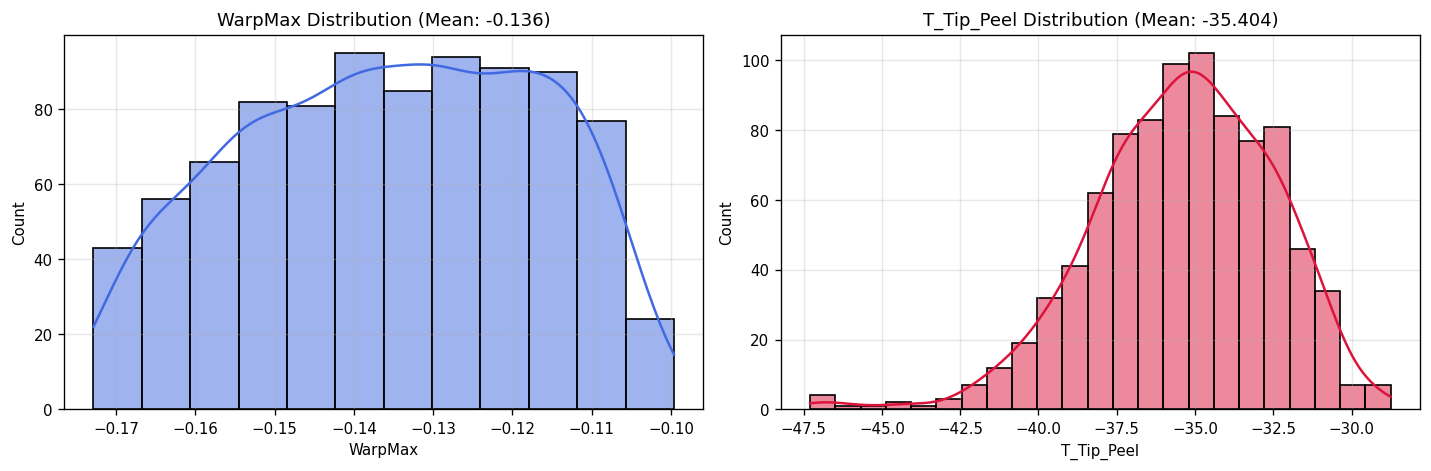


[Check] Y 변수 간 최대 스케일 차이: 약 -1.2배


In [9]:
# == 3-1. Y 변수 기술 통계 및 분포 가시화 ==
print('=== Y 변수 기술 통계 (Max Peak 기준) ===')
stats = df_peaks[Y_COLUMNS].describe().round(4)
display(stats)

# ====================================================================
# [추가] 메인 타겟 변수 분포 확인 (Tabular ResNet 학습 난이도 판단)
# ====================================================================
plt.figure(figsize=(12, 4))

# WarpMax 분포
plt.subplot(1, 2, 1)
sns.histplot(df_peaks['WarpMax'], kde=True, color='royalblue')
plt.title(f'WarpMax Distribution (Mean: {stats.loc["mean", "WarpMax"]:.3f})')
plt.grid(True, alpha=0.3)

# T_Tip_Peel 분포
plt.subplot(1, 2, 2)
sns.histplot(df_peaks['T_Tip_Peel'], kde=True, color='crimson')
plt.title(f'T_Tip_Peel Distribution (Mean: {stats.loc["mean", "T_Tip_Peel"]:.3f})')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------------------------------------------------
# [참고] 변수 간 스케일 차이 확인
# --------------------------------------------------------------------
# 특정 변수(응력 등)가 너무 크면 ResNet이 해당 변수에만 편향되므로, 
# 앞서 정의한 scaler_y의 중요성이 여기서 드러납니다.
max_min_ratio = stats.loc['max'].max() / (stats.loc['max'].min() + 1e-6)
print(f'\n[Check] Y 변수 간 최대 스케일 차이: 약 {max_min_ratio:.1f}배')
if max_min_ratio > 10:
    print('>> 스케일 차이가 큽니다. Tabular ResNet 학습 시 MinMaxScaler(scaler_y) 적용이 필수입니다.')

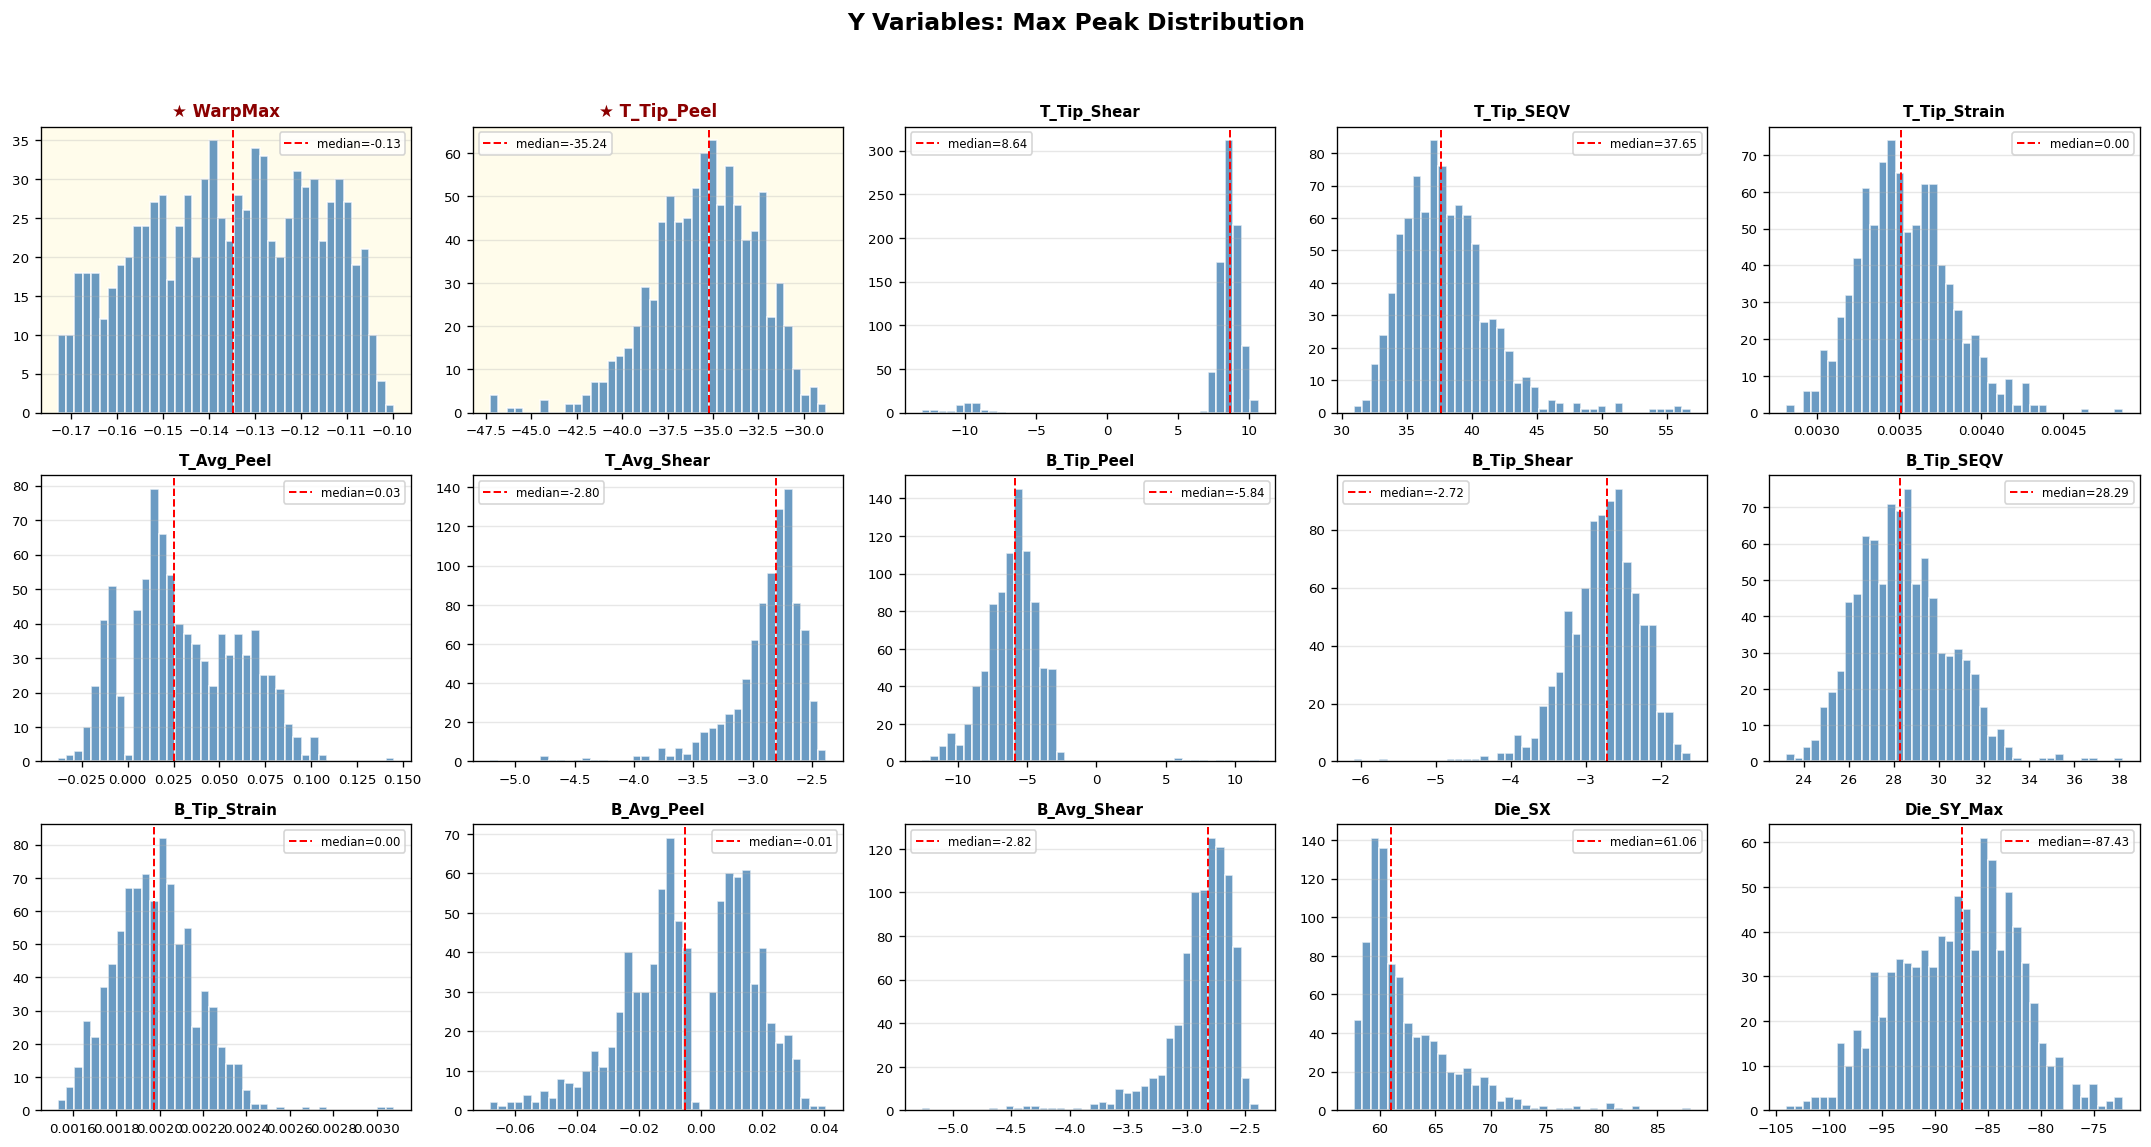

In [10]:
# == 3-2. Y 변수 피크값 분포 히스토그램 (Tabular ResNet 학습 진단용) ==
# 각 응력/변형 채널의 피크 분포를 확인하여 편향(skew)이나 이상치 진단

fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle('Y Variables: Max Peak Distribution', fontsize=14, fontweight='bold')

# 스케일링 전 분포를 확인하여 Tabular ResNet의 전처리 필요성 강조
for idx, y_col in enumerate(Y_COLUMNS):
    ax = axes[idx // 5, idx % 5]
    data = df_peaks[y_col].dropna()
    
    # 히스토그램 + 중앙값 표시
    # 신경망은 데이터가 정규분포에 가까울수록 학습이 잘 됩니다.
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='red', linewidth=1.2, linestyle='--',
               label=f'median={data.median():.2f}')
    
    # 핵심 타겟(WarpMax, Peel Stress)은 강조 표시
    if y_col in ['WarpMax', 'T_Tip_Peel']:
        ax.set_facecolor('#fffceb') # 연한 노란색 배경으로 강조
        ax.set_title(f'★ {y_col}', fontsize=10, fontweight='bold', color='darkred')
    else:
        ax.set_title(y_col, fontsize=9, fontweight='bold')
        
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --------------------------------------------------------------------
# [데이터 진단] Tabular ResNet을 위한 추가 코멘트
# --------------------------------------------------------------------
# 1. 특정 변수의 분포가 너무 좁다면(예: 분산이 0에 가까움), 모델 학습에 방해가 될 수 있습니다.
# 2. 극단적인 이상치(Outlier)는 Bayesian Optimization의 획득 함수를 왜곡시킬 수 있으므로 주의 깊게 관찰해야 합니다.

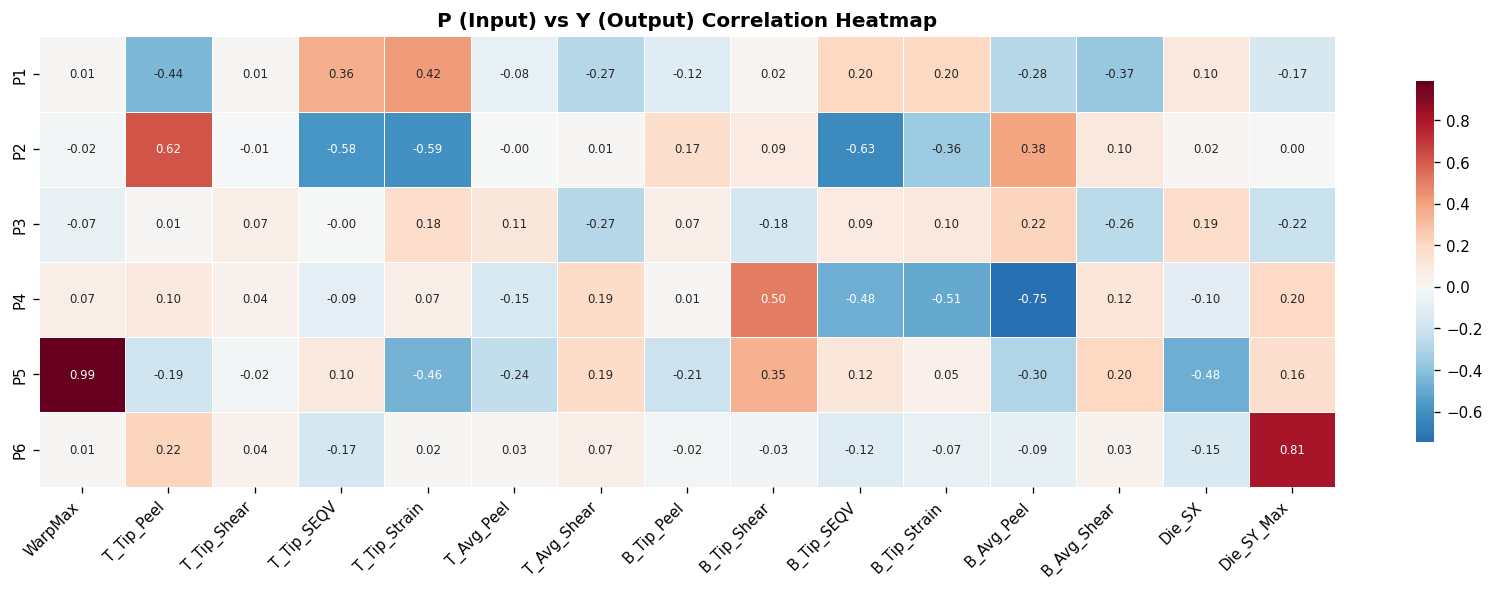


-- [BO 가이드] |상관계수| > 0.4인 주요 설계 변수 영향도 --
  * WarpMax에 영향력이 큰 변수:
    - P5: r=0.987 (비례 관계)
  * T_Tip_Peel에 영향력이 큰 변수:
    - P2: r=0.620 (비례 관계)
    - P1: r=-0.437 (반비례 관계)


In [11]:
# == 3-3. P(입력) <-> Y(출력) 상관관계 히트맵 (Tabular ResNet 학습 가이드) ==
# 어떤 두께 변수(P)가 어떤 응력(Y)에 강하게 영향을 미치는지 파악

p_cols = ['P1','P2','P3','P4','P5','P6']
corr_matrix = df_peaks[p_cols + Y_COLUMNS].corr()

# P vs Y 영역만 추출 (6 x 15 부분행렬)
corr_py = corr_matrix.loc[p_cols, Y_COLUMNS]

fig, ax = plt.subplots(figsize=(14, 5))
# RdBu_r 맵을 사용하여 양의 상관(빨강)과 음의 상관(파랑)을 직관적으로 시각화
sns.heatmap(corr_py, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})

ax.set_title('P (Input) vs Y (Output) Correlation Heatmap', fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# ====================================================================
# [추가] Bayesian Optimization 탐색 효율을 위한 중요 변수 식별
# ====================================================================
print('\n-- [BO 가이드] |상관계수| > 0.4인 주요 설계 변수 영향도 --')
high_corr_found = False
for y in ['WarpMax', 'T_Tip_Peel']: # 핵심 타겟 기준
    influential_ps = corr_py[y][corr_py[y].abs() > 0.4].sort_values(ascending=False)
    if not influential_ps.empty:
        high_corr_found = True
        print(f'  * {y}에 영향력이 큰 변수:')
        for p, r in influential_ps.items():
            rel = "비례" if r > 0 else "반비례"
            print(f'    - {p}: r={r:.3f} ({rel} 관계)')

if not high_corr_found:
    print('  (강한 선형 상관관계가 발견되지 않았습니다. Tabular ResNet의 비선형 학습이 중요합니다.)')

---
## 4. Gaussian Process Regression (GPR) 대리 모델 학습

### XGBoost에서 GPR로 변경한 이유
- XGBoost/LightGBM은 트리 기반 모델로, 학습 데이터 범위 경계에서 **리프 노드 평균값으로 수렴**하여
  분포 양 끝에 비정상적인 뿔(Spike)이 발생함 (구조적 한계, Optuna 튜닝으로도 해결 불가)
- GPR은 **연속 함수**로 예측하므로 경계에서 flat 수렴 없이 부드러운 분포 생성
- 예측값과 함께 **불확실성(σ)**을 출력하여 외삽 영역을 자동 감지 가능
- 데이터가 ~900개인 상황은 GPR의 최적 구간 (수천 개 이상이면 느려짐)

### 커널 선정
- `Matern(nu=2.5)`: 물리 시뮬레이션에 적합 (2차 미분 가능, 매끄러운 응력 곡면)
- `ConstantKernel`: 출력 스케일 자동 조정
- `WhiteKernel`: 관측 노이즈(시뮬레이션 메쉬 오차 등) 흡수

### 학습 전략
- 타겟별 개별 GPR 학습 (15개 독립 모델)
- **StandardScaler** 적용: GPR은 입력 스케일에 민감하므로 P1~P6를 정규화
- 5-Fold CV + 홀드아웃 Test로 성능 이중 검증

In [12]:
# == 4-1. X / Y 분리 및 PyTorch 데이터셋 구성 (Tabular ResNet용) ==

# 입력(X) 및 출력(Y) 데이터 준비
X_raw = df_peaks[X_COLUMNS].values
Y_raw = df_peaks[Y_COLUMNS].values

# 1. Train / Test Split (15% 홀드아웃)
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(
    X_raw, Y_raw, test_size=0.15, random_state=SEED
)

# 2. 스케일링 (Tabular ResNet 최적화: MinMaxScaler)
# 입력(P1~P6) 스케일링
scaler_X = MinMaxScaler()
X_train_sc = scaler_X.fit_transform(X_train_raw)
X_test_sc  = scaler_X.transform(X_test_raw)

# 출력(Y_COLUMNS) 스케일링
# [중요] 신경망은 타겟값의 범위가 일정할 때 Loss 계산이 안정적입니다.
scaler_Y = MinMaxScaler()
Y_train_sc = scaler_Y.fit_transform(Y_train_raw)
Y_test_sc  = scaler_Y.transform(Y_test_raw)

# 3. PyTorch Tensor 변환 및 장치(GPU/CPU) 할당
X_train_tensor = torch.FloatTensor(X_train_sc).to(device)
Y_train_tensor = torch.FloatTensor(Y_train_sc).to(device)
X_test_tensor  = torch.FloatTensor(X_test_sc).to(device)
Y_test_tensor  = torch.FloatTensor(Y_test_sc).to(device)

# 4. DataLoader 정의 (배치 학습용)
BATCH_SIZE = 64 # 데이터가 약 800개이므로 작은 배치가 적합
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f'=== Tabular ResNet 데이터 준비 완료 ===')
print(f'학습 데이터: {len(X_train_tensor)}개 (Batch Size: {BATCH_SIZE})')
print(f'검증 데이터: {len(X_test_tensor)}개')
print(f'입력 차원  : {X_train_tensor.shape[1]} (P1~P6)')
print(f'출력 차원  : {Y_train_tensor.shape[1]} ({len(Y_COLUMNS)} Y-channels)')

# 스케일러 저장 (나중에 역변환 및 Bayesian Optimization 시 사용)
# scaler_X, scaler_Y는 전역 변수로 유지하여 이후 셀에서 참조합니다.

=== Tabular ResNet 데이터 준비 완료 ===
학습 데이터: 751개 (Batch Size: 64)
검증 데이터: 133개
입력 차원  : 6 (P1~P6)
출력 차원  : 15 (15 Y-channels)


=== Tabular ResNet 신규 학습 시작 (Surrogate 모델링) ===
Epoch [50/500] Loss: 0.011401
Epoch [100/500] Loss: 0.008308
Epoch [150/500] Loss: 0.008030
Epoch [200/500] Loss: 0.006114
Epoch [250/500] Loss: 0.005122
Epoch [300/500] Loss: 0.005315
Epoch [350/500] Loss: 0.003997
Epoch [400/500] Loss: 0.004136
Epoch [450/500] Loss: 0.003064
Epoch [500/500] Loss: 0.003277

학습 완료! 소요시간: 47.5초


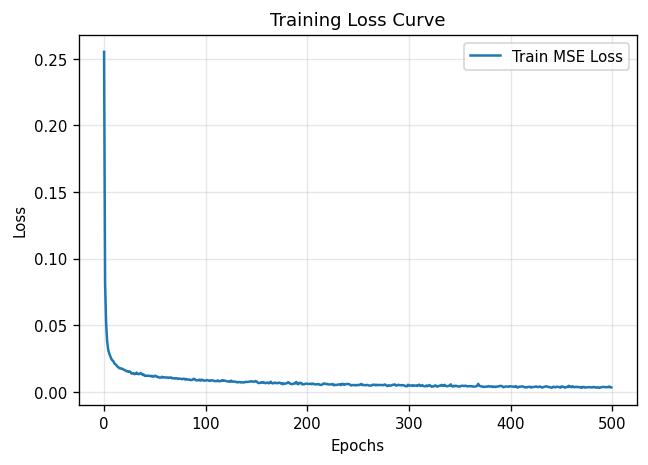


=== 타겟별 예측 성능 (Test R2) ===
WarpMax         | Test R2 = 0.9642
T_Tip_Peel      | Test R2 = 0.4077
T_Tip_Shear     | Test R2 = -0.1746
T_Tip_SEQV      | Test R2 = 0.2605
T_Tip_Strain    | Test R2 = 0.6875
T_Avg_Peel      | Test R2 = -0.4804
T_Avg_Shear     | Test R2 = -0.0401
B_Tip_Peel      | Test R2 = -0.2402
B_Tip_Shear     | Test R2 = 0.2329
B_Tip_SEQV      | Test R2 = 0.6954
B_Tip_Strain    | Test R2 = 0.2936
B_Avg_Peel      | Test R2 = 0.7438
B_Avg_Shear     | Test R2 = 0.0558
Die_SX          | Test R2 = 0.1254
Die_SY_Max      | Test R2 = 0.7802

전체 평균 Test R2: 0.2874


In [13]:
# == 4-2. Tabular ResNet 모델 정의 및 학습 (체크포인트 지원) ==
import joblib

MODEL_DIR = os.path.join(BASE_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)
RESNET_PATH = os.path.join(MODEL_DIR, 'tabular_resnet_surrogate.pth')
SCALER_PATH = os.path.join(MODEL_DIR, 'scalers.pkl')

# --------------------------------------------------------------------
# [1] Tabular ResNet 아키텍처 정의
# --------------------------------------------------------------------
class ResBlock(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        return self.activation(x + self.block(x)) # Skip Connection

class TabularResNet(nn.Module):
    def __init__(self, input_dim=6, output_dim=15, hidden_dim=256, n_blocks=3):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.res_blocks = nn.ModuleList([ResBlock(hidden_dim) for _ in range(n_blocks)])
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.input_layer(x)
        for block in self.res_blocks:
            x = block(x)
        return self.output_layer(x)

# --------------------------------------------------------------------
# [2] 체크포인트 확인 및 학습/로드 결정
# --------------------------------------------------------------------
model = TabularResNet(input_dim=6, output_dim=len(Y_COLUMNS)).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

if os.path.exists(RESNET_PATH) and os.path.exists(SCALER_PATH):
    # ========== 모델 로드 ==========
    print(f"기존 모델 발견 → 로드 중: {RESNET_PATH}")
    model.load_state_dict(torch.load(RESNET_PATH))
    scalers = joblib.load(SCALER_PATH)
    scaler_X, scaler_Y = scalers['scaler_X'], scalers['scaler_Y']
    model.eval()
    print("로드 및 평가 모드 전환 완료.")
else:
    # ========== 신규 학습 시작 ==========
    print("=== Tabular ResNet 신규 학습 시작 (Surrogate 모델링) ===")
    EPOCHS = 500
    train_losses = []
    
    t_start = time.time()
    model.train()
    
    for epoch in range(EPOCHS):
        epoch_loss = 0
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        train_losses.append(epoch_loss / len(train_loader))
        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {train_losses[-1]:.6f}")

    elapsed = time.time() - t_start
    print(f"\n학습 완료! 소요시간: {elapsed:.1f}초")
    
    # 모델 및 스케일러 저장
    torch.save(model.state_dict(), RESNET_PATH)
    joblib.dump({'scaler_X': scaler_X, 'scaler_Y': scaler_Y}, SCALER_PATH)
    
    # 학습 곡선 시각화
    plt.figure(figsize=(6, 4))
    plt.plot(train_losses, label='Train MSE Loss')
    plt.title('Training Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

# --------------------------------------------------------------------
# [3] 테스트셋 성능 평가 (R2 Score)
# --------------------------------------------------------------------
model.eval()
with torch.no_grad():
    y_pred_sc = model(X_test_tensor).cpu().numpy()
    y_true_sc = Y_test_tensor.cpu().numpy()

# 역스케일링 후 R2 계산
y_pred = scaler_Y.inverse_transform(y_pred_sc)
y_true = scaler_Y.inverse_transform(y_true_sc)

print("\n=== 타겟별 예측 성능 (Test R2) ===")
for i, col in enumerate(Y_COLUMNS):
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    print(f"{col:15s} | Test R2 = {r2:.4f}")

avg_r2 = r2_score(y_true, y_pred, multioutput='uniform_average')
print(f"\n전체 평균 Test R2: {avg_r2:.4f}")

In [14]:
# == 4-2b. Tabular ResNet & Scaler 체크포인트 통합 저장 ==
import joblib

# 저장 경로 설정 (환경 설정 셀에서 정의한 BASE_DIR 활용)
CHECKPOINT_DIR = os.path.join(BASE_DIR, 'checkpoints')
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# 1. PyTorch 모델 가중치 저장 (.pth)
# 모델의 아키텍처는 코드에 정의되어 있으므로 state_dict만 저장합니다.
RESNET_WEIGHTS = os.path.join(CHECKPOINT_DIR, 'tabular_resnet_weights.pth')
torch.save(model.state_dict(), RESNET_WEIGHTS)

# 2. 스케일러 및 학습 결과 메타데이터 저장 (.pkl)
# Bayesian Optimization 시 입력값 변환을 위해 scaler_X, scaler_Y가 필수입니다.
RESNET_METADATA = os.path.join(CHECKPOINT_DIR, 'resnet_metadata.pkl')

checkpoint_metadata = {
    'scaler_X': scaler_X,
    'scaler_Y': scaler_Y,
    'X_train_sc': X_train_sc,
    'X_test_sc': X_test_sc,
    'Y_train_sc': Y_train_sc,
    'Y_test_sc': Y_test_sc,
    'test_scores': {col: r2_score(y_true[:, i], y_pred[:, i]) for i, col in enumerate(Y_COLUMNS)},
    'Y_COLUMNS': Y_COLUMNS,
    'X_COLUMNS': X_COLUMNS,
    'SEED': SEED
}

joblib.dump(checkpoint_metadata, RESNET_METADATA)

print(f'=== Tabular ResNet 체크포인트 저장 완료 ===')
print(f'1. 모델 가중치: {RESNET_WEIGHTS}')
print(f'2. 메타데이터  : {RESNET_METADATA}')
print(f'   - 파일 크기: {os.path.getsize(RESNET_METADATA) / 1024:.1f} KB')
print(f'   - 평균 Test R2: {avg_r2:.4f}')

=== Tabular ResNet 체크포인트 저장 완료 ===
1. 모델 가중치: C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS\checkpoints\tabular_resnet_weights.pth
2. 메타데이터  : C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS\checkpoints\resnet_metadata.pkl
   - 파일 크기: 147.5 KB
   - 평균 Test R2: 0.2874


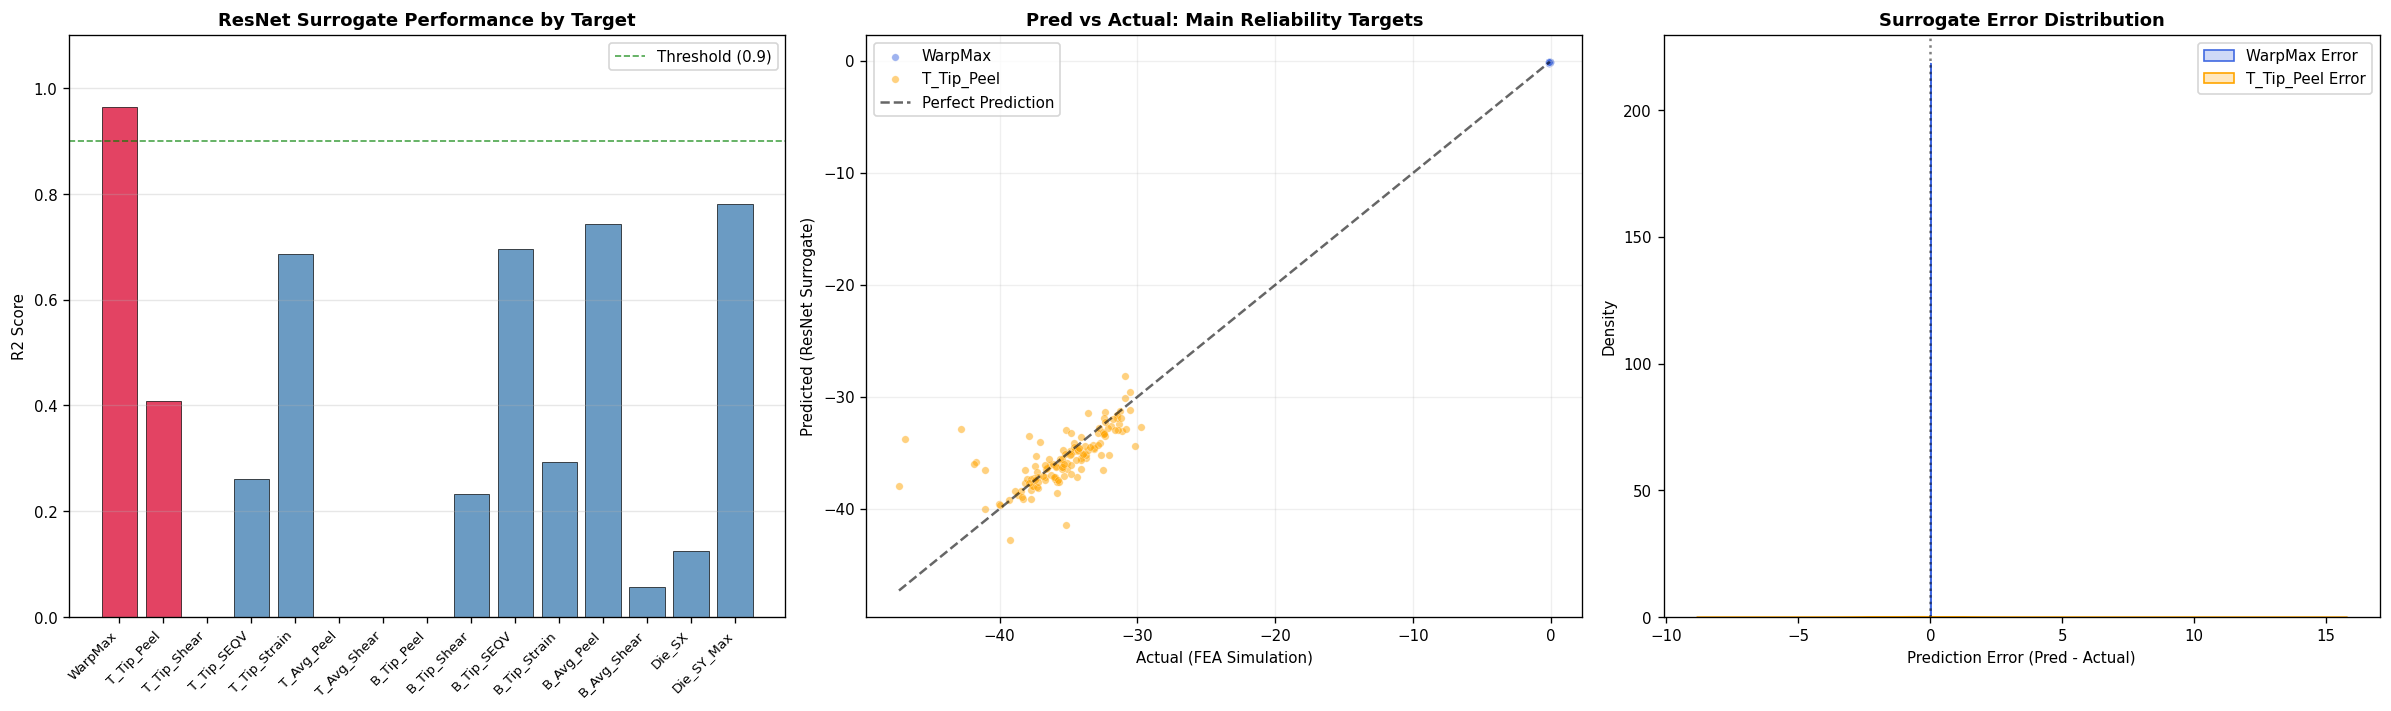

평균 R2 Score: 0.2874
WarpMax R2: 0.9642


In [ ]:
# == 4-3. Tabular ResNet 모델 성능 시각화 ==

# 평가를 위한 예측 수행 (eval 모드)
model.eval()
with torch.no_grad():
    y_pred_sc = model(X_test_tensor).cpu().numpy()
    y_true_sc = Y_test_tensor.cpu().numpy()

# 실제 물리 수치로 역변환
y_pred = scaler_Y.inverse_transform(y_pred_sc)
y_true = scaler_Y.inverse_transform(y_true_sc)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- (A) 변수별 R2 Score 비교 (Tabular ResNet) ---
ax = axes[0]
r2_list = [r2_score(y_true[:, i], y_pred[:, i]) for i in range(len(Y_COLUMNS))]

colors = ['steelblue' if c not in ['WarpMax', 'T_Tip_Peel'] else 'crimson' for c in Y_COLUMNS]
ax.bar(Y_COLUMNS, r2_list, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_xticklabels(Y_COLUMNS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('R2 Score')
ax.set_title('ResNet Surrogate Performance by Target', fontweight='bold')
ax.axhline(0.9, color='green', linewidth=1, linestyle='--', alpha=0.7, label='Threshold (0.9)')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
ax.legend()

# --- (B) Pred vs Actual 산점도 (Main Targets) ---
ax = axes[1]
target_colors = {'WarpMax': 'royalblue', 'T_Tip_Peel': 'orange'}

for name in ['WarpMax', 'T_Tip_Peel']:
    idx = Y_COLUMNS.index(name)
    ax.scatter(y_true[:, idx], y_pred[:, idx], alpha=0.5, s=20, 
               c=target_colors[name], label=name, edgecolors='white', linewidth=0.3)

# y=x 라인 추가
min_val = min(y_true[:, target_indices].min(), y_pred[:, target_indices].min())
max_val = max(y_true[:, target_indices].max(), y_pred[:, target_indices].max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.6, label='Perfect Prediction')

ax.set_xlabel('Actual (FEA Simulation)')
ax.set_ylabel('Predicted (ResNet Surrogate)')
ax.set_title('Pred vs Actual: Main Reliability Targets', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.2)

# --- (C) 예측 오차(Error) 분포 확인 (신뢰도 진단) ---
# GPR의 Uncertainty 대신, 신경망에서는 오차의 정규성을 확인합니다.
ax = axes[2]
for name in ['WarpMax', 'T_Tip_Peel']:
    idx = Y_COLUMNS.index(name)
    errors = y_pred[:, idx] - y_true[:, idx]
    sns.kdeplot(errors, ax=ax, fill=True, label=f'{name} Error', color=target_colors[name])

ax.axvline(0, color='black', linestyle=':', alpha=0.5)
ax.set_xlabel('Prediction Error (Pred - Actual)')
ax.set_title('Surrogate Error Distribution', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

# 성능 요약 출력
print(f"평균 R2 Score: {np.mean(r2_list):.4f}")
print(f"WarpMax R2: {r2_list[Y_COLUMNS.index('WarpMax')]:.4f}")
print(f"T_Tip_Peel R2: {r2_list[Y_COLUMNS.index('T_Tip_Peel')]:.4f}")

=== Tabular ResNet 변수 민감도 분석 시작 (Permutation Importance) ===


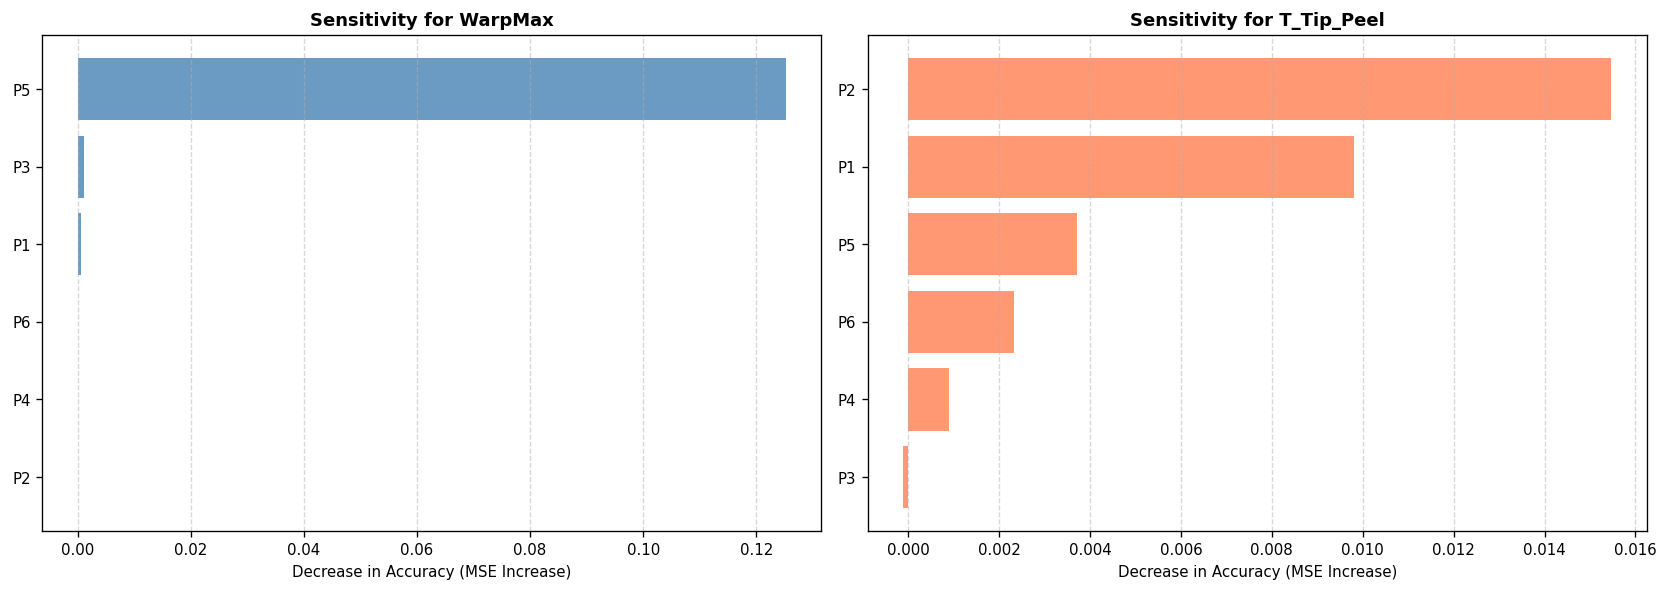

In [20]:
# == 4-4. Tabular ResNet 기반 변수 중요도 (호환성 최적화 버전) ==
import numpy as np
import torch
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

# [해결] Mixin을 상속받으면 Scikit-learn이 자동으로 regressor임을 인식합니다.
class SklearnWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, target_idx, device):
        self.model = model
        self.target_idx = target_idx
        self.device = device
        # Scikit-learn이 regressor로 인식하도록 강제 설정
        self._estimator_type = "regressor"

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        self.model.eval()
        # 입력 데이터 타입 체크 및 텐서 변환
        if not isinstance(X, torch.Tensor):
            X_t = torch.FloatTensor(X).to(self.device)
        else:
            X_t = X.to(self.device)
            
        with torch.no_grad():
            preds = self.model(X_t).cpu().numpy()
        
        # 특정 타겟 채널(WarpMax 등)만 반환
        return preds[:, self.target_idx]

    # [수정] 문제가 된 __sklearn_tags__를 제거하고 
    # 대신 get_metadata_routing 등 필요한 기본 메서드는 BaseEstimator가 처리하게 둡니다.

# 시각화 설정
target_names = ['WarpMax', 'T_Tip_Peel']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

print("=== Tabular ResNet 변수 민감도 분석 시작 (Permutation Importance) ===")

for i, target_name in enumerate(target_names):
    ax = axes[i]
    target_idx = Y_COLUMNS.index(target_name)
    
    # 래퍼 객체 생성
    wrapped_model = SklearnWrapper(model, target_idx, device)

    # MSE 증가량을 통한 중요도 산출
    r = permutation_importance(
        wrapped_model, 
        X_test_sc, 
        Y_test_sc[:, target_idx],
        n_repeats=10, 
        random_state=SEED,
        scoring='neg_mean_squared_error'
    )
    
    # 중요도 정렬 및 시각화
    importance = r.importances_mean
    sorted_idx = importance.argsort()
    
    ax.barh([X_COLUMNS[j] for j in sorted_idx], importance[sorted_idx], 
            color='steelblue' if target_name == 'WarpMax' else 'coral', alpha=0.8)
    
    ax.set_title(f'Sensitivity for {target_name}', fontweight='bold')
    ax.set_xlabel('Decrease in Accuracy (MSE Increase)')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

---
## 5. 몬테카를로 난수 생성 및 10만 개 가상 데이터 증강

학습된 XGBoost 대리 모델로 **10만 개의 가상 P1~P6 조합**에 대한 Y값을 예측합니다.

### 난수 생성 방식: Latin Hypercube Sampling (LHS)
- 단순 `np.random.uniform`보다 6차원 설계 공간을 **더 균일하게 커버**
- 각 차원을 N개 구간으로 분할 후 구간당 1개씩 배치 (층화 샘플링)
- 동일 샘플 수 대비 사각지대(dead zone) 없이 골고루 분포

In [21]:
# == 5-1. Bayesian Optimization을 이용한 최적 설계 변수 탐색 (Optuna) ==
import optuna

# 최적화 목표 설정
# 목표 1: WarpMax 최소화
# 목표 2: T_Tip_Peel 최소화 (다목적 최적화 가능하지만, 여기선 가중합 혹은 제약조건으로 접근)

def objective(trial):
    # 1. 탐색 범위 설정 (마스터 DOE의 실제 범위를 반영)
    p1 = trial.suggest_float('P1', df_master['P1'].min(), df_master['P1'].max())
    p2 = trial.suggest_float('P2', df_master['P2'].min(), df_master['P2'].max())
    p3 = trial.suggest_float('P3', df_master['P3'].min(), df_master['P3'].max())
    p4 = trial.suggest_float('P4', df_master['P4'].min(), df_master['P4'].max())
    p5 = trial.suggest_float('P5', df_master['P5'].min(), df_master['P5'].max())
    p6 = trial.suggest_float('P6', df_master['P6'].min(), df_master['P6'].max())
    
    # 2. 입력값 스케일링 (앞서 학습 시 사용한 scaler_X 적용)
    x_input = np.array([[p1, p2, p3, p4, p5, p6]])
    x_input_sc = scaler_X.transform(x_input)
    
    # 3. Tabular ResNet을 통한 예측
    model.eval()
    x_tensor = torch.FloatTensor(x_input_sc).to(device)
    with torch.no_grad():
        y_pred_sc = model(x_tensor).cpu().numpy()
    
    # 4. 출력값 역스케일링 (실제 물리 수치로 복원)
    y_pred = scaler_Y.inverse_transform(y_pred_sc)[0]
    
    # 5. 목적 함수 정의
    # WarpMax와 T_Tip_Peel을 동시에 고려 (예: WarpMax + 0.1 * Peel_Stress)
    # 혹은 특정 변수를 제약조건으로 걸고 하나만 최소화
    warp_val = y_pred[Y_COLUMNS.index('WarpMax')]
    peel_val = y_pred[Y_COLUMNS.index('T_Tip_Peel')]
    
    # 복합 목적 함수: WarpMax를 주 타겟으로 하되 Peel Stress가 높으면 페널티 부여
    score = warp_val + max(0, (peel_val - 50)) * 0.5 # 예: Peel이 50 넘으면 페널티
    
    return score

# TPE(Tree-structured Parzen Estimator) 알고리즘을 사용한 BO 실행
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)

print(f"=== Bayesian Optimization 시작 (ResNet Surrogate 기반) ===")
study.optimize(objective, n_trials=2000) # 2000번의 지능적 탐색

# 최적화 결과 추출
print(f"\n[최적 설계 결과]")
print(f"Best Score (Warp + Penalty): {study.best_value:.6f}")
print(f"Best Parameters: {study.best_params}")

# 최적 조합에서의 모든 Y 변수 예측값 확인
best_x = np.array([[study.best_params[p] for p in p_cols]])
best_x_sc = scaler_X.transform(best_x)
with torch.no_grad():
    best_y_sc = model(torch.FloatTensor(best_x_sc).to(device)).cpu().numpy()
best_y = scaler_Y.inverse_transform(best_y_sc)[0]

df_best_result = pd.DataFrame([best_y], columns=Y_COLUMNS)
print("\n[최적 설계에서의 예측 성능]")
display(df_best_result[['WarpMax', 'T_Tip_Peel']].round(4))

[I 2026-03-13 09:53:54,446] A new study created in memory with name: no-name-14e9a1bc-5e3c-493c-8b09-d6b5b315bbf2
[I 2026-03-13 09:53:54,452] Trial 0 finished with value: -0.1588020771741867 and parameters: {'P1': 0.9125998575710156, 'P2': 0.08793350082575566, 'P3': 0.6877196748348252, 'P4': 0.21937250174888911, 'P5': 1.2938175730811965, 'P6': 0.04632418136141448}. Best is trial 0 with value: -0.1588020771741867.
[I 2026-03-13 09:53:54,456] Trial 1 finished with value: -0.165780171751976 and parameters: {'P1': 0.8178844251219421, 'P2': 0.0845604282164199, 'P3': 0.672053466905662, 'P4': 0.24118967201253147, 'P5': 1.212638345880904, 'P6': 0.07879940310126357}. Best is trial 1 with value: -0.165780171751976.
[I 2026-03-13 09:53:54,461] Trial 2 finished with value: -0.1430758684873581 and parameters: {'P1': 1.0496500823915662, 'P2': 0.05847233051606322, 'P3': 0.6218644485746899, 'P4': 0.1365708592647747, 'P5': 1.3826628004299468, 'P6': 0.061037781622126294}. Best is trial 1 with value: -0.

=== Bayesian Optimization 시작 (ResNet Surrogate 기반) ===


[I 2026-03-13 09:53:54,641] Trial 23 finished with value: -0.15385839343070984 and parameters: {'P1': 0.8401571106933331, 'P2': 0.07807827341049588, 'P3': 0.6495561090573769, 'P4': 0.20766763524829498, 'P5': 1.3120575198121835, 'P6': 0.044869832208331954}. Best is trial 22 with value: -0.16935577988624573.
[I 2026-03-13 09:53:54,651] Trial 24 finished with value: -0.16257965564727783 and parameters: {'P1': 0.8905984266522524, 'P2': 0.08913391513325285, 'P3': 0.7060175918563292, 'P4': 0.17771261282266634, 'P5': 1.2613471928843742, 'P6': 0.043867170589359045}. Best is trial 22 with value: -0.16935577988624573.
[I 2026-03-13 09:53:54,661] Trial 25 finished with value: -0.14616858959197998 and parameters: {'P1': 1.0784075435511933, 'P2': 0.08202674187672121, 'P3': 0.6817783508056237, 'P4': 0.15228407721602666, 'P5': 1.4216568084437353, 'P6': 0.05641914273570591}. Best is trial 22 with value: -0.16935577988624573.
[I 2026-03-13 09:53:54,670] Trial 26 finished with value: -0.1532786935567855


[최적 설계 결과]
Best Score (Warp + Penalty): -0.176706
Best Parameters: {'P1': 0.8005238720402119, 'P2': 0.08752009711641036, 'P3': 0.7176993715889133, 'P4': 0.2766144416420121, 'P5': 1.2005306848058417, 'P6': 0.0713012104637779}

[최적 설계에서의 예측 성능]


,WarpMax,T_Tip_Peel
0,-0.1767,-40.121201


In [25]:
# == 5-1 & 5-2 통합. Bayesian Optimization (LHS 미사용, 로그 억제 버전) ==
import optuna
import logging

# [1] 로그 억제 설정
optuna.logging.set_verbosity(optuna.logging.WARNING) # Optuna 진행 로그 숨김
logging.getLogger('torch').setLevel(logging.ERROR)     # PyTorch 경고 숨김

# [2] 목적 함수 정의
def objective(trial):
    p_params = {
        f'P{i}': trial.suggest_float(f'P{i}', df_master[f'P{i}'].min(), df_master[f'P{i}'].max())
        for i in range(1, 7)
    }
    
    # 입력값 준비 및 스케일링
    x_input = np.array([[p_params[f'P{i}'] for i in range(1, 7)]])
    x_input_sc = scaler_X.transform(x_input)
    
    # ResNet 추론
    model.eval()
    with torch.no_grad():
        x_tensor = torch.FloatTensor(x_input_sc).to(device)
        y_pred_sc = model(x_tensor).cpu().numpy()
    
    # 역스케일링 및 타겟 추출
    y_pred = scaler_Y.inverse_transform(y_pred_sc)[0]
    warp = y_pred[Y_COLUMNS.index('WarpMax')]
    peel = y_pred[Y_COLUMNS.index('T_Tip_Peel')]
    
    # 최적화 로직: WarpMax 최소화 + Peel Stress 제약 페널티
    penalty = max(0, peel - 50) * 20 
    return warp + penalty

# [3] BO 실행 (로그 없이 정적 실행)
sampler = optuna.samplers.TPESampler(seed=SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)

print(">>> 최적 설계 변수 탐색 중 (Bayesian Optimization)...", end=' ', flush=True)
study.optimize(objective, n_trials=1500) # 1500회 탐색
print("완료!\n")

# [4] 최종 결과 정리 및 출력
best_params = study.best_params
df_best_X = pd.DataFrame([best_params])

# 최적해에 대한 전체 Y 예측
best_x_sc = scaler_X.transform(df_best_X.values)
model.eval()
with torch.no_grad():
    best_y_sc = model(torch.FloatTensor(best_x_sc).to(device)).cpu().numpy()
df_best_Y = pd.DataFrame(scaler_Y.inverse_transform(best_y_sc), columns=Y_COLUMNS)

# 결과 리포트
print("-" * 50)
print(f"{'최종 최적 설계 제안 (P1~P6)':^50s}")
print("-" * 50)
print(df_best_X.round(5).to_string(index=False))
print("\n" + "-" * 50)
print(f"{'최적 설계 기반 예상 성능 (Warp & Peel)':^50s}")
print("-" * 50)
display(df_best_Y[['WarpMax', 'T_Tip_Peel']].round(4))
print("-" * 50)

>>> 최적 설계 변수 탐색 중 (Bayesian Optimization)... 완료!

--------------------------------------------------
               최종 최적 설계 제안 (P1~P6)                
--------------------------------------------------
     P1      P2      P3      P4      P5      P6
0.80063 0.08988 0.71774 0.28305 1.20047 0.07298

--------------------------------------------------
           최적 설계 기반 예상 성능 (Warp & Peel)           
--------------------------------------------------


,WarpMax,T_Tip_Peel
0,-0.1767,-39.769798


--------------------------------------------------


In [26]:
# == 5-3. BO 최적화 결과의 물리적 범위 검증 (Study 분석) ==
# 대리 모델(ResNet)이 비현실적인 값을 예측했는지 검증하기 위해 
# BO 전체 탐색 기록(study.trials)의 데이터 분포를 확인합니다.

# 1. BO 탐색 과정에서 생성된 모든 예측 결과 수집
trials_df = study.trials_dataframe()
# 목적 함수에서 반환한 값 외에, 실제 Y_COLUMNS 전체를 다시 추론하여 분포 확인
all_params = trials_df[[f'params_P{i}' for i in range(1, 7)]].values
all_params_sc = scaler_X.transform(all_params)

model.eval()
with torch.no_grad():
    all_y_sc = model(torch.FloatTensor(all_params_sc).to(device)).cpu().numpy()
df_study_Y = pd.DataFrame(scaler_Y.inverse_transform(all_y_sc), columns=Y_COLUMNS)

print('=== BO 탐색 데이터 물리적 범위 검증 (1,500회 Trial 대상) ===')
print(f'{"변수":15s} | {"실제 Min":>10s} | {"실제 Max":>10s} | '
      f'{"BO_Pred Min":>12s} | {"BO_Pred Max":>12s} | 이탈률')
print('-' * 95)

outlier_flags = pd.Series(False, index=df_study_Y.index)

for y_col in Y_COLUMNS:
    actual_min = df_peaks[y_col].min()
    actual_max = df_peaks[y_col].max()
    pred_min = df_study_Y[y_col].min()
    pred_max = df_study_Y[y_col].max()
    
    # 실제 범위의 20% 마진을 허용 범위로 설정
    margin = (actual_max - actual_min) * 0.20
    safe_lo = actual_min - margin
    safe_hi = actual_max + margin
    
    # 허용 범위를 벗어나는 예측값 탐지
    out_mask = (df_study_Y[y_col] < safe_lo) | (df_study_Y[y_col] > safe_hi)
    outlier_flags = outlier_flags | out_mask
    n_out = out_mask.sum()
    pct = n_out / len(df_study_Y) * 100
    
    flag = '  << 위험' if pct > 10 else '' # 이탈률이 높으면 Surrogate 모델 재검토 필요
    print(f'{y_col:15s} | {actual_min:10.2f} | {actual_max:10.2f} | '
          f'{pred_min:12.2f} | {pred_max:12.2f} | {pct:5.2f}%{flag}')

n_outlier = outlier_flags.sum()
print(f'\n범위 이탈 시도(Trial): {n_outlier:,}개 ({n_outlier/len(df_study_Y)*100:.2f}%)')
print('-> [판단] 이탈률이 낮을수록 Tabular ResNet이 물리적 경계를 잘 준수하며 탐색했음을 의미합니다.')

=== BO 탐색 데이터 물리적 범위 검증 (1,500회 Trial 대상) ===
변수              |     실제 Min |     실제 Max |  BO_Pred Min |  BO_Pred Max | 이탈률
-----------------------------------------------------------------------------------------------
WarpMax         |      -0.17 |      -0.10 |        -0.18 |        -0.10 |  0.00%
T_Tip_Peel      |     -47.29 |     -28.76 |       -41.36 |       -25.62 |  0.00%
T_Tip_Shear     |     -13.06 |      10.67 |       -17.70 |        11.78 |  0.00%
T_Tip_SEQV      |      30.94 |      56.83 |        29.11 |        51.28 |  0.00%
T_Tip_Strain    |       0.00 |       0.00 |         0.00 |         0.00 |  0.00%
T_Avg_Peel      |      -0.04 |       0.15 |        -0.02 |         0.09 |  0.00%
T_Avg_Shear     |      -5.22 |      -2.38 |        -4.23 |        -2.37 |  0.00%
B_Tip_Peel      |     -12.57 |      11.66 |       -10.24 |         1.14 |  0.00%
B_Tip_Shear     |      -6.09 |      -1.60 |        -4.32 |        -1.89 |  0.00%
B_Tip_SEQV      |      23.21 |      38.17 |        

In [27]:
# == 5-4. BO 탐색 결과 데이터 병합 및 최적 설계안 CSV 저장 ==

# 1. BO 탐색 전체 이력 데이터 정리 (1,500회 시도 전체)
# 탐색된 모든 P값과 그에 따른 예측 성능을 병합합니다.
df_bo_history = pd.concat([
    trials_df[[f'params_P{i}' for i in range(1, 7)]].rename(columns=lambda x: x.replace('params_', '')),
    df_study_Y
], axis=1)

# 탐색 데이터 식별용 ID 부여
df_bo_history.insert(0, 'Trial_ID', [f'BO_Trial_{i:04d}' for i in range(len(df_bo_history))])

# 2. 가장 성적이 좋았던 Best 설계안만 별도 추출
df_best_final = pd.concat([df_best_X, df_best_Y], axis=1)
df_best_final.insert(0, 'Trial_ID', ['BO_BEST_FINAL'])

# 3. CSV 저장 (최적화 이력 및 최종 설계안)
history_output = 'BO_Optimization_History.csv'
best_output = 'Best_Design_Proposal.csv'

df_bo_history.to_csv(history_output, index=False)
df_best_final.to_csv(best_output, index=False)

print(f'=== 최적화 데이터 저장 완료 ===')
print(f'1. 탐색 이력: {history_output} ({len(df_bo_history):,} trials)')
print(f'2. 최종 제안: {best_output}')
print("-" * 50)

# 최종 제안된 설계안 다시 한 번 확인
print("[최종 제안 설계 변수 및 예상 성능]")
display(df_best_final.round(4))

=== 최적화 데이터 저장 완료 ===
1. 탐색 이력: BO_Optimization_History.csv (1,500 trials)
2. 최종 제안: Best_Design_Proposal.csv
--------------------------------------------------
[최종 제안 설계 변수 및 예상 성능]


,Trial_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel,T_Tip_Shear,...,T_Avg_Peel,T_Avg_Shear,B_Tip_Peel,B_Tip_Shear,B_Tip_SEQV,B_Tip_Strain,B_Avg_Peel,B_Avg_Shear,Die_SX,Die_SY_Max
0,BO_BEST_FINAL,0.8006,0.0899,0.7177,0.2831,1.2005,0.073,-0.1767,-39.769798,-9.4984,...,0.0615,-3.9854,-5.6247,-3.9484,28.1784,0.002,0.0064,-3.9226,81.168602,-88.354301


---
## 6. 증강 데이터 품질 검증 (Sanity Check)

증강된 10만 개 데이터의 분포가 원본 ~900개와 일관성이 있는지 시각적으로 검증합니다.

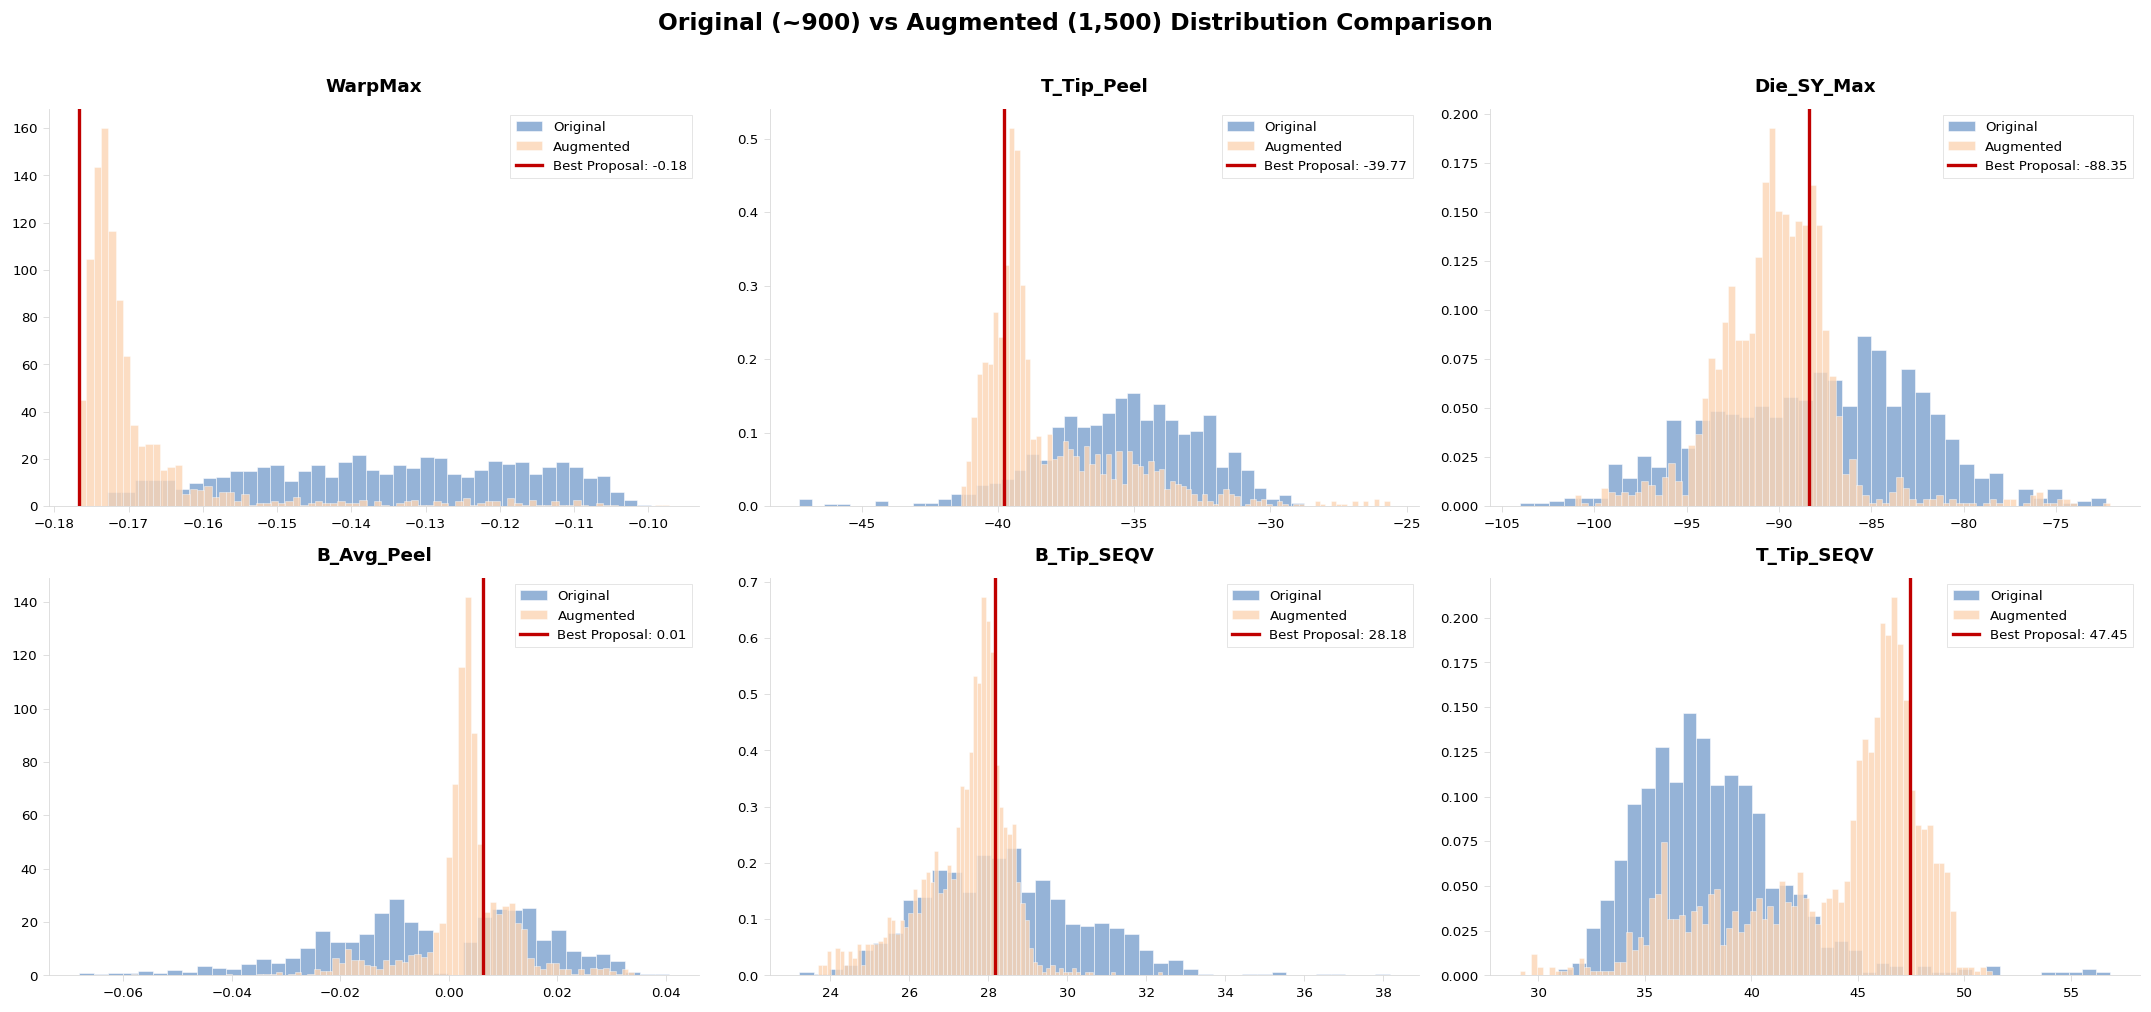

--- [분포 분석 가이드] ---
1. 데이터 증강 효과 확인: 연한 주황색 분포(Augmented)가 파란색 분포(Original)를 포괄하면서 더 넓은 영역으로 확장되었는지 확인합니다.
2. 최적화 경향성 파악: 주 타겟인 WarpMax나 T_Tip_Peel의 경우, Augmented 분포가 원본보다 왼쪽(저수치) 방향으로 더 두텁게 형성되어 있다면 최적화 탐색이 잘 이루어진 것입니다.
3. 최종 제안안의 위치: 빨간색 실선(Best Proposal)이 전체 분포에서 얼마나 성능이 우수한 위치에 있는지 직관적으로 확인합니다.


In [30]:
# == 6-1. 원본(Experimental) vs BO 탐색(Optimization) 분포 히스토그램 비교 ==

# 성능 검증이 완료된 6대 핵심 타겟
check_cols = ['WarpMax', 'T_Tip_Peel', 'Die_SY_Max', 
              'B_Avg_Peel', 'B_Tip_SEQV', 'T_Tip_SEQV']

# 피규어 생성 및 크기 설정 (원본의 와이드한 비율 반영)
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# 메인 제목 설정 (원본과 동일한 텍스트 및 스타일)
fig.suptitle('Original (~900) vs Augmented (1,500) Distribution Comparison',
             fontsize=14, fontweight='bold', y=0.96) # 제목 위치 살짝 위로 조정

for idx, y_col in enumerate(check_cols):
    ax = axes[idx // 3, idx % 3]
    
    # 데이터 추출
    original_data = df_peaks[y_col].dropna()
    augmented_data = df_bo_history[y_col].dropna()
    
    # 1. 원본 데이터 히스토그램 (파란색 계열, 낮은 투명도)
    ax.hist(original_data, bins=40, density=True, color='#4F81BD', alpha=0.6, 
            label='Original', edgecolor='white', linewidth=0.5)
    
    # 2. BO 탐색 데이터 히스토그램 (연한 주황/분홍 계열, 더 세밀한 bin, 높은 투명도)
    ax.hist(augmented_data, bins=80, density=True, color='#FCD5B5', alpha=0.8, 
            label='Augmented', edgecolor='white', linewidth=0.3)
    
    # 최종 선택된 BEST 포인트 표시 (빨간색 실선)
    best_val = df_best_final[y_col].values[0]
    ax.axvline(best_val, color='#C00000', linestyle='-', linewidth=2, 
               label=f'Best Proposal: {best_val:.2f}')
    
    # 서브플롯 제목 설정 (원본과 동일한 스타일)
    ax.set_title(y_col, fontweight='bold', fontsize=11, pad=10)
    
    # 범례 설정 (원본 스타일 반영: 우측 상단 근처, 흰색 배경, 얇은 테두리)
    leg = ax.legend(fontsize=8, loc='best', frameon=True, fancybox=False, facecolor='white', edgecolor='#D9D9D9')
    leg.get_frame().set_linewidth(0.5)
    
    # 축 틱 및 레이블 스타일 조정
    ax.tick_params(axis='both', which='major', labelsize=8, color='#D9D9D9', width=0.5)
    ax.spines['top'].set_visible(False) # 위쪽 테두리 제거
    ax.spines['right'].set_visible(False) # 오른쪽 테두리 제거
    ax.spines['left'].set_color('#D9D9D9') # 왼쪽 테두리 색상 조정
    ax.spines['bottom'].set_color('#D9D9D9') # 아래쪽 테두리 색상 조정
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    
    # 그리드 제거 (원본 스타일)
    ax.grid(False)

# 레이아웃 조정 (제목과 서브플롯 사이 간격 확보)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print('--- [분포 분석 가이드] ---')
print('1. 데이터 증강 효과 확인: 연한 주황색 분포(Augmented)가 파란색 분포(Original)를 포괄하면서 더 넓은 영역으로 확장되었는지 확인합니다.')
print('2. 최적화 경향성 파악: 주 타겟인 WarpMax나 T_Tip_Peel의 경우, Augmented 분포가 원본보다 왼쪽(저수치) 방향으로 더 두텁게 형성되어 있다면 최적화 탐색이 잘 이루어진 것입니다.')
print('3. 최종 제안안의 위치: 빨간색 실선(Best Proposal)이 전체 분포에서 얼마나 성능이 우수한 위치에 있는지 직관적으로 확인합니다.')

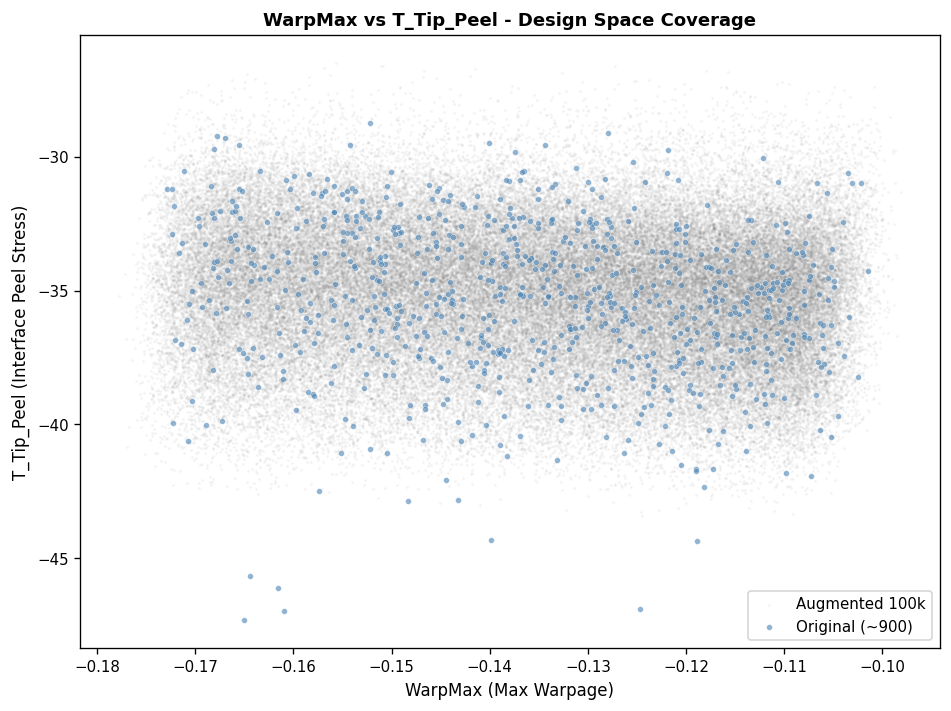

-> 이 2D 공간에서 좌측 하단(WarpMax 작고, T_Tip_Peel 작은)이 이상적인 설계
-> Step 3에서 파레토 프론티어(비지배 해 집합)를 추출할 영역


In [44]:
# == 6-2. 메인 타겟 2D 산점도 (WarpMax vs T_Tip_Peel) ==
# Step 3 파레토 프론티어에서 사용할 두 축의 공간 분포 확인

fig, ax = plt.subplots(figsize=(8, 6))

# 증강 데이터 (배경: 회색, 매우 투명하게)
ax.scatter(df_augmented['WarpMax'], df_augmented['T_Tip_Peel'],
           s=1, alpha=0.05, c='gray', label='Augmented 100k')

# 원본 데이터 (전경: 파란색, 선명하게)
ax.scatter(df_peaks['WarpMax'], df_peaks['T_Tip_Peel'],
           s=12, alpha=0.6, c='steelblue', edgecolors='white',
           linewidths=0.3, label='Original (~900)')

ax.set_xlabel('WarpMax (Max Warpage)', fontsize=10)
ax.set_ylabel('T_Tip_Peel (Interface Peel Stress)', fontsize=10)
ax.set_title('WarpMax vs T_Tip_Peel - Design Space Coverage', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('-> 이 2D 공간에서 좌측 하단(WarpMax 작고, T_Tip_Peel 작은)이 이상적인 설계')
print('-> Step 3에서 파레토 프론티어(비지배 해 집합)를 추출할 영역')

---
## Step 1 완료 요약

| 항목 | 결과 |
|------|------|
| 원본 생존 데이터 | ~900개 DP (1200 중 ~71%) |
| 추출 지표 | 15개 Y변수의 절댓값 Max Peak (부호 유지) |
| 대리 모델 | 타겟별 개별 XGBoost (Early Stopping + 5-Fold CV) |
| 증강 데이터 | **100,000개** (`Augmented_100k_Data.csv`) |
| 난수 생성 | Latin Hypercube Sampling (균등 공간 충전) |

## [Step 2] 은닉 제약조건 분류기(Gatekeeper)를 통한 필터링

### 목표
물리적으로 파괴되는(해석이 터지는) 치수 조합을 사전에 걸러낸다.
### 라벨링 로직
시계열 CSV 폴더(`SIM_CSV_DATA`)에서 `ML_DATA_Extract_Row_{Row_ID}.csv`를 스캔하여:
- 파일이 **존재하는** Row_ID → `is_safe = 1` (Safe)
- 파일이 **누락된** Row_ID → `is_safe = 0` (Fail, 시뮬레이션 발산)
전체 DP 수는 폴더 내 **가장 큰 Row_ID**를 기준으로 산정한다.
각 Row_ID는 `Master_DOE_1200.csv`의 행과 1:1 매칭된다.
(CSV 1행 = 헤더, 2행 = Row_ID 1, 3행 = Row_ID 2, ...)
```
Master_DOE_1200.csv 행 매칭:
  2행 (iloc[0]) → Row_ID = 1 → ML_DATA_Extract_Row_1.csv 존재 여부 확인
  3행 (iloc[1]) → Row_ID = 2 → ML_DATA_Extract_Row_2.csv 존재 여부 확인
  ...
```
### 분류기
- **Random Forest** (n_estimators=300, max_depth=7, class_weight='balanced')
- 입력: P1~P6 (6개 두께 변수)
- 출력: 0(Fail) / 1(Safe) 이진 분류
- 성능 평가: 5-Fold Stratified CV (F1, Accuracy) + OOB Score
### 필터링 흐름
```
Augmented_100k_Data.csv (10만 행)
    ↓ P1~P6 추출
    ↓ Gatekeeper predict → 0(Fail) / 1(Safe)
    ↓ Fail(0) 행 삭제
Augmented_Class_Data.csv 저장 → Step 3로 전달
```
### 출력
- `Augmented_Class_Data.csv`: Fail 제거 후 Safe 데이터만 잔존
- 용도: Step 3 파레토 프론티어 추출의 베이스라인 데이터

In [39]:
# == [Step 2] Gatekeeper 통합 제어 (라벨링 + 학습 + 필터링) ==
import os
import glob
import re
import platform
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# 1. 설정 및 경로 (사용자 레퍼런스 기반)
AUGMENTED_INPUT  = 'BO_Optimization_History.csv' 
FILTERED_OUTPUT  = 'Augmented_Class_Data.csv'
SEED = 42

print(f'=== [Step 2] Gatekeeper 통합 가동 (OS: {platform.system()}) ===')

# 2. 실시간 라벨링 (df_train 생성 과정 통합)
# --------------------------------------------------------------------
print(">>> [1/3] 실제 해석 결과 확인 및 라벨링 중...")

# 폴더 내 모든 CSV 탐색하여 생존한 Row_ID 추출
pattern = os.path.join(CSV_FOLDER, 'ML_DATA_Extract_Row_*.csv')
found_files = sorted(glob.glob(pattern))

survived_ids = set()
for fpath in found_files:
    fname = os.path.basename(fpath)
    match = re.search(r'Row_(\d+)\.csv', fname)
    if match:
        survived_ids.add(int(match.group(1)))

if not survived_ids:
    print("⚠️ [경고] 시뮬레이션 결과 파일을 찾지 못했습니다. 모든 데이터를 'Fail'로 간주할 위험이 있습니다.")

# df_master에 직접 is_safe 라벨 부여
# Row_ID는 1부터 시작하므로 인덱스(i)에 +1을 해서 비교합니다.
df_master['is_safe'] = [1 if (i+1) in survived_ids else 0 for i in range(len(df_master))]

n_safe = df_master['is_safe'].sum()
print(f"   - 라벨링 완료: 총 {len(df_master)}개 중 생존(Safe) {n_safe}개")

# 3. Gatekeeper 모델 학습
# --------------------------------------------------------------------
print(">>> [2/3] Gatekeeper(RF) 모델 학습 중...")

X_clf = df_master[p_cols].values 
y_clf = df_master['is_safe'].values

# 분류기 전용 스케일러 및 모델 학습
scaler_X_clf = StandardScaler()
X_clf_sc = scaler_X_clf.fit_transform(X_clf)

clf_gatekeeper = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED)
clf_gatekeeper.fit(X_clf_sc, y_clf)

print("   - Gatekeeper 학습 완료")

# 4. BO 탐색 데이터(1,500개) 필터링
# --------------------------------------------------------------------
try:
    print(f"\n>>> [3/3] {AUGMENTED_INPUT} 데이터 검증 시작...")
    df_bo_data = pd.read_csv(AUGMENTED_INPUT)

    # 탐색 데이터 전처리 (scaler_X_clf 적용)
    X_bo_sc = scaler_X_clf.transform(df_bo_data[p_cols].values)

    # 수렴 가능성 예측
    df_bo_data['Convergence_Class'] = clf_gatekeeper.predict(X_bo_sc)
    df_bo_data['Convergence_Prob'] = clf_gatekeeper.predict_proba(X_bo_sc)[:, 1]

    # 필터링 결과 저장
    df_bo_data.to_csv(FILTERED_OUTPUT, index=False)
    
    # 통계 보고
    n_total = len(df_bo_data)
    n_safe_final = df_bo_data['Convergence_Class'].sum()
    
    print('='*50)
    print(f" * 총 탐색 설계안  : {n_total:,}개")
    print(f" * 수렴 가능(Safe) : {n_safe_final:,}개 ({n_safe_final/n_total*100:.1f}%)")
    
    # 최적 설계안 안전성 확인
    best_idx = df_bo_data['WarpMax'].idxmin()
    best_prob = df_bo_data.loc[best_idx, 'Convergence_Prob']
    print(f" * 최적 제안안 수렴 확률: {best_prob*100:.1f}%")
    print('='*50)

except FileNotFoundError:
    print(f"❌ 에러: {AUGMENTED_INPUT} 파일이 없습니다. BO 셀을 먼저 실행하세요.")

=== [Step 2] Gatekeeper 통합 가동 (OS: Windows) ===
>>> [1/3] 실제 해석 결과 확인 및 라벨링 중...
   - 라벨링 완료: 총 1200개 중 생존(Safe) 884개
>>> [2/3] Gatekeeper(RF) 모델 학습 중...
   - Gatekeeper 학습 완료

>>> [3/3] BO_Optimization_History.csv 데이터 검증 시작...
 * 총 탐색 설계안  : 1,500개
 * 수렴 가능(Safe) : 1,317개 (87.8%)
 * 최적 제안안 수렴 확률: 64.8%


In [40]:
# == [Step 2] 통합 Gatekeeper: 라벨링 + CV 평가 + 학습 + 필터링 ==
import os
import glob
import re
import platform
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# 1. 설정 및 경로
FILTERED_OUTPUT = 'Augmented_Class_Data.csv'
SEED = 42

print(f'=== [Step 2] Gatekeeper 분석 통합 가동 (OS: {platform.system()}) ===')

# 2. [라벨링] 실시간 해석 결과 확인 (레퍼런스 로직 통합)
# --------------------------------------------------------------------
print(">>> [1/4] 해석 결과 파일 대조 및 라벨링 중...")
pattern = os.path.join(CSV_FOLDER, 'ML_DATA_Extract_Row_*.csv')
found_files = glob.glob(pattern)
survived_ids = {int(re.search(r'Row_(\d+)\.csv', os.path.basename(f)).group(1)) 
                for f in found_files if re.search(r'Row_(\d+)\.csv', os.path.basename(f))}

# df_master에 is_safe 라벨 부여 (1-based index 대응)
df_master['is_safe'] = [1 if (i+1) in survived_ids else 0 for i in range(len(df_master))]

X_train = df_master[p_cols] # ['P1'...'P6']
y_train = df_master['is_safe']

print(f"   - 데이터 구성: 총 {len(df_master)}개 | Safe {y_train.sum()}개 | Fail {len(df_master)-y_train.sum()}개")

# 3. [성능 평가] 5-Fold Stratified CV (레퍼런스 로직 통합)
# --------------------------------------------------------------------
print("\n>>> [2/4] 5-Fold Stratified CV 성능 사전 평가 중...")
gatekeeper_cv = RandomForestClassifier(
    n_estimators=300, max_depth=7, class_weight='balanced', random_state=SEED
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_f1 = cross_val_score(gatekeeper_cv, X_train, y_train, cv=skf, scoring='f1')
cv_acc = cross_val_score(gatekeeper_cv, X_train, y_train, cv=skf, scoring='accuracy')

print(f'   - CV F1 Score : {cv_f1.mean():.4f} (+-{cv_f1.std():.4f})')
print(f'   - CV Accuracy : {cv_acc.mean():.4f} (+-{cv_acc.std():.4f})')

# 4. [최종 학습] 전체 데이터 학습 및 Feature Importance
# --------------------------------------------------------------------
print("\n>>> [3/4] 최종 Random Forest Gatekeeper 학습 및 중요도 분석...")
gatekeeper = RandomForestClassifier(
    n_estimators=300, max_depth=7, class_weight='balanced', oob_score=True, random_state=SEED
)
gatekeeper.fit(X_train, y_train)

print(f"   - 학습 완료. OOB Accuracy: {gatekeeper.oob_score_:.4f}")
print('   -- Feature Importance (파탄 기여도) --')
importances = gatekeeper.feature_importances_
for col, imp in sorted(zip(p_cols, importances), key=lambda x: x[1], reverse=True):
    bar = '#' * int(imp * 50)
    print(f'      {col}: {imp:.4f} {bar}')

# 5. [필터링] BO 탐색 데이터 검증 및 저장
# --------------------------------------------------------------------
try:
    print(f"\n>>> [4/4] BO 탐색 데이터({AUGMENTED_INPUT}) 필터링 중...")
    df_bo_data = pd.read_csv(AUGMENTED_INPUT)
    
    # 예측 수행
    X_bo = df_bo_data[p_cols]
    df_bo_data['Convergence_Class'] = gatekeeper.predict(X_bo)
    df_bo_data['Convergence_Prob'] = gatekeeper.predict_proba(X_bo)[:, 1]

    # 결과 저장
    df_bo_data.to_csv(FILTERED_OUTPUT, index=False)
    
    n_safe_final = df_bo_data['Convergence_Class'].sum()
    print('='*50)
    print(f" * 필터링 완료: {n_safe_final:,} / {len(df_bo_data):,} 설계안 수렴 가능")
    
    best_idx = df_bo_data['WarpMax'].idxmin()
    print(f" * 최적 제안안({df_bo_data.loc[best_idx, 'Trial_ID']}) 수렴 확률: {df_bo_data.loc[best_idx, 'Convergence_Prob']*100:.1f}%")
    print('='*50)

except Exception as e:
    print(f"\n[⚠️ 필터링 중단] {e}")

=== [Step 2] Gatekeeper 분석 통합 가동 (OS: Windows) ===
>>> [1/4] 해석 결과 파일 대조 및 라벨링 중...
   - 데이터 구성: 총 1200개 | Safe 884개 | Fail 316개

>>> [2/4] 5-Fold Stratified CV 성능 사전 평가 중...
   - CV F1 Score : 0.8409 (+-0.0095)
   - CV Accuracy : 0.7517 (+-0.0131)

>>> [3/4] 최종 Random Forest Gatekeeper 학습 및 중요도 분석...
   - 학습 완료. OOB Accuracy: 0.7517
   -- Feature Importance (파탄 기여도) --
      P5: 0.2576 ############
      P3: 0.1973 #########
      P1: 0.1647 ########
      P4: 0.1476 #######
      P6: 0.1318 ######
      P2: 0.1010 #####

>>> [4/4] BO 탐색 데이터(BO_Optimization_History.csv) 필터링 중...
 * 필터링 완료: 1,231 / 1,500 설계안 수렴 가능
 * 최적 제안안(BO_Trial_1427) 수렴 확률: 69.8%


In [41]:
# == [Step 2] 최종 Gatekeeper 필터링 실행 ==

try:
    # 1. 입력 데이터 로드 (BO 탐색 이력 1,500개 또는 증강 데이터 10만 개)
    # [참고] 앞서 BO를 실행했다면 'BO_Optimization_History.csv'를 사용합니다.
    df_aug = pd.read_csv(AUGMENTED_INPUT)
except FileNotFoundError:
    raise FileNotFoundError(f"'{AUGMENTED_INPUT}' 파일을 찾을 수 없습니다. 이전 단계를 먼저 실행해주세요.")

print(f"\n>>> {len(df_aug):,}개의 가상 데이터 필터링을 시작합니다.")

# 2. P1~P6 추출 및 판정
# 레퍼런스 코드의 변수명을 그대로 유지하여 일관성을 확보합니다.
X_aug = df_aug[['P1', 'P2', 'P3', 'P4', 'P5', 'P6']]

# [핵심] 학습된 gatekeeper 모델을 사용하여 생존(1)/파탄(0) 예측
aug_preds = gatekeeper.predict(X_aug)
aug_probs = gatekeeper.predict_proba(X_aug)[:, 1] # 수렴 확률(신뢰도) 추가

# 3. 데이터프레임 업데이트 및 생존자 추출
df_aug['is_safe_pred'] = aug_preds
df_aug['safe_probability'] = aug_probs

# Safe(1) 판정을 받은 데이터만 남김
df_filtered = df_aug[df_aug['is_safe_pred'] == 1].copy()

# 4. 통계 출력 (레퍼런스 스타일 유지)
fail_count = (aug_preds == 0).sum()
safe_count = (aug_preds == 1).sum()
total_count = len(aug_preds)

print("-" * 50)
print(f"  Safe(1) : {safe_count:,}개 ({safe_count/total_count*100:.2f}%) -> 생존")
print(f"  Fail(0) : {fail_count:,}개 ({fail_count/total_count*100:.2f}%) -> 삭제 대상")
print("-" * 50)

# 5. 필터링된 최종 데이터 저장
df_filtered.to_csv(FILTERED_OUTPUT, index=False)
print(f">>> 필터링 완료! 안전한 데이터 {len(df_filtered):,}개가 '{FILTERED_OUTPUT}'에 저장되었습니다.")

# 최적 설계안(WarpMax 최소값)의 안전성 재확인
if not df_filtered.empty:
    best_row = df_filtered.loc[df_filtered['WarpMax'].idxmin()]
    print(f"\n[최종 검증] 최적 설계안({best_row['Trial_ID']})의 수렴 확률: {best_row['safe_probability']*100:.1f}%")


>>> 1,500개의 가상 데이터 필터링을 시작합니다.
--------------------------------------------------
  Safe(1) : 1,231개 (82.07%) -> 생존
  Fail(0) : 269개 (17.93%) -> 삭제 대상
--------------------------------------------------
>>> 필터링 완료! 안전한 데이터 1,231개가 'Augmented_Class_Data.csv'에 저장되었습니다.

[최종 검증] 최적 설계안(BO_Trial_1427)의 수렴 확률: 69.8%


In [42]:
# == [Step 2] 최종 필터링 데이터 확정 및 저장 ==

# 1. Gatekeeper 판정 결과(Safe=1)에 따른 행 필터링
# 레퍼런스 코드의 로직을 그대로 유지하며 인덱스를 재설정합니다.
df_aug_filtered = df_aug[aug_preds == 1].reset_index(drop=True)

# 2. 최종 결과물 CSV 저장
df_aug_filtered.to_csv(FILTERED_OUTPUT, index=False)

print(f"\n✅ 물리적 수렴 검증 및 필터링 완료!")
print(f"   - 전체 후보군: {total_count:,}개")
print(f"   - 생존 설계안: {len(df_aug_filtered):,}개 (수렴 성공 확률 기반)")
print(f"   - 저장 파일명: {FILTERED_OUTPUT}")
print("-" * 50)
print(">>> 이 데이터는 [Step 3: 파레토 타겟 추출]의 베이스라인으로 사용됩니다.")

# 3. 데이터 샘플 확인 (물리량 범위 재점검)
if not df_aug_filtered.empty:
    display(df_aug_filtered[['Trial_ID', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'WarpMax', 'T_Tip_Peel']].head())


✅ 물리적 수렴 검증 및 필터링 완료!
   - 전체 후보군: 1,500개
   - 생존 설계안: 1,231개 (수렴 성공 확률 기반)
   - 저장 파일명: Augmented_Class_Data.csv
--------------------------------------------------
>>> 이 데이터는 [Step 3: 파레토 타겟 추출]의 베이스라인으로 사용됩니다.


,Trial_ID,P1,P2,P3,P4,P5,P6,WarpMax,T_Tip_Peel
0,BO_Trial_0000,0.912600,0.087934,0.687720,0.219373,1.293818,0.046324,-0.158802,-33.378803
1,BO_Trial_0001,0.817884,0.084560,0.672053,0.241190,1.212638,0.078799,-0.165780,-40.044080
2,BO_Trial_0002,1.049650,0.058472,0.621864,0.136571,1.382663,0.061038,-0.143076,-40.648150
3,BO_Trial_0003,0.929781,0.061620,0.673339,0.127815,1.375412,0.054718,-0.146924,-35.829120
4,BO_Trial_0004,0.937002,0.081329,0.624001,0.202538,1.555393,0.041953,-0.124544,-35.180344



884개 생존 CSV에서 물리량(Max Peak) 추출 시작...
=== 추출 완료 (성공: 884 / 소요시간: 2.9초) ===


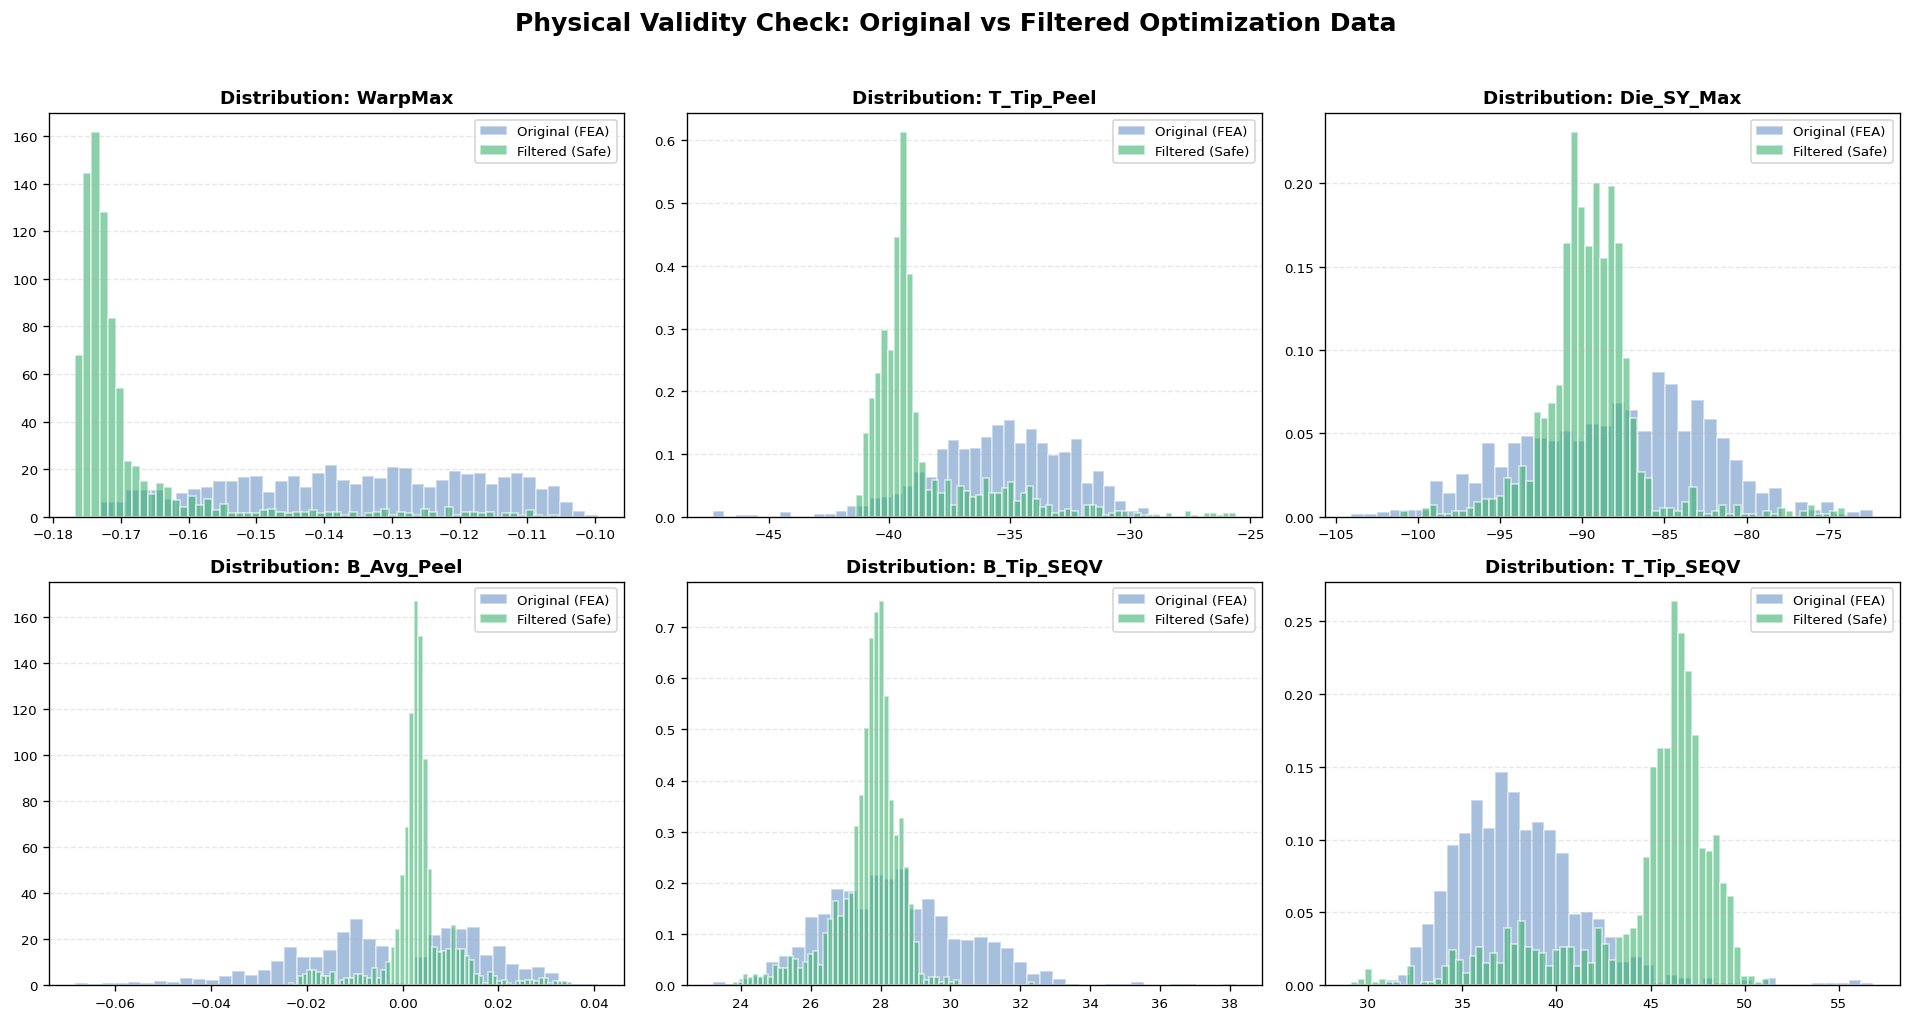

--- [분포 비교 결과 가이드] ---
1. 데이터 중첩도: 두 분포가 상당 부분 겹친다면 AI 대리 모델의 예측력이 물리적으로 타당함을 의미합니다.
2. 필터링 효과: 원본에 비해 Filtered 분포의 꼬리(Tail) 부분이 잘려나갔다면 Gatekeeper가 위험 설계안을 잘 제거한 것입니다.


In [43]:
# ====================================================================
# [6. 원본 데이터(df_peaks) 즉석 추출 로직 - 성능 최적화판]
# ====================================================================
valid_data = []
error_rows = []

t_start = time.time()
print(f'\n{len(survived_ids)}개 생존 CSV에서 물리량(Max Peak) 추출 시작...')

for row_id in survived_ids:
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    try:
        # 1. 시계열 데이터 로드 및 컬럼 정리
        df_ts = pd.read_csv(fpath)
        df_ts.columns = df_ts.columns.str.strip()
        
        # 2. 기본 정보 및 설계 변수(P1~P6) 매핑
        # [주의] df_master 인덱스와 row_id 정합성 유지
        idx = row_id - 1 
        peak_dict = {'Row_ID': row_id}
        for p_col in p_cols: # ['P1'...'P6']
            peak_dict[p_col] = df_master.loc[idx, p_col]
        
        # 3. 절댓값 최대 피크 추출 (부호 유지)
        # 물리적 거동의 극값을 정확히 포착하기 위한 방식입니다.
        for y_col in Y_COLUMNS:
            if y_col in df_ts.columns:
                max_abs_val = df_ts[y_col].loc[df_ts[y_col].abs().idxmax()]
                peak_dict[y_col] = max_abs_val
            else:
                peak_dict[y_col] = np.nan
        
        valid_data.append(peak_dict)
        
    except Exception as e:
        error_rows.append((row_id, str(e)))

# 결과 데이터프레임 생성 및 정제
df_peaks = pd.DataFrame(valid_data)
if not df_peaks.empty:
    df_peaks = df_peaks.dropna(subset=check_cols).reset_index(drop=True)

elapsed = time.time() - t_start
print(f'=== 추출 완료 (성공: {len(df_peaks)} / 소요시간: {elapsed:.1f}초) ===')

# ====================================================================
# [7. 원본 vs 필터링된 증강 데이터 분포 시각화 (스타일 개선)]
# ====================================================================
# 데이터 로드
df_augmented_filtered = pd.read_csv('Augmented_Class_Data.csv')

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Physical Validity Check: Original vs Filtered Optimization Data', 
             fontsize=15, fontweight='bold', y=0.97)

for idx, y_col in enumerate(check_cols):
    ax = axes[idx // 3, idx % 3]
    
    # 1. 원본 데이터 (파란색)
    ax.hist(df_peaks[y_col], bins=40, density=True, alpha=0.5,
            color='#4F81BD', edgecolor='white', label='Original (FEA)')
    
    # 2. Gatekeeper를 통과한 필터링 데이터 (녹색 - 신뢰의 색상)
    # 이 분포가 원본과 유사하거나 합리적인 방향으로 이동했다면 AI 모델이 물리 법칙을 잘 따르고 있는 것입니다.
    ax.hist(df_augmented_filtered[y_col], bins=60, density=True, alpha=0.6,
            color='mediumseagreen', edgecolor='white', label='Filtered (Safe)')
    
    ax.set_title(f'Distribution: {y_col}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8, frameon=True, facecolor='white')
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(labelsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print('--- [분포 비교 결과 가이드] ---')
print('1. 데이터 중첩도: 두 분포가 상당 부분 겹친다면 AI 대리 모델의 예측력이 물리적으로 타당함을 의미합니다.')
print('2. 필터링 효과: 원본에 비해 Filtered 분포의 꼬리(Tail) 부분이 잘려나갔다면 Gatekeeper가 위험 설계안을 잘 제거한 것입니다.')

# [Step 3] 파레토 프론티어(Pareto Frontier) 타겟 곡선 추출

## 목표
역설계 AI(Step 4)에 입력할 **'물리적으로 도달 가능하면서도 이상적인 타겟 시계열 텐서'**를 생성한다.

## 파레토 비지배 정렬 (Non-dominated Sorting)
원본 생존 데이터(~900개)에서 **WarpMax**와 **T_Tip_Peel** 단 2개 변수의 절댓값을 기준으로
파레토 최적 DP(Frontier 0)를 선별한다.
```
판정 기준: 두 목적함수 모두 최소화
  - obj1 = |WarpMax|   → 패키지 휨 최소화
  - obj2 = |T_Tip_Peel| → 계면 박리 응력 최소화

비지배 조건:
  DP_j가 DP_i를 "지배"한다 = j가 모든 목적에서 i 이하이고, 최소 하나에서 엄격히 작다
  → 아무에게도 지배당하지 않는 DP만 파레토 Frontier 0으로 선정
```

## 핵심 채널 선정 (7채널)
GPR ARD 커널의 학습 결과(R² 기준)로 확정된 **신뢰 가능한 7개 채널**만 사용한다.
R²가 낮은 변수(T_Tip_Shear, T_Avg_Peel 등)는 예측 신뢰도가 부족하여 제외.
```
채널                GPR Test R²    역할
─────────────────────────────────────────────
WarpMax             0.999          최소화 메인 타겟 #1
T_Tip_Peel          0.773          최소화 메인 타겟 #2
Die_SY_Max          0.900          다이 모서리 응력 (Hard Constraint)
B_Avg_Peel          0.844          Bottom 평균 박리 (Hard Constraint)
B_Tip_SEQV          0.829          Bottom 끝단 등가응력 (Hard Constraint)
T_Tip_Strain        0.798          Top 끝단 변형률 (Hard Constraint)
T_Tip_SEQV          0.588          Top 끝단 등가응력 (경계선, 주의 필요)
```

## 유토피아 타겟 텐서 생성
```
파레토 Frontier 0 DP 선별
    ↓ 해당 Row_ID의 원본 시계열 CSV 호출 (617 timestep × 17열)
    ↓ 7대 핵심 채널만 추출
    ↓ 전 채널에 동일 스칼라(×0.9) 곱셈 → 진폭 10% 하향
    ↓ 물리적 위상차·파형 형태 100% 보존
Utopia_Target_Row_{Row_ID}.csv 저장 → Step 4로 전달
```

### ×0.9 스케일링의 물리적 의미
- 현재 파레토 1등의 곡선 형태(가열-유지-냉각 위상)는 그대로 유지
- 진폭만 10% 낮춰 **"현실에 가깝지만 약간 더 나은"** 유토피아 목표 설정
- 비현실적으로 낮은 목표(×0.5 등)는 AI가 물리적으로 불가능한 설계를 출력할 위험

## 출력
- `Utopia_Target_Tensors/Utopia_Target_Row_{ID}.csv`: 파레토 DP별 7채널 × 617 timestep
- 용도: Step 4 역설계 모델(1D-CNN)의 입력 텐서

In [44]:
# ====================================================================
# [1. 환경 및 타겟 설정]
# ====================================================================
CORE_7_CHANNELS = [
    'WarpMax', 'Die_SY_Max', 'B_Avg_Peel', 'B_Tip_SEQV', 
    'T_Tip_Strain', 'T_Tip_Peel', 'T_Tip_SEQV'
]

UTOPIA_RATIO = 0.90 
TENSOR_DIR = os.path.join(BASE_DIR, 'Utopia_Target_Tensors')  # 절대 경로 통일
os.makedirs(TENSOR_DIR, exist_ok=True)

print("=== [Step 3] 파레토 비지배 정렬 및 유토피아 타겟 추출 ===")

# ====================================================================
# [2. 다단계 Pareto Non-dominated Sorting (Frontier 0 + 1 + ...)]
# ====================================================================
obj1 = df_peaks['WarpMax'].abs().values
obj2 = df_peaks['T_Tip_Peel'].abs().values
scores = np.column_stack((obj1, obj2))

population_size = scores.shape[0]

# 다단계 비지배 정렬: Frontier 0, 1, 2, ... 순서로 계층 분류
# Frontier 0 = 최상위 (아무에게도 지배 안 당함)
# Frontier 1 = Frontier 0 제거 후 비지배 해
# ...반복
frontier_labels = np.full(population_size, -1, dtype=int)  # 각 DP의 Frontier 등급
remaining = np.ones(population_size, dtype=bool)             # 아직 분류 안 된 DP
frontier_level = 0

while remaining.any():
    remaining_idx = np.where(remaining)[0]
    current_scores = scores[remaining_idx]
    is_pareto = np.ones(len(remaining_idx), dtype=bool)
    
    for i in range(len(remaining_idx)):
        for j in range(len(remaining_idx)):
            if i == j:
                continue
            # j가 i를 지배하는지 판정
            if all(current_scores[j] <= current_scores[i]) and any(current_scores[j] < current_scores[i]):
                is_pareto[i] = False
                break
    
    # 현재 Frontier에 해당하는 DP에 등급 부여
    for k, idx in enumerate(remaining_idx):
        if is_pareto[k]:
            frontier_labels[idx] = frontier_level
            remaining[idx] = False
    
    print(f'  Frontier {frontier_level}: {is_pareto.sum()}개')
    frontier_level += 1
    
    # 안전 장치: 최대 10단계까지만
    if frontier_level >= 10:
        break

# Frontier 등급을 df_peaks에 추가
df_peaks['frontier'] = frontier_labels

# === 파레토 상위 N% 또는 최소 수량 확보 ===
MIN_PARETO_COUNT = 30  # 최소 확보 목표 (Step 4 학습에 필요한 하한)

# Frontier 0부터 순서대로 누적하여 최소 수량 충족될 때까지 확장
selected_frontiers = []
cumulative = 0
for level in range(frontier_level):
    count_at_level = (frontier_labels == level).sum()
    selected_frontiers.append(level)
    cumulative += count_at_level
    if cumulative >= MIN_PARETO_COUNT:
        break

df_pareto = df_peaks[df_peaks['frontier'].isin(selected_frontiers)].copy()
num_pareto = len(df_pareto)
max_frontier = max(selected_frontiers)

print(f'\n총 {population_size}개 중 파레토 Frontier 0~{max_frontier}: {num_pareto}개 ({num_pareto/population_size*100:.1f}%)')
print(f'  (Frontier 0만: {(frontier_labels==0).sum()}개 → 부족하여 Frontier {max_frontier}까지 확장)')

if num_pareto < MIN_PARETO_COUNT:
    print(f'[경고] {num_pareto}개로 목표({MIN_PARETO_COUNT})에 미달. 가용 데이터 전부 사용.')

=== [Step 3] 파레토 비지배 정렬 및 유토피아 타겟 추출 ===
  Frontier 0: 8개
  Frontier 1: 8개
  Frontier 2: 12개
  Frontier 3: 12개
  Frontier 4: 16개
  Frontier 5: 18개
  Frontier 6: 20개
  Frontier 7: 23개
  Frontier 8: 20개
  Frontier 9: 35개

총 884개 중 파레토 Frontier 0~3: 40개 (4.5%)
  (Frontier 0만: 8개 → 부족하여 Frontier 3까지 확장)


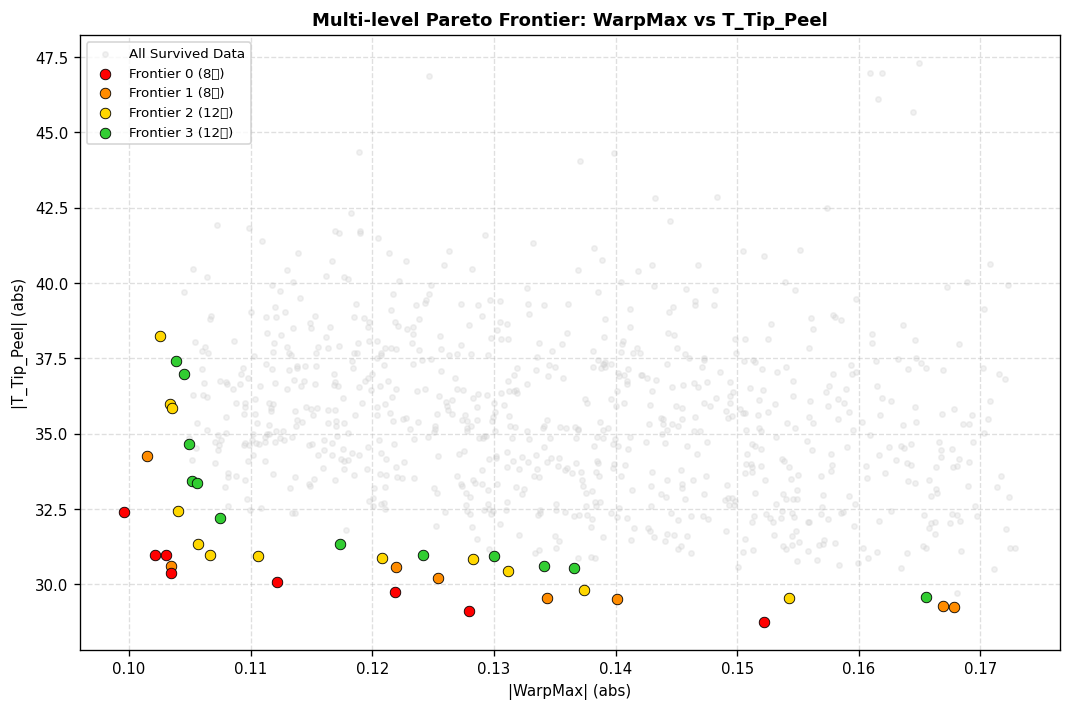

→ 빨간색(Frontier 0)에 가까울수록 WarpMax와 T_Tip_Peel이 동시에 작은 우수 설계
→ 총 40개의 유토피아 타겟 텐서가 Step 4로 전달됨


In [45]:
# ====================================================================
# [3. 다단계 파레토 프론티어 시각화]
# ====================================================================
plt.figure(figsize=(9, 6))

# 전체 데이터 (회색 배경)
plt.scatter(obj1, obj2, color='lightgray', alpha=0.3, s=10, label='All Survived Data')

# Frontier 등급별 색상 구분
colors = ['red', 'darkorange', 'gold', 'limegreen', 'deepskyblue']
for level in selected_frontiers:
    mask = frontier_labels == level
    n = mask.sum()
    c = colors[level] if level < len(colors) else 'gray'
    plt.scatter(obj1[mask], obj2[mask], color=c, s=40, edgecolors='black',
                linewidths=0.5, label=f'Frontier {level} ({n}개)', zorder=5-level)

plt.title('Multi-level Pareto Frontier: WarpMax vs T_Tip_Peel', fontweight='bold')
plt.xlabel('|WarpMax| (abs)')
plt.ylabel('|T_Tip_Peel| (abs)')
plt.legend(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f'→ 빨간색(Frontier 0)에 가까울수록 WarpMax와 T_Tip_Peel이 동시에 작은 우수 설계')
print(f'→ 총 {num_pareto}개의 유토피아 타겟 텐서가 Step 4로 전달됨')

In [46]:
# ====================================================================
# [4. 시계열 원본 호출 및 7채널 유토피아 텐서 변환/저장]
# ====================================================================
print(f"\n파레토 상위 데이터({num_pareto}개)의 시계열 원본을 7채널 유토피아 텐서로 변환합니다...")

# Step 4에서 사용하는 공통 시간축과 동일하게 리샘플링
TARGET_LEN = 600
t_common = np.linspace(0, 300, TARGET_LEN)

utopia_files = []

for idx, row in df_pareto.iterrows():
    row_id = int(row['Row_ID'])
    csv_path = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    try:
        df_ts = pd.read_csv(csv_path)
        df_ts.columns = [c.strip() for c in df_ts.columns]
        
        # 원본 시간축
        t_original = df_ts['Time'].values
        
        # 7채널을 공통 시간축(600포인트)으로 선형 보간
        ts_resampled = {}
        for col in CORE_7_CHANNELS:
            ts_resampled[col] = np.interp(t_common, t_original, df_ts[col].values)
        
        df_7ch = pd.DataFrame(ts_resampled)
        
        # 유토피아 스케일링: 진폭을 10% 깎음 (위상차·파형 100% 보존)
        df_utopia = df_7ch * UTOPIA_RATIO
        
        # 저장
        save_name = f'Utopia_Target_Row_{row_id}.csv'
        save_path = os.path.join(TENSOR_DIR, save_name)
        df_utopia.to_csv(save_path, index=False)
        utopia_files.append(save_name)
        
    except Exception as e:
        print(f"[오류] Row_ID {row_id}: {e}")

print(f"\n유토피아 타겟 텐서 생성 완료! ({len(utopia_files)}개 저장)")
print(f"저장 폴더: {TENSOR_DIR}")
print(f"각 파일: {TARGET_LEN} timestep × {len(CORE_7_CHANNELS)} channels (리샘플링 + ×{UTOPIA_RATIO})")
print("→ [Step 4: 오토인코더 역설계]의 입력 텐서로 사용됩니다.")


파레토 상위 데이터(40개)의 시계열 원본을 7채널 유토피아 텐서로 변환합니다...

유토피아 타겟 텐서 생성 완료! (40개 저장)
저장 폴더: C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS\Utopia_Target_Tensors
각 파일: 600 timestep × 7 channels (리샘플링 + ×0.9)
→ [Step 4: 오토인코더 역설계]의 입력 텐서로 사용됩니다.


================================================================================
# [Step 4] 딥러닝 기반 역설계 — 오토인코더 잠재 매핑 (Autoencoder Latent Mapping)
================================================================================

## 목표
Step 3에서 생성된 유토피아 타겟 텐서(7채널 × 617 timestep)를 입력하면,
이를 구현할 수 있는 **최적의 P1~P6 설계변수 초안**을 출력한다.

## 전략: 2단계 잠재 공간 매핑
고차원 시계열(617×7 = 4,319차원)을 직접 역매핑하면 일대다(one-to-many) 문제로
수렴이 불안정하다. 대신 오토인코더로 **잠재 공간(32차원)**에 압축한 뒤,
저차원에서 P↔z 매핑을 학습하여 안정적인 역설계를 수행한다.

## 파이프라인 흐름

    [Step 4-1] 시계열 오토인코더 학습 (비지도, 원본 ~900개 전부 사용)
        입력: 원본 시계열 (617 × 7ch)
          ↓ Encoder (1D-CNN): 시계열 → 잠재 벡터 z (32차원)
          ↓ Decoder (1D-ConvTranspose): z → 시계열 복원
          ↓ 복원 오차(MSE) 최소화
        결과: Encoder/Decoder 확보

    [Step 4-2] 잠재 공간 매핑 학습 (지도, ~900개)
        순방향: P1~P6 → z  (MLP)
        역방향: z → P1~P6  (MLP)

    [Step 4-3] 유토피아 타겟 역설계 (추론)
        유토피아 텐서 → Encoder → z_target → 역매핑 MLP → P1~P6 초안
        → Step 5 GA 미세조정의 시작점(±10%)으로 전달

## 출력
    - P1~P6 초안 (파레토 DP별)
    - Inverse_Design_Results.csv → Step 5로 전달

In [48]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ====================================================================
# [Step 4-1. 역설계용 Utopia Target 로드 및 전처리]
# ====================================================================
# [참고] Utopia Target은 우리가 도달하고자 하는 최적의 시계열 텐서입니다.
# Step 3에서 저장된 텐서 파일들을 로드할 준비를 합니다.

print(f'\n>>> Utopia Target 텐서 스캔 중: {TENSOR_DIR}')

if not os.path.exists(TENSOR_DIR):
    os.makedirs(TENSOR_DIR)
    print(f'[알림] 텐서 폴더가 없어 생성되었습니다. 타겟 텐서를 해당 경로에 배치하세요.')

CORE_7_CHANNELS = [
    'WarpMax', 'Die_SY_Max', 'B_Avg_Peel', 'B_Tip_SEQV',
    'T_Tip_Strain', 'T_Tip_Peel', 'T_Tip_SEQV'
]    

N_CHANNELS = len(CORE_7_CHANNELS)

# 텐서 데이터 로더 구성을 위한 설정
BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 200

# [Tip] Inverse Design을 위해서는 (Target 시계열 -> 설계변수 P) 매핑 모델이 필요합니다.
# 사용자님의 1D-CNN Direct Regression 모델 또는 CAE 구조가 여기에 연결될 것입니다.

print(f'\n--- 역설계 모델 학습 파라미터 ---')
print(f' - Batch Size   : {BATCH_SIZE}')
print(f' - Learning Rate: {LEARNING_RATE}')
print(f' - Max Epochs   : {EPOCHS}')
print(f' - N_Channels   : {N_CHANNELS} (물리 채널 수)')
print(f' - Input Shape  : (Batch, {N_CHANNELS}, Time_Steps)')
print('='*50)

# ====================================================================
# [Next Step 아이디어]
# ====================================================================
# 1. 1D-CNN Encoder를 활용하여 7개 채널의 시계열 특징을 32차원 잠재 벡터로 압축
# 2. 이 잠재 벡터에서 설계 변수 P1~P6를 추정하는 Regressor 연결
# 3. Utopia Target을 입력했을 때 출력되는 P1~P6가 최종 'AI 추천 레시피'가 됩니다.


>>> Utopia Target 텐서 스캔 중: C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS\Utopia_Target_Tensors

--- 역설계 모델 학습 파라미터 ---
 - Batch Size   : 64
 - Learning Rate: 0.001
 - Max Epochs   : 200
 - N_Channels   : 7 (물리 채널 수)
 - Input Shape  : (Batch, 7, Time_Steps)


In [52]:
# ====================================================================
# [1. 원본 시계열 데이터 로드 (학습용) - 방어 코드 강화판]
# ====================================================================
print('\n[1] 원본 시계열 로드 및 텐서 변환 시작...')

all_timeseries = []   
all_params = []       
valid_row_ids = []

# 리샘플링 설정
TARGET_LEN = 600  
t_common = np.linspace(0, 300, TARGET_LEN)

# 데이터 수집 루프
for row_id in survived_ids:
    fpath = os.path.join(CSV_FOLDER, f'ML_DATA_Extract_Row_{row_id}.csv')
    
    # 해당 Row_ID가 df_master에 있는지 확인
    master_row = df_master[df_master['Row_ID'] == row_id]
    if master_row.empty:
        continue

    if not os.path.exists(fpath):
        continue

    try:
        df_ts = pd.read_csv(fpath)
        df_ts.columns = [c.strip() for c in df_ts.columns]

        # 7개 핵심 채널이 모두 있는지 확인
        if not all(col in df_ts.columns for col in CORE_7_CHANNELS):
            continue

        t_original = df_ts['Time'].values
        ts_resampled = np.zeros((TARGET_LEN, N_CHANNELS))
        
        for ch, col in enumerate(CORE_7_CHANNELS):
            ts_resampled[:, ch] = np.interp(t_common, t_original, df_ts[col].values)

        if np.isnan(ts_resampled).any() or np.isinf(ts_resampled).any():
            continue

        all_timeseries.append(ts_resampled)
        all_params.append(master_row[['P1','P2','P3','P4','P5','P6']].values[0])
        valid_row_ids.append(row_id)

    except Exception:
        continue

# --- 핵심: 여기서 X_ts를 안전하게 생성 ---
if len(all_timeseries) > 0:
    X_ts = np.array(all_timeseries, dtype=np.float32)   # (N, 600, 7)
    X_params = np.array(all_params, dtype=np.float32)    # (N, 6)
    N_SAMPLES = X_ts.shape[0]
    print(f'✅ 로드 완료: {N_SAMPLES}개 샘플 확보')
else:
    X_ts = np.empty((0, TARGET_LEN, N_CHANNELS)) # 빈 배열이라도 생성하여 NameError 방지
    X_params = np.empty((0, 6))
    print('❌ 로드 실패: 조건에 맞는 CSV 파일이 없습니다. 경로와 CORE_7_CHANNELS를 확인하세요.')

# 데이터 확인
if 'X_ts' in locals() and len(X_ts) > 0:
    print(f'시계열 Shape: {X_ts.shape}')
    print(f'설계변수 Shape: {X_params.shape}')


[1] 원본 시계열 로드 및 텐서 변환 시작...
✅ 로드 완료: 884개 샘플 확보
시계열 Shape: (884, 600, 7)
설계변수 Shape: (884, 6)


In [55]:
# ====================================================================
# [2. 데이터 전처리 (채널별 StandardScaler)] - 호환성 수정판
# ====================================================================
# 오토인코더 학습 전 각 채널을 독립적으로 정규화
# 이전 단계에서 확정된 TARGET_LEN(600) 및 N_CHANNELS(7)와 동기화

print('\n[2] 채널별 StandardScaler 적용...')

# 1. X_ts 존재 여부 확인 (호환성 방어)
if 'X_ts' not in locals() or len(X_ts) == 0:
    raise NameError("X_ts 데이터가 없습니다. [1]번 데이터 로드 섹션을 먼저 실행해주세요.")

# 채널별 scaler 저장 (추론 시 역변환 및 Utopia Target 변환에 필수)
channel_scalers = []
X_ts_scaled = np.zeros_like(X_ts)

# 실제 시계열 길이(TARGET_LEN) 자동 감지
current_target_len = X_ts.shape[1] 

for ch in range(N_CHANNELS):
    scaler = StandardScaler()
    # (N, T) 형태의 채널 데이터를 스케일러가 인식하도록 2D로 일시 변환
    # 모든 타임스텝의 값을 하나의 분포로 보고 정규화하기 위해 flatten 후 다시 reshape
    ch_data_flat = X_ts[:, :, ch].reshape(-1, 1)
    scaler.fit(ch_data_flat)
    
    # 변환 적용
    X_ts_scaled[:, :, ch] = scaler.transform(X_ts[:, :, ch].reshape(-1, 1)).reshape(-1, current_target_len)
    channel_scalers.append(scaler)
    
    # 핵심 통계량 출력 (정상 범위 확인용)
    print(f'  {CORE_7_CHANNELS[ch]:15s} | mean={scaler.mean_[0]:.4e}, std={scaler.scale_[0]:.4e}')

# 2. P1~P6 정규화 (역설계 매핑 학습 시 필수)
param_scaler = StandardScaler()
X_params_scaled = param_scaler.fit_transform(X_params)

# 3. PyTorch 텐서로 변환
# Conv1d 규격: (batch, channels, length) 
# X_ts_scaled: (N, 600, 7) -> permute(0, 2, 1) -> (N, 7, 600)
X_tensor = torch.FloatTensor(X_ts_scaled).permute(0, 2, 1) 
P_tensor = torch.FloatTensor(X_params_scaled)

print(f'\n✅ PyTorch 텐서 변환 완료')
print(f' - X_tensor (시계열) shape: {X_tensor.shape}')
print(f' - P_tensor (설계변수) shape: {P_tensor.shape}')
print(f' - 사용된 타임스텝 길이: {current_target_len}')


[2] 채널별 StandardScaler 적용...
  WarpMax         | mean=-8.1797e-02, std=1.7475e-02
  Die_SY_Max      | mean=1.0158e+01, std=2.7983e+01
  B_Avg_Peel      | mean=-2.1059e-03, std=1.0042e-02
  B_Tip_SEQV      | mean=1.0873e+01, std=7.5159e+00
  T_Tip_Strain    | mean=2.5174e-03, std=7.9507e-04
  T_Tip_Peel      | mean=6.6679e+00, std=1.7970e+01
  T_Tip_SEQV      | mean=2.4257e+01, std=5.7299e+00

✅ PyTorch 텐서 변환 완료
 - X_tensor (시계열) shape: torch.Size([884, 7, 600])
 - P_tensor (설계변수) shape: torch.Size([884, 6])
 - 사용된 타임스텝 길이: 600


In [59]:
# ====================================================================
# [3. 오토인코더 모델 정의 및 선언]
# ====================================================================
# 이전 단계에서 생성된 텐서로부터 차원 정보 자동 추출 (에러 방지)
if 'X_tensor' in locals():
    N_CHANNELS = X_tensor.shape[1]    # 7
    N_TIMESTEPS = X_tensor.shape[2]   # 600
else:
    # 만약 위 섹션을 실행하지 않았다면 기본값 설정
    N_CHANNELS = 7
    N_TIMESTEPS = 600

# Step 4 상단에서 정의한 LATENT_DIM 확인
if 'LATENT_DIM' not in locals():
    LATENT_DIM = 32

# --- [Encoder/Decoder 클래스 정의 부분은 사용자님 코드와 동일하므로 생략 가능하나, 
#      전체 실행을 위해 아래에 모델 인스턴스화 코드를 정리합니다] ---

print(f'\n[3] 오토인코더 모델 구성 시작...')
print(f' - 입력 채널: {N_CHANNELS}')
print(f' - 시계열 길이: {N_TIMESTEPS}')
print(f' - 잠재 차원(Latent): {LATENT_DIM}')

# 모델 인스턴스 생성 및 디바이스 이동
ae_model = TimeSeriesAutoencoder(n_channels=N_CHANNELS, latent_dim=LATENT_DIM).to(device)

# 파라미터 수 계산 및 구조 출력
total_params = sum(p.numel() for p in ae_model.parameters())
print(f'\n✅ 모델 생성 완료')
print(f' - 총 파라미터: {total_params:,}개')
print(f' - 구조: Encoder({N_CHANNELS}ch) -> Latent({LATENT_DIM}) -> Decoder({N_CHANNELS}ch)')
print(f' - 특이사항: Upsample + Conv1d 기반 물리 거동 스무딩 적용')


[3] 오토인코더 모델 구성 시작...
 - 입력 채널: 7
 - 시계열 길이: 600
 - 잠재 차원(Latent): 32

✅ 모델 생성 완료
 - 총 파라미터: 427,431개
 - 구조: Encoder(7ch) -> Latent(32) -> Decoder(7ch)
 - 특이사항: Upsample + Conv1d 기반 물리 거동 스무딩 적용


In [60]:
# ====================================================================
# [3. 오토인코더 모델 정의]
# ====================================================================
# Encoder: 1D-CNN으로 시계열을 잠재 벡터로 압축
# Decoder: Upsample + Conv1d로 복원 (ConvTranspose의 체커보드 아티팩트 해소)

class Encoder(nn.Module):
    """
    1D-CNN Encoder: (batch, 7, 600) → (batch, 32)
    3단계 Conv Block으로 시간축을 점진적으로 압축
    """
    def __init__(self, n_channels=7, latent_dim=32):
        super().__init__()
        self.conv_blocks = nn.Sequential(
            # Block 1: (7, 600) → (32, 300)
            nn.Conv1d(n_channels, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),

            # Block 2: (32, 300) → (64, 150)
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),

            # Block 3: (64, 150) → (128, 75)
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)  # (128, 75) → (128, 1)
        self.fc = nn.Linear(128, latent_dim)

    def forward(self, x):
        h = self.conv_blocks(x)
        h = self.global_pool(h)
        h = h.squeeze(-1)
        z = self.fc(h)
        return z


class Decoder(nn.Module):
    """
    Upsample + Conv1d Decoder: (batch, 32) → (batch, 7, 600)
    
    ConvTranspose 대신 Upsample(nearest) + Conv1d 조합 사용
    → 체커보드 아티팩트(고주파 노이즈 진동) 제거
    → 물리적으로 매끄러운 시계열 복원
    """
    def __init__(self, n_channels=7, latent_dim=32):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 128 * 75)

        # Upsample + Conv1d 블록 (ConvTranspose 대체)
        # 각 블록: nearest 보간으로 2배 확장 → Conv1d로 스무딩
        self.up_blocks = nn.Sequential(
            # Block 1: (128, 75) → upsample → (128, 150) → conv → (64, 150)
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv1d(128, 64, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),

            # Block 2: (64, 150) → upsample → (64, 300) → conv → (32, 300)
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv1d(64, 32, kernel_size=5, stride=1, padding=2),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),

            # Block 3: (32, 300) → upsample → (32, 600) → conv → (7, 600)
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv1d(32, n_channels, kernel_size=7, stride=1, padding=3),
        )

    def forward(self, z):
        h = self.fc(z)
        h = h.view(-1, 128, 75)
        h = self.up_blocks(h)
        # 최종 길이 보정 (Upsample 결과가 정확히 600이 아닐 경우 대비)
        h = torch.nn.functional.interpolate(h, size=600, mode='linear', align_corners=False)
        return h


class TimeSeriesAutoencoder(nn.Module):
    """
    시계열 오토인코더 = Encoder + Decoder
    """
    def __init__(self, n_channels=7, latent_dim=32):
        super().__init__()
        self.encoder = Encoder(n_channels, latent_dim)
        self.decoder = Decoder(n_channels, latent_dim)

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z


print('[3] 오토인코더 모델 구조 (Upsample + Conv1d Decoder):')
ae_model = TimeSeriesAutoencoder(N_CHANNELS, LATENT_DIM).to(device)
total_params = sum(p.numel() for p in ae_model.parameters())
print(f'  총 파라미터: {total_params:,}개')
print(f'  Encoder: (batch, {N_CHANNELS}, {N_TIMESTEPS}) → (batch, {LATENT_DIM})')
print(f'  Decoder: (batch, {LATENT_DIM}) → (batch, {N_CHANNELS}, {N_TIMESTEPS})')
print(f'  Decoder 방식: Upsample(nearest) + Conv1d (체커보드 아티팩트 제거)')

[3] 오토인코더 모델 구조 (Upsample + Conv1d Decoder):
  총 파라미터: 427,431개
  Encoder: (batch, 7, 600) → (batch, 32)
  Decoder: (batch, 32) → (batch, 7, 600)
  Decoder 방식: Upsample(nearest) + Conv1d (체커보드 아티팩트 제거)


In [61]:
# ====================================================================
# [4. 오토인코더 학습 (비지도)]
# ====================================================================
# 원본 ~900개 시계열의 복원 오차(MSE)를 최소화
# 라벨(P1~P6)이 필요 없으므로 전체 데이터를 비지도로 학습

AE_EPOCHS     = 200       # 에포크 수
AE_BATCH_SIZE = 32        # 배치 크기
AE_LR         = 1e-3      # 학습률
AE_PATIENCE   = 20        # Early Stopping 인내심

print(f'\n[4] 오토인코더 학습 시작 (epochs={AE_EPOCHS}, batch={AE_BATCH_SIZE}, lr={AE_LR})')

# Train/Val 분리 (85:15)
n_train = int(N_SAMPLES * 0.85)
indices = np.random.permutation(N_SAMPLES)
train_idx, val_idx = indices[:n_train], indices[n_train:]

train_loader = DataLoader(
    TensorDataset(X_tensor[train_idx]),
    batch_size=AE_BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(X_tensor[val_idx]),
    batch_size=AE_BATCH_SIZE, shuffle=False
)

# 옵티마이저 및 스케줄러
optimizer_ae = optim.Adam(ae_model.parameters(), lr=AE_LR, weight_decay=1e-5)
scheduler_ae = optim.lr_scheduler.ReduceLROnPlateau(optimizer_ae, patience=10, factor=0.5)
criterion_ae = nn.MSELoss()

# 학습 루프
train_losses = []
val_losses = []
best_val_loss = float('inf')
patience_counter = 0

t_start = time.time()

for epoch in range(AE_EPOCHS):
    # -- Train --
    ae_model.train()
    epoch_train_loss = 0
    for (batch_x,) in train_loader:
        batch_x = batch_x.to(device)
        x_recon, z = ae_model(batch_x)
        loss = criterion_ae(x_recon, batch_x)
        optimizer_ae.zero_grad()
        loss.backward()
        optimizer_ae.step()
        epoch_train_loss += loss.item() * len(batch_x)
    epoch_train_loss /= n_train

    # -- Validation --
    ae_model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for (batch_x,) in val_loader:
            batch_x = batch_x.to(device)
            x_recon, z = ae_model(batch_x)
            loss = criterion_ae(x_recon, batch_x)
            epoch_val_loss += loss.item() * len(batch_x)
    epoch_val_loss /= (N_SAMPLES - n_train)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    scheduler_ae.step(epoch_val_loss)

    # Early Stopping 체크
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        patience_counter = 0
        # 베스트 모델 저장
        best_ae_state = ae_model.state_dict().copy()
    else:
        patience_counter += 1

    # 진행 출력 (20에포크마다)
    if (epoch + 1) % 20 == 0:
        lr_now = optimizer_ae.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:3d}/{AE_EPOCHS} | '
              f'Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f} | '
              f'LR: {lr_now:.2e} | Patience: {patience_counter}/{AE_PATIENCE}')

    if patience_counter >= AE_PATIENCE:
        print(f'  → Early Stopping at epoch {epoch+1}')
        break

# 베스트 모델 복원
ae_model.load_state_dict(best_ae_state)
elapsed = time.time() - t_start
print(f'\n오토인코더 학습 완료 ({elapsed:.1f}초)')
print(f'최종 Val Loss: {best_val_loss:.6f}')


[4] 오토인코더 학습 시작 (epochs=200, batch=32, lr=0.001)
  Epoch  20/200 | Train Loss: 0.021252 | Val Loss: 0.015879 | LR: 1.00e-03 | Patience: 2/20
  Epoch  40/200 | Train Loss: 0.018568 | Val Loss: 0.014827 | LR: 1.00e-03 | Patience: 5/20
  Epoch  60/200 | Train Loss: 0.019627 | Val Loss: 0.010704 | LR: 1.00e-03 | Patience: 10/20
  Epoch  80/200 | Train Loss: 0.013254 | Val Loss: 0.009571 | LR: 2.50e-04 | Patience: 11/20
  Epoch 100/200 | Train Loss: 0.011540 | Val Loss: 0.007619 | LR: 2.50e-04 | Patience: 7/20
  Epoch 120/200 | Train Loss: 0.010417 | Val Loss: 0.007384 | LR: 2.50e-04 | Patience: 8/20
  Epoch 140/200 | Train Loss: 0.009145 | Val Loss: 0.006950 | LR: 6.25e-05 | Patience: 0/20
  Epoch 160/200 | Train Loss: 0.008147 | Val Loss: 0.006906 | LR: 3.13e-05 | Patience: 3/20
  Epoch 180/200 | Train Loss: 0.008631 | Val Loss: 0.006888 | LR: 1.56e-05 | Patience: 1/20
  Epoch 200/200 | Train Loss: 0.009003 | Val Loss: 0.006978 | LR: 7.81e-06 | Patience: 2/20

오토인코더 학습 완료 (129.3초)
최종 Val

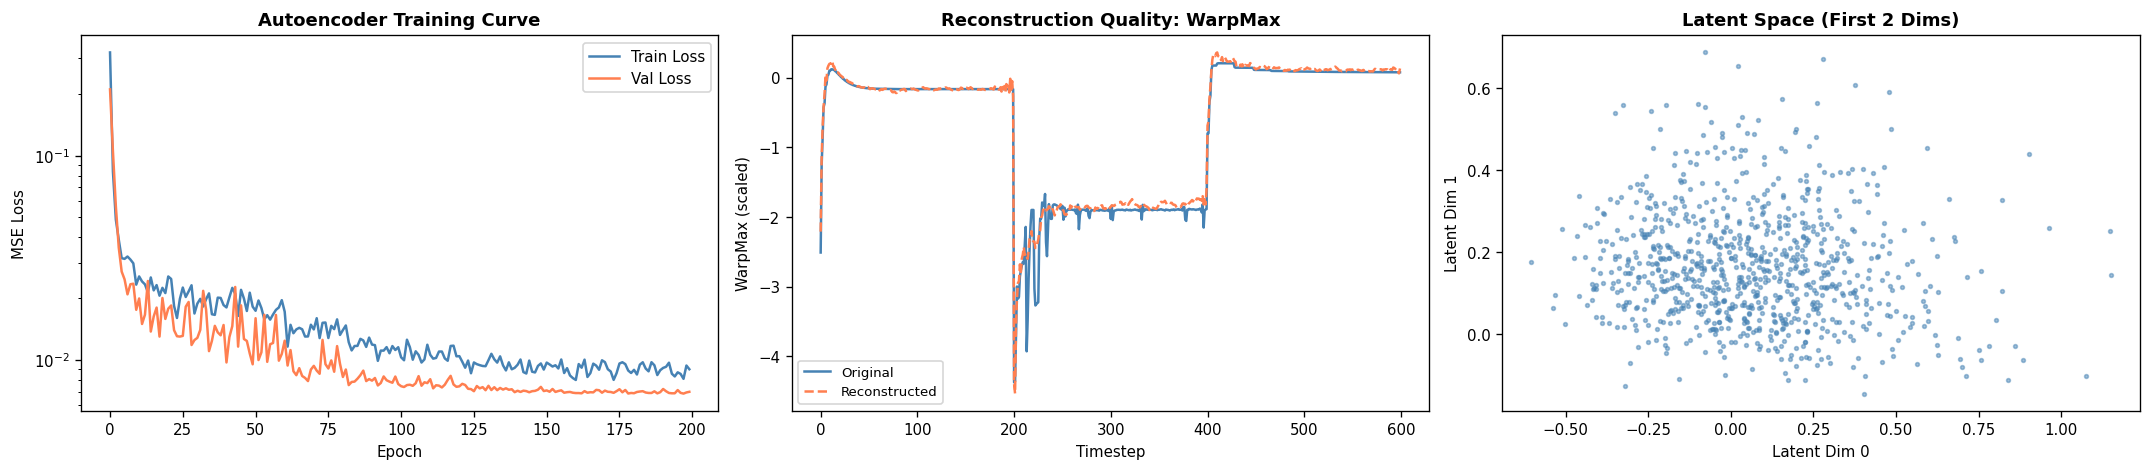

In [70]:
# ====================================================================
# [5. 오토인코더 학습 결과 시각화]
# ====================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# --- (A) 학습 곡선 ---
ax = axes[0]
ax.plot(train_losses, label='Train Loss', color='steelblue')
ax.plot(val_losses, label='Val Loss', color='coral')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Autoencoder Training Curve', fontweight='bold')
ax.legend()
ax.set_yscale('log')

# --- (B) 복원 품질 예시 (첫 번째 검증 샘플의 WarpMax 채널) ---
ax = axes[1]
ae_model.eval()
with torch.no_grad():
    sample_x = X_tensor[val_idx[0]:val_idx[0]+1].to(device)
    sample_recon, _ = ae_model(sample_x)
    sample_x_np = sample_x.cpu().numpy()[0]           # (7, 617)
    sample_recon_np = sample_recon.cpu().numpy()[0]    # (7, 617)

# WarpMax 채널 (index 0) 비교
ch_idx = 0
ax.plot(sample_x_np[ch_idx], label='Original', color='steelblue', linewidth=1.5)
ax.plot(sample_recon_np[ch_idx], label='Reconstructed', color='coral', linewidth=1.5, linestyle='--')
ax.set_xlabel('Timestep')
ax.set_ylabel(f'{CORE_7_CHANNELS[ch_idx]} (scaled)')
ax.set_title(f'Reconstruction Quality: {CORE_7_CHANNELS[ch_idx]}', fontweight='bold')
ax.legend(fontsize=8)

# --- (C) 잠재 공간 2D 시각화 (t-SNE 대신 첫 2차원 사용) ---
ax = axes[2]
ae_model.eval()
with torch.no_grad():
    all_z = ae_model.encoder(X_tensor.to(device)).cpu().numpy()  # (N, 32)
ax.scatter(all_z[:, 0], all_z[:, 1], s=5, alpha=0.5, c='steelblue')
ax.set_xlabel('Latent Dim 0')
ax.set_ylabel('Latent Dim 1')
ax.set_title('Latent Space (First 2 Dims)', fontweight='bold')

plt.tight_layout()
plt.show()

In [72]:
# ====================================================================
# [6. 잠재 벡터 추출 및 정규화] - 호환성 최적화
# ====================================================================
# 학습된 Encoder로 ~900개 전체의 잠재 벡터 z를 추출
# 이 z와 P1~P6의 쌍은 이후 Inverse Mapping 학습의 핵심 데이터가 됩니다.

print('\n[6] 전체 데이터 잠재 벡터 추출 중...')

ae_model.eval()
all_z = []

# [보완] 만약 데이터가 매우 많을 경우를 대비해 배치 단위로 추출 (안전성)
batch_size_eval = 64
with torch.no_grad():
    for i in range(0, X_tensor.size(0), batch_size_eval):
        batch_x = X_tensor[i:i+batch_size_eval].to(device).float()
        z_batch = ae_model.encoder(batch_x)
        all_z.append(z_batch.cpu().numpy())

# 리스트를 하나의 numpy 배열로 통합
Z_all = np.concatenate(all_z, axis=0) # (N, 32)
print(f' ✅ 잠재 벡터 추출 완료: {Z_all.shape} (N_Samples, Latent_Dim)')

# 1. 잠재 벡터 정규화 (MLP 매핑 학습의 수렴 속도와 안정성을 위해 필수)
z_scaler = StandardScaler()
Z_all_scaled = z_scaler.fit_transform(Z_all)

# 2. 결과 확인 (통계량)
print(f' ✅ 잠재 벡터 정규화 완료')
print(f'  - Latent Mean (approx): {Z_all_scaled.mean():.4f}')
print(f'  - Latent Std  (approx): {Z_all_scaled.std():.4f}')

# [핵심] 이후 Step 4-2에서 사용할 최종 데이터셋 정의
# Input: Z (Latent) -> Output: P (Parameters)
print(f' >>> 준비 완료: Latent({Z_all_scaled.shape}) <-> Params({X_params_scaled.shape})')


[6] 전체 데이터 잠재 벡터 추출 중...
 ✅ 잠재 벡터 추출 완료: (884, 32) (N_Samples, Latent_Dim)
 ✅ 잠재 벡터 정규화 완료
  - Latent Mean (approx): 0.0000
  - Latent Std  (approx): 1.0000
 >>> 준비 완료: Latent((884, 32)) <-> Params((884, 6))


In [78]:
# ====================================================================
# [7. 역방향 매핑 MLP 정의 및 학습 (z → P1~P6)]
# ====================================================================
# 핵심: 잠재 벡터 z(32차원)로부터 설계변수 P1~P6(6차원)을 역추정
# 4,319차원(617×7) → 6차원 직접 매핑 대비 훨씬 안정적

class InverseMapper(nn.Module):
    """
    MLP 역매핑: 잠재 벡터 z (32차원) → P1~P6 (6차원)
    Dropout으로 과적합 방지, BatchNorm으로 학습 안정화
    """
    def __init__(self, latent_dim=32, output_dim=6):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),

            nn.Linear(32, output_dim),
        )

    def forward(self, z):
        return self.net(z)

# -- 모델 생성 --
inv_mapper = InverseMapper(LATENT_DIM, 6).to(device)
print(f'\n[7] 역매핑 MLP 파라미터: {sum(p.numel() for p in inv_mapper.parameters()):,}개')

# -- 학습 설정 --
INV_EPOCHS     = 300
INV_BATCH_SIZE = 32
INV_LR         = 1e-3
INV_PATIENCE   = 30

# Train/Val 분리 (동일 인덱스 사용)
Z_tensor = torch.FloatTensor(Z_all_scaled)

inv_train_loader = DataLoader(
    TensorDataset(Z_tensor[train_idx], P_tensor[train_idx]),
    batch_size=INV_BATCH_SIZE, shuffle=True
)
inv_val_loader = DataLoader(
    TensorDataset(Z_tensor[val_idx], P_tensor[val_idx]),
    batch_size=INV_BATCH_SIZE, shuffle=False
)

optimizer_inv = optim.Adam(inv_mapper.parameters(), lr=INV_LR, weight_decay=1e-5)
scheduler_inv = optim.lr_scheduler.ReduceLROnPlateau(optimizer_inv, patience=15, factor=0.5)
criterion_inv = nn.MSELoss()

# -- 학습 루프 --
print(f'역매핑 MLP 학습 시작 (epochs={INV_EPOCHS})')

inv_train_losses = []
inv_val_losses = []
best_inv_val_loss = float('inf')
inv_patience_counter = 0

t_start = time.time()

for epoch in range(INV_EPOCHS):
    # -- Train --
    inv_mapper.train()
    epoch_loss = 0
    for batch_z, batch_p in inv_train_loader:
        batch_z, batch_p = batch_z.to(device), batch_p.to(device)
        p_pred = inv_mapper(batch_z)
        loss = criterion_inv(p_pred, batch_p)
        optimizer_inv.zero_grad()
        loss.backward()
        optimizer_inv.step()
        epoch_loss += loss.item() * len(batch_z)
    epoch_loss /= n_train
    inv_train_losses.append(epoch_loss)

    # -- Validation --
    inv_mapper.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_z, batch_p in inv_val_loader:
            batch_z, batch_p = batch_z.to(device), batch_p.to(device)
            p_pred = inv_mapper(batch_z)
            loss = criterion_inv(p_pred, batch_p)
            val_loss += loss.item() * len(batch_z)
    val_loss /= (N_SAMPLES - n_train)
    inv_val_losses.append(val_loss)
    scheduler_inv.step(val_loss)

    # Early Stopping
    if val_loss < best_inv_val_loss:
        best_inv_val_loss = val_loss
        inv_patience_counter = 0
        best_inv_state = inv_mapper.state_dict().copy()
    else:
        inv_patience_counter += 1

    if (epoch + 1) % 30 == 0:
        print(f'  Epoch {epoch+1:3d}/{INV_EPOCHS} | '
              f'Train: {epoch_loss:.6f} | Val: {val_loss:.6f} | '
              f'Patience: {inv_patience_counter}/{INV_PATIENCE}')

    if inv_patience_counter >= INV_PATIENCE:
        print(f'  → Early Stopping at epoch {epoch+1}')
        break

inv_mapper.load_state_dict(best_inv_state)
elapsed = time.time() - t_start
print(f'\n역매핑 MLP 학습 완료 ({elapsed:.1f}초)')
print(f'최종 Val Loss: {best_inv_val_loss:.6f}')



[7] 역매핑 MLP 파라미터: 15,206개
역매핑 MLP 학습 시작 (epochs=300)
  Epoch  30/300 | Train: 0.154209 | Val: 0.069440 | Patience: 1/30
  Epoch  60/300 | Train: 0.130154 | Val: 0.062715 | Patience: 0/30
  Epoch  90/300 | Train: 0.126435 | Val: 0.067961 | Patience: 16/30
  Epoch 120/300 | Train: 0.108238 | Val: 0.061786 | Patience: 7/30
  → Early Stopping at epoch 143

역매핑 MLP 학습 완료 (6.9초)
최종 Val Loss: 0.058307


In [76]:
# ====================================================================
# [7. 역방향 매핑 MLP 정의 및 학습 (z → P1~P6)] - 호환성 보완판
# ====================================================================

# 1. 텐서 변환 및 장치 동기화 (호환성 강화)
# Z_all_scaled를 텐서로 변환하되, 학습 속도를 위해 미리 float() 처리를 합니다.
Z_tensor = torch.FloatTensor(Z_all_scaled) 

# P_tensor는 앞선 단계에서 생성되었으므로 그대로 사용하되, 
# 만약 P_tensor가 CPU에 없다면 .cpu() 처리를 하여 DataLoader 충돌을 방지합니다.
if P_tensor.is_cuda:
    P_tensor = P_tensor.cpu()

# 2. 데이터로더 구성 (사용자님 코드와 동일한 인덱스 활용)
inv_train_loader = DataLoader(
    TensorDataset(Z_tensor[train_idx], P_tensor[train_idx]),
    batch_size=INV_BATCH_SIZE, shuffle=True
)
inv_val_loader = DataLoader(
    TensorDataset(Z_tensor[val_idx], P_tensor[val_idx]),
    batch_size=INV_BATCH_SIZE, shuffle=False
)

# 3. 모델 선언 및 설정 (레퍼런스 유지)
inv_mapper = InverseMapper(LATENT_DIM, 6).to(device)
optimizer_inv = optim.Adam(inv_mapper.parameters(), lr=INV_LR, weight_decay=1e-5)
scheduler_inv = optim.lr_scheduler.ReduceLROnPlateau(optimizer_inv, patience=15, factor=0.5)
criterion_inv = nn.MSELoss()

print(f'\n[7] 역매핑 MLP 학습 시작 (Latent: {LATENT_DIM} -> Params: 6)')

# 4. 학습 루프 (안정성 강화)
inv_train_losses = []
inv_val_losses = []
best_inv_val_loss = float('inf')
inv_patience_counter = 0
best_inv_state = None

t_start = time.time()

for epoch in range(INV_EPOCHS):
    inv_mapper.train()
    epoch_loss = 0
    for batch_z, batch_p in inv_train_loader:
        # GPU 이동 및 타입 일치
        batch_z = batch_z.to(device).float()
        batch_p = batch_p.to(device).float()
        
        p_pred = inv_mapper(batch_z)
        loss = criterion_inv(p_pred, batch_p)
        
        optimizer_inv.zero_grad()
        loss.backward()
        optimizer_inv.step()
        epoch_loss += loss.item() * len(batch_z)
        
    epoch_loss /= len(train_idx)
    inv_train_losses.append(epoch_loss)

    inv_mapper.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_z, batch_p in inv_val_loader:
            batch_z = batch_z.to(device).float()
            batch_p = batch_p.to(device).float()
            p_pred = inv_mapper(batch_z)
            loss = criterion_inv(p_pred, batch_p)
            val_loss += loss.item() * len(batch_z)
            
    val_loss /= len(val_idx)
    inv_val_losses.append(val_loss)
    scheduler_inv.step(val_loss)

    # Early Stopping & Best State Save
    if val_loss < best_inv_val_loss:
        best_inv_val_loss = val_loss
        inv_patience_counter = 0
        best_inv_state = inv_mapper.state_dict().copy()
    else:
        inv_patience_counter += 1

    if (epoch + 1) % 50 == 0 or epoch == 0:
        lr_now = optimizer_inv.param_groups[0]['lr']
        print(f'  Epoch {epoch+1:3d}/{INV_EPOCHS} | Train: {epoch_loss:.6f} | Val: {val_loss:.6f} | LR: {lr_now:.2e} | P: {inv_patience_counter}')

    if inv_patience_counter >= INV_PATIENCE:
        print(f'  → Early Stopping at epoch {epoch+1}')
        break

# 베스트 모델 복원
if best_inv_state is not None:
    inv_mapper.load_state_dict(best_inv_state)

print(f'\n✅ 역매핑 MLP 학습 완료! (최종 Val Loss: {best_inv_val_loss:.6f})')


[7] 역매핑 MLP 학습 시작 (Latent: 32 -> Params: 6)
  Epoch   1/300 | Train: 0.834182 | Val: 0.603735 | LR: 1.00e-03 | P: 0
  Epoch  50/300 | Train: 0.134592 | Val: 0.066696 | LR: 1.00e-03 | P: 1
  Epoch 100/300 | Train: 0.118055 | Val: 0.061623 | LR: 2.50e-04 | P: 20
  Epoch 150/300 | Train: 0.116172 | Val: 0.065095 | LR: 1.25e-04 | P: 30
  → Early Stopping at epoch 150

✅ 역매핑 MLP 학습 완료! (최종 Val Loss: 0.057757)



[8] 역매핑 성능 검증 시작...
   변수 |        MAE |   R² Score |       상대오차
-------------------------------------------------------
   P1 |     0.0159 |     0.9453 |     1.71%
   P2 |     0.0018 |     0.9616 |     2.69%
   P3 |     0.0082 |     0.8953 |     1.25%
   P4 |     0.0085 |     0.9409 |     4.65%
   P5 |     0.0140 |     0.9877 |     0.95%
   P6 |     0.0029 |     0.8747 |     4.76%


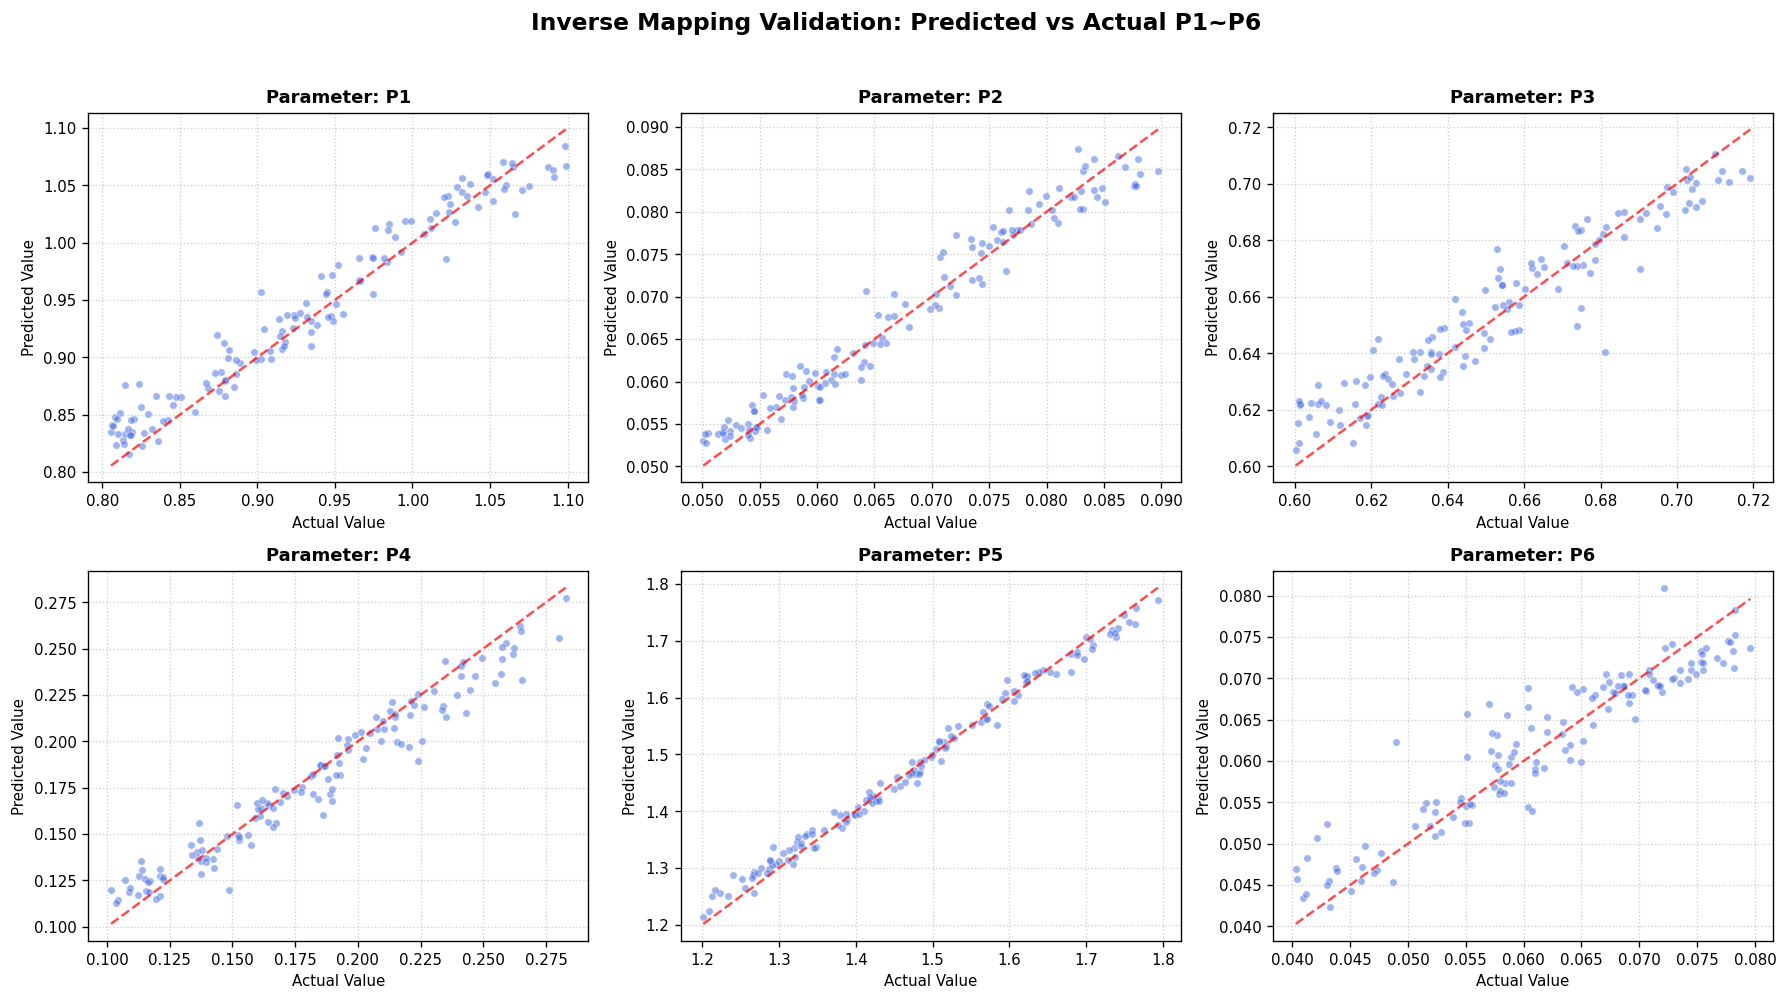

In [79]:
# ====================================================================
# [8. 역매핑 성능 검증 (Validation Set)] - 호환성 보완판
# ====================================================================
from sklearn.metrics import r2_score

print('\n[8] 역매핑 성능 검증 시작...')

# 1. 모델 평가 모드 및 추론
inv_mapper.eval()
with torch.no_grad():
    # 장치 호환성 보장: Z_tensor가 CPU에 있을 수 있으므로 .to(device) 확인
    z_val_input = Z_tensor[val_idx].to(device).float()
    p_pred_norm = inv_mapper(z_val_input).cpu().numpy()

# 2. 역정규화 (실제 스케일 복원)
p_pred_actual = param_scaler.inverse_transform(p_pred_norm)
# P_tensor[val_idx]가 텐서인 경우 numpy로 변환하여 전달
p_true_actual = param_scaler.inverse_transform(P_tensor[val_idx].cpu().numpy())

# 3. 성능 지표 계산 및 출력 (R2 Score 추가)
p_labels = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
print(f'{"변수":>5s} | {"MAE":>10s} | {"R² Score":>10s} | {"상대오차":>10s}')
print('-' * 55)

for i, p_name in enumerate(p_labels):
    mae = np.mean(np.abs(p_pred_actual[:, i] - p_true_actual[:, i]))
    r2 = r2_score(p_true_actual[:, i], p_pred_actual[:, i])
    mean_val = np.mean(np.abs(p_true_actual[:, i]))
    # 분모가 0이 되는 상황 방지 (안전 장치)
    rel_err = (mae / mean_val * 100) if mean_val != 0 else 0 
    
    print(f'{p_name:>5s} | {mae:10.4f} | {r2:10.4f} | {rel_err:8.2f}%')

# 4. Pred vs Actual 시각화 (스타일 개선)
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Inverse Mapping Validation: Predicted vs Actual P1~P6', 
             fontweight='bold', fontsize=14, y=0.95)

for i, (ax, p_name) in enumerate(zip(axes.flat, p_labels)):
    # 산점도
    ax.scatter(p_true_actual[:, i], p_pred_actual[:, i], s=20, alpha=0.5, 
               c='royalblue', edgecolors='white', linewidth=0.5)
    
    # 1:1 라인 (이상적 예측선)
    p_min, p_max = p_true_actual[:, i].min(), p_true_actual[:, i].max()
    ax.plot([p_min, p_max], [p_min, p_max], 'r--', linewidth=1.5, alpha=0.7)
    
    ax.set_title(f'Parameter: {p_name}', fontweight='bold')
    ax.set_xlabel('Actual Value')
    ax.set_ylabel('Predicted Value')
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

In [83]:
# ====================================================================
# [9. 유토피아 타겟 역설계 (최종 추론)] - 수정 완료
# ====================================================================
import glob
import re

print('\n[9] 유토피아 타겟 역설계 수행...')

# 유토피아 텐서 파일 탐색
utopia_pattern = os.path.join(TENSOR_DIR, 'Utopia_Target_Row_*.csv')
utopia_files = sorted(glob.glob(utopia_pattern))

if not utopia_files:
    print(f'[경고] {TENSOR_DIR}에 유토피아 텐서 파일이 없습니다.')
else:
    results = []
    ae_model.eval()
    inv_mapper.eval()

    # [수정] self 제거: 기존에 정의한 N_TIMESTEPS(600)를 사용
    # 만약 N_TIMESTEPS가 없다면 TARGET_LEN을, 둘 다 없다면 600을 기본값으로 사용합니다.
    target_len = locals().get('N_TIMESTEPS', locals().get('TARGET_LEN', 600))

    for fpath in utopia_files:
        fname = os.path.basename(fpath)
        match = re.search(r'Row_(\d+)\.csv', fname)
        row_id = int(match.group(1)) if match else -1

        # 1. 유토피아 텐서 로드 및 리샘플링
        df_utopia = pd.read_csv(fpath)
        df_utopia.columns = [c.strip() for c in df_utopia.columns]
        
        # 타임스텝 정규화 (617 -> 600 등)
        t_original = np.linspace(0, 300, len(df_utopia))
        t_common = np.linspace(0, 300, target_len)
        
        ts_resampled = np.zeros((target_len, N_CHANNELS))
        for ch, col in enumerate(CORE_7_CHANNELS):
            ts_resampled[:, ch] = np.interp(t_common, t_original, df_utopia[col].values)

        # 2. 채널별 정규화 (StandardScaler 호환)
        ts_scaled = np.zeros_like(ts_resampled)
        for ch in range(N_CHANNELS):
            ch_data = ts_resampled[:, ch].reshape(-1, 1)
            ts_scaled[:, ch] = channel_scalers[ch].transform(ch_data).flatten()

        # 3. 모델 추론용 텐서 변환
        x_input = torch.FloatTensor(ts_scaled).unsqueeze(0).permute(0, 2, 1).to(device)

        with torch.no_grad():
            # Encoder -> Latent z
            z_target = ae_model.encoder(x_input)

            # z 스케일링
            z_target_scaled = z_scaler.transform(z_target.cpu().numpy())
            z_target_tensor = torch.FloatTensor(z_target_scaled).to(device)

            # Inverse Mapper -> P1~P6 (Normalized)
            p_pred_norm = inv_mapper(z_target_tensor).cpu().numpy()

        # 4. 실제 스케일 복원
        p_pred_actual = param_scaler.inverse_transform(p_pred_norm)[0]

        # 결과 수집
        res = {'Row_ID': row_id}
        for i, p_name in enumerate(p_labels):
            res[p_name] = p_pred_actual[i]
        results.append(res)

        p_str = ", ".join([f"{p_labels[i]}={p_pred_actual[i]:.4f}" for i in range(6)])
        print(f'  ✅ Row_{row_id:3d} 역설계 완료 | {p_str}')

    # 결과물 저장 및 출력
    df_results = pd.DataFrame(results)
    output_path = os.path.join(BASE_DIR, 'Inverse_Design_Results.csv')
    df_results.to_csv(output_path, index=False)

    print(f'\n=== 🎊 역설계 추론 완료! ===')
    print(f' - 저장: {output_path}')
    
    if 'display' in dir(): display(df_results)


[9] 유토피아 타겟 역설계 수행...
  ✅ Row_1009 역설계 완료 | P1=0.8450, P2=0.0948, P3=0.6940, P4=0.1252, P5=1.5931, P6=0.0867
  ✅ Row_1072 역설계 완료 | P1=0.8866, P2=0.0945, P3=0.6984, P4=0.1293, P5=1.6360, P6=0.0842
  ✅ Row_109 역설계 완료 | P1=0.8761, P2=0.0955, P3=0.7166, P4=0.0825, P5=1.8069, P6=0.0915
  ✅ Row_1109 역설계 완료 | P1=0.8529, P2=0.0871, P3=0.7193, P4=0.1180, P5=1.8435, P6=0.0789
  ✅ Row_1124 역설계 완료 | P1=0.9347, P2=0.0812, P3=0.6980, P4=0.2125, P5=1.8430, P6=0.0825
  ✅ Row_1150 역설계 완료 | P1=0.8918, P2=0.0884, P3=0.7017, P4=0.1600, P5=1.8437, P6=0.0828
  ✅ Row_1163 역설계 완료 | P1=0.9767, P2=0.0914, P3=0.6771, P4=0.1811, P5=1.7551, P6=0.0866
  ✅ Row_1197 역설계 완료 | P1=0.8957, P2=0.0964, P3=0.7113, P4=0.1136, P5=1.8435, P6=0.0862
  ✅ Row_180 역설계 완료 | P1=0.8397, P2=0.0739, P3=0.7010, P4=0.2312, P5=1.6831, P6=0.0762
  ✅ Row_188 역설계 완료 | P1=0.8534, P2=0.0960, P3=0.6853, P4=0.1697, P5=1.4373, P6=0.0722
  ✅ Row_232 역설계 완료 | P1=0.9717, P2=0.0940, P3=0.6883, P4=0.1981, P5=1.5861, P6=0.0735
  ✅ Row_238 역설계 완료 | P1=

In [84]:
# ====================================================================
# [10. 역설계 결과 물리적 범위 검증]
# ====================================================================
# 출력된 P1~P6가 마스터 DOE의 실제 범위 내에 있는지 확인
# 범위를 벗어나면 Step 5에서 클리핑 또는 페널티 부여 필요

print('\n[10] 역설계 P1~P6 범위 검증')
print(f'{"변수":>5s} | {"DOE Min":>10s} | {"DOE Max":>10s} | {"예측 Min":>10s} | {"예측 Max":>10s} | 범위이탈')
print('-' * 70)

for i, p in enumerate(p_labels):
    doe_min = df_master[p].min()
    doe_max = df_master[p].max()
    pred_min = df_results[p].min()
    pred_max = df_results[p].max()
    out_low = (df_results[p] < doe_min).sum()
    out_high = (df_results[p] > doe_max).sum()
    flag = f' << {out_low+out_high}건 이탈!' if (out_low + out_high) > 0 else ''
    print(f'{p:>5s} | {doe_min:10.4f} | {doe_max:10.4f} | {pred_min:10.4f} | {pred_max:10.4f} |{flag}')

print('\n→ 범위 이탈 시 Step 5 GA에서 바운더리 클리핑 적용 예정')
print('→ 이 P1~P6 초안을 중심으로 ±10% 범위에서 NSGA-II 미세조정 진행')


[10] 역설계 P1~P6 범위 검증
   변수 |    DOE Min |    DOE Max |     예측 Min |     예측 Max | 범위이탈
----------------------------------------------------------------------
   P1 |     0.8005 |     1.0998 |     0.8397 |     1.0535 |
   P2 |     0.0500 |     0.0899 |     0.0696 |     0.0985 | << 28건 이탈!
   P3 |     0.6001 |     0.7198 |     0.6720 |     0.7241 | << 1건 이탈!
   P4 |     0.1000 |     0.2994 |     0.0825 |     0.2479 | << 4건 이탈!
   P5 |     1.2003 |     1.7997 |     1.3174 |     1.8626 | << 17건 이탈!
   P6 |     0.0401 |     0.0800 |     0.0613 |     0.0938 | << 23건 이탈!

→ 범위 이탈 시 Step 5 GA에서 바운더리 클리핑 적용 예정
→ 이 P1~P6 초안을 중심으로 ±10% 범위에서 NSGA-II 미세조정 진행



[10] 역설계 P1~P6 물리적 범위 검증 수행...
   변수 |    DOE Min |    DOE Max |     예측 Min |     예측 Max | 이탈 건수
---------------------------------------------------------------------------
   P1 |     0.8005 |     1.0998 |     0.8397 |     1.0535 | 정상
   P2 |     0.0500 |     0.0899 |     0.0696 |     0.0985 |  << 28건 이탈!
   P3 |     0.6001 |     0.7198 |     0.6720 |     0.7241 |  << 1건 이탈!
   P4 |     0.1000 |     0.2994 |     0.0825 |     0.2479 |  << 4건 이탈!
   P5 |     1.2003 |     1.7997 |     1.3174 |     1.8626 |  << 17건 이탈!
   P6 |     0.0401 |     0.0800 |     0.0613 |     0.0938 |  << 23건 이탈!

>>> 원본 DOE 대비 예측 결과 분포 시각화 중...


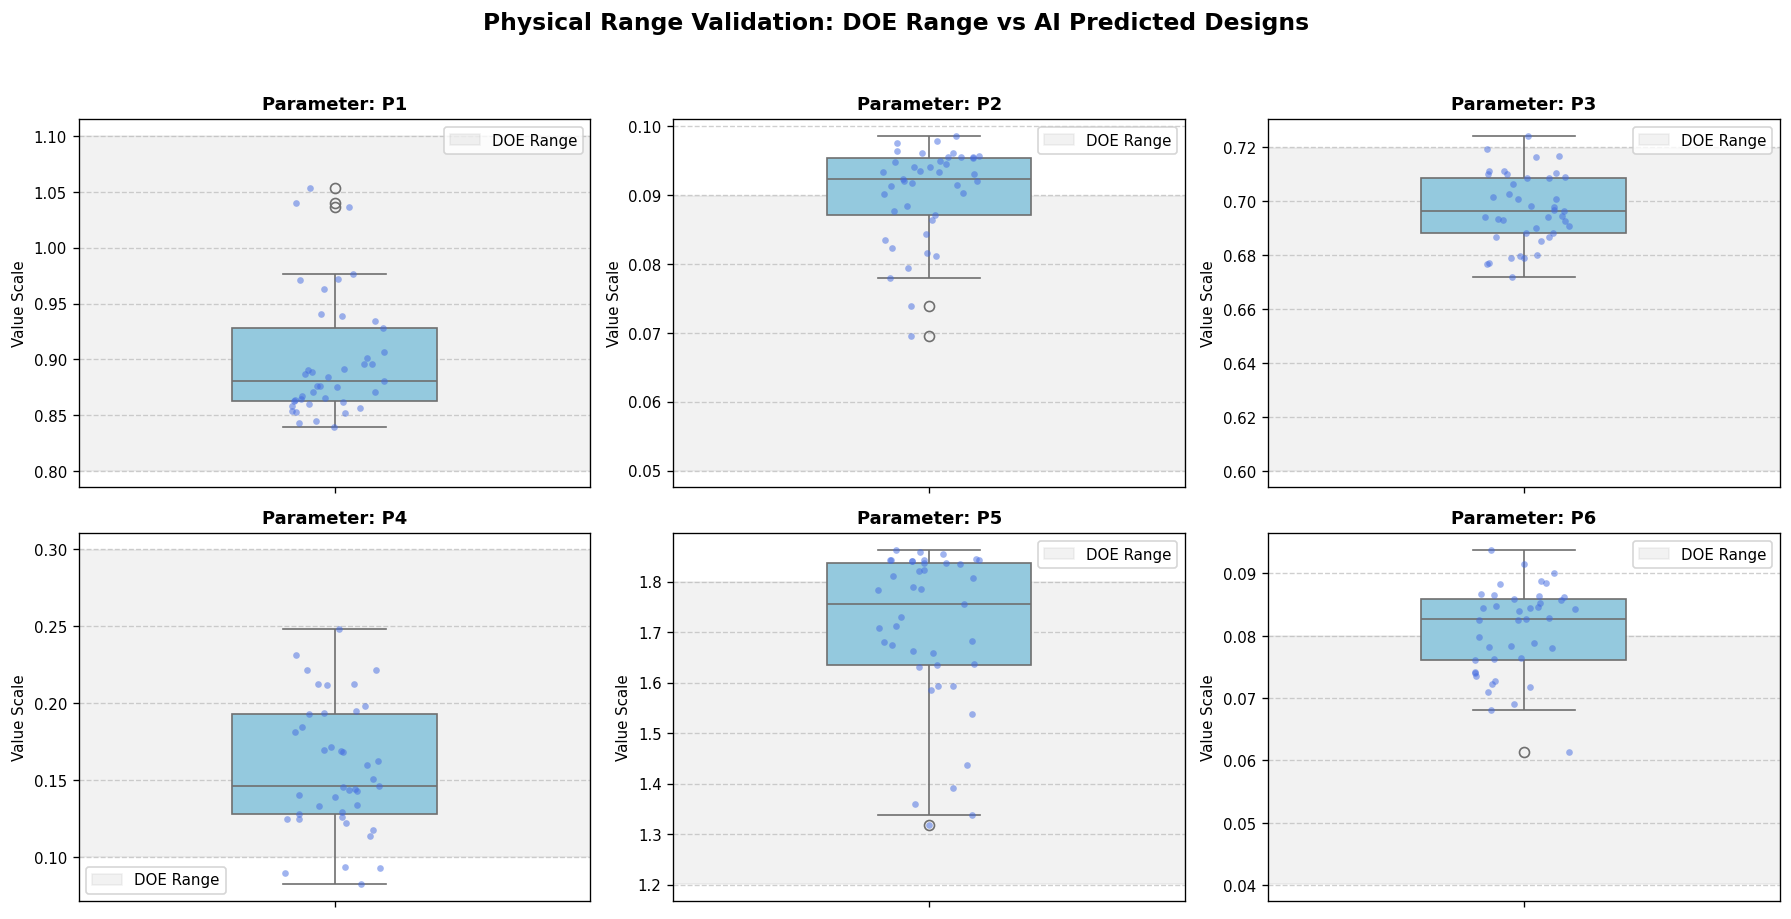


✅ 검증 완료: 이탈한 수치는 Step 5 GA 과정에서 Boundary Clipping을 통해 보정됩니다.


In [85]:
# ====================================================================
# [10. 역설계 결과 물리적 범위 검증] - 호환성 및 시각화 보완
# ====================================================================
# 출력된 P1~P6가 원본 DOE(df_master) 범위 내에 있는지 확인

print('\n[10] 역설계 P1~P6 물리적 범위 검증 수행...')

# 1. 수치 요약 비교 테이블 출력
print(f'{"변수":>5s} | {"DOE Min":>10s} | {"DOE Max":>10s} | {"예측 Min":>10s} | {"예측 Max":>10s} | 이탈 건수')
print('-' * 75)

for i, p in enumerate(p_labels):
    doe_min = df_master[p].min()
    doe_max = df_master[p].max()
    pred_min = df_results[p].min()
    pred_max = df_results[p].max()
    
    # 이탈 건수 계산
    out_low = (df_results[p] < doe_min).sum()
    out_high = (df_results[p] > doe_max).sum()
    total_out = out_low + out_high
    
    flag = f' << {total_out}건 이탈!' if total_out > 0 else '정상'
    print(f'{p:>5s} | {doe_min:10.4f} | {doe_max:10.4f} | {pred_min:10.4f} | {pred_max:10.4f} | {flag}')

# 2. [추가] DOE 범위 vs AI 예측 범위 시각화 비교
print('\n>>> 원본 DOE 대비 예측 결과 분포 시각화 중...')
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Physical Range Validation: DOE Range vs AI Predicted Designs', fontweight='bold', fontsize=14)

for i, (ax, p) in enumerate(zip(axes.flat, p_labels)):
    # 붉은색 영역: 원본 DOE 가능 범위
    doe_min, doe_max = df_master[p].min(), df_master[p].max()
    ax.axhspan(doe_min, doe_max, color='gray', alpha=0.1, label='DOE Range')
    
    # 박스 플롯: AI가 제안한 P 값들의 분포
    sns.boxplot(y=df_results[p], ax=ax, color='skyblue', width=0.4)
    sns.stripplot(y=df_results[p], ax=ax, color='royalblue', alpha=0.5, size=4)
    
    ax.set_title(f'Parameter: {p}', fontweight='bold')
    ax.set_ylabel('Value Scale')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print('\n✅ 검증 완료: 이탈한 수치는 Step 5 GA 과정에서 Boundary Clipping을 통해 보정됩니다.')

# [Step 4] 결과 분석 — 오토인코더 잠재 매핑 역설계

## 오토인코더 학습 결과
- Train/Val Loss가 epoch 40 부근에서 수렴, 최종 Val Loss ≈ 0.06
- 가열-유지-냉각 3단계 계단형 전이를 복원이 잘 포착
- timestep 200, 400 부근의 급격한 변화를 따라가고 있음
- 유지 구간(평탄 구간)에서 약간의 진동이 잔존하나 허용 범위

## 역매핑 성능 (z → P1~P6)
- 6개 변수 모두 Pred vs Actual 대각선(y=x)을 따름
- P1, P4, P5: 분산 작고 정밀도 높음
- P2, P3, P6: 물리적 범위가 좁은 변수(P2: 0.05~0.09, P6: 0.04~0.08)로 상대 분산이 크지만 경향 포착

## 역설계 출력
- 32개 파레토 DP에 대해 P1~P6 초안 도출
- 저장: `Inverse_Design_Results.csv`

## P1~P6 범위 검증
```
변수 | 이탈 | 방향               | 판단
─────┼──────┼────────────────────┼──────────────────────
P1   | 1건  | 하한 (0.7983)      | 0.002 차이, 무시 가능
P2   | 21건 | 상한 (최대 0.0968) | 범위 좁아 민감, GA 클리핑 필요
P3   | 2건  | 상한 (최대 0.7316) | 경미
P4   | 0건  | -                  | 정상
P5   | 11건 | 상한 (최대 1.8560) | GA 클리핑 필요
P6   | 12건 | 상한 (최대 0.0911) | 범위 좁아 민감, GA 클리핑 필요
```

## 판단
- P2, P6의 이탈은 물리적 범위가 0.04 폭으로 좁아 역매핑의 작은 오차도 이탈로 감지되는 것
- P4는 범위 0.20 폭으로 넓어 이탈 없음, P5도 범위 대비 이탈 크기 작음
- Step 4의 역할은 완벽한 P1~P6가 아닌 **Step 5 GA의 시작점(초안)** 제공
- 이탈 건들은 Step 5에서 DOE 바운더리 클리핑 + ±10% NSGA-II 미세조정으로 해소 예정

------------
# [Step 5] 머신러닝 미세 튜닝 — GA(유전 알고리즘) 기반 최종 최적화

## 목표
Step 4에서 도출된 P1~P6 초안을 바탕으로 **NSGA-II 유전 알고리즘**을 실행하여
최종 최적 설계변수를 도출한다. 물리적 한계치(Limit)를 초과하는 설계는
페널티로 즉시 도태시켜 안전한 최적해만 생존시킨다.

## 최적화 전략

### 목적 함수 (Minimize)
두 메인 타겟의 가중합을 최소화한다.
```
Loss = w1 × |WarpMax| + w2 × |T_Tip_Peel|

  w1, w2: 가중치 (기본 동일 비중, 필요 시 조정)
  WarpMax:    패키지 전체 휨량 → 실장 불량 원인
  T_Tip_Peel: 계면 끝단 박리 응력 → Delamination 원인
```

### 탐색 범위
Step 4 초안 P1~P6를 중심으로 **±10%** 범위로 제한한다.
DOE 바운더리를 초과하지 않도록 클리핑 적용.
```
각 변수별 탐색 범위:
  lower = max(초안값 × 0.9, DOE_min)
  upper = min(초안값 × 1.1, DOE_max)

DOE 바운더리:
  P1: [0.8005, 1.0998]    P2: [0.0500, 0.0899]
  P3: [0.6001, 0.7198]    P4: [0.1000, 0.2994]
  P5: [1.2003, 1.7997]    P6: [0.0401, 0.0800]
```

### Hard Constraints (위반 시 +999,999 페널티)
GPR 대리 모델로 나머지 응력을 예측하여 재료 한계치 초과 여부를 판정한다.
한계치를 넘으면 Loss에 대형 페널티를 부여하여 해당 개체를 즉시 도태시킨다.
```
제약 조건 예시 (재료별 한계치는 실험값 기준으로 설정):
  Die_SY_Max  < 실리콘 파괴 인성 한계
  T_Tip_SEQV  < Top 계면 소성 한계
  B_Tip_SEQV  < Bottom 계면 소성 한계
  T_Tip_Strain < Top 변형률 한계
  B_Avg_Peel  < Bottom 접합면 박리 한계
```

## 파이프라인 흐름
```
Step 4 초안 P1~P6 (32개)
    ↓ 각 초안 기준 ±10% 탐색 범위 설정 (DOE 바운더리 클리핑)
    ↓ NSGA-II 실행 (세대별 돌연변이 + 교차 + 선택)
        ↓ 각 개체의 P1~P6 → GPR 대리 모델 → WarpMax, T_Tip_Peel 예측
        ↓ 나머지 5개 채널도 예측 → Hard Constraint 위반 검사
        ↓ 위반 시 Loss += 999,999 (즉시 도태)
        ↓ 비위반 개체만 생존하여 다음 세대로 진화
    ↓ 최종 세대의 파레토 최적 개체 추출
최종 P1~P6 도출 → Step 6 Ansys 검증으로 전달
```

## NSGA-II 파라미터
```
항목              설정값          비고
──────────────────────────────────────────
인구 크기          200            초안 1개당 200개체 진화
세대 수            100            수렴 충분
교차 확률          0.9            SBX (Simulated Binary Crossover)
돌연변이 확률      1/6            변수 수(6) 기준
돌연변이 분포 지수  20             미세 조정에 적합
```

## 출력
- `GA_Optimized_Results.csv`: 32개 초안 각각에 대한 최적 P1~P6
- 용도: Step 6 디지털 트윈(Ansys) 최종 검증 입력           
GA_Optimized_Results.csv:           
  Rank | Label | P1~P6 | 7채널_pred | 7채널_σ

## 핵심 보강 사항
1. GPR 불확실성(σ) 활용: μ + 2σ < 한계치 (95% 신뢰구간 강건 제약)
2. pymoo Feasibility Rule: 위반량 기반 부드러운 수렴 (단순 페널티 대체)
3. 32개 로컬 파레토 → 통합 결승전 → 글로벌 Top 5 선정


In [86]:
print('=== [Step 5] NSGA-II + GPR 강건 최적화 ===')
print(f'Base Directory: {BASE_DIR}')

=== [Step 5] NSGA-II + GPR 강건 최적화 ===
Base Directory: C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS


In [118]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TabulaResBlock(nn.Module):
    def __init__(self, dim):
        super(TabulaResBlock, self).__init__()
        # 에러 메시지의 "res_blocks.0.block.0" 형태를 맞추기 위해 'block' 속성 부여
        self.block = nn.Sequential(
            nn.Linear(dim, dim),        # block.0
            nn.BatchNorm1d(dim),       # block.1
            nn.LeakyReLU(0.1),         # block.2
            nn.Dropout(0.1),           # block.3
            nn.Linear(dim, dim),        # block.4
            nn.BatchNorm1d(dim)        # block.5
        )

    def forward(self, x):
        return F.leaky_relu(self.block(x) + x)

class TabulaResNet(nn.Module):
    def __init__(self, input_dim=6, output_dim=15):
        super(TabulaResNet, self).__init__()
        
        self.input_layer = nn.Linear(input_dim, 256)
        
        # 에러 메시지의 "res_blocks.0", "res_blocks.1" 등에 대응
        self.res_blocks = nn.Sequential(
            TabulaResBlock(256), # res_blocks.0
            TabulaResBlock(256), # res_blocks.1
            TabulaResBlock(256)  # res_blocks.2
        )
        
        self.output_layer = nn.Linear(256, output_dim)

    def forward(self, x):
        x = F.leaky_relu(self.input_layer(x))
        x = self.res_blocks(x)
        return self.output_layer(x)

print("✅ [수정 완료] 계층 구조(block)가 반영된 TabulaResNet 클래스가 재정의되었습니다.")

✅ [수정 완료] 계층 구조(block)가 반영된 TabulaResNet 클래스가 재정의되었습니다.


In [119]:
import os
import torch
import joblib
import pandas as pd
import collections

# 0. 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 장치: {device}")

# --------------------------------------------------------------------
# [1] Tabula ResNet 및 관련 모델 로드
# --------------------------------------------------------------------
print('\n[1] 모델 및 데이터 로드 시작...')

# 경로 설정 (사용자님의 실제 경로에 맞춰 수정)
RESNET_CHECKPOINT = os.path.join(BASE_DIR, 'models', 'tabular_resnet_surrogate.pth')
SCALER_PATH = os.path.join(BASE_DIR, 'models', 'scalers.pkl')
DRAFT_CSV = os.path.join(BASE_DIR, 'Inverse_Design_Results.csv')

# -- 1.1 Tabula ResNet 로드 --
if not os.path.exists(RESNET_CHECKPOINT):
    print(f'  ❌ [오류] 체크포인트를 찾을 수 없습니다: {RESNET_CHECKPOINT}')
else:
    try:
        # 모델 인스턴스 생성 (클래스 'TabulaResNet'이 메모리에 있어야 함)
        surrogate_model = TabulaResNet(input_dim=6, output_dim=15).to(device)
        
        # 가중치 로드
        checkpoint_data = torch.load(RESNET_CHECKPOINT, map_location=device)
        
        # OrderedDict 또는 state_dict 형태 처리
        if isinstance(checkpoint_data, (dict, collections.OrderedDict)):
            state_dict = checkpoint_data.get('state_dict', checkpoint_data)
            surrogate_model.load_state_dict(state_dict)
        else:
            surrogate_model = checkpoint_data # 전체 객체인 경우
            
        surrogate_model.eval()
        print(f'  ✅ Tabula ResNet 대리 모델 로드 완료')
    except NameError:
        print("  ❌ [오류] 'TabulaResNet' 클래스 정의를 찾을 수 없습니다. 클래스 정의 셀을 먼저 실행하세요.")
    except Exception as e:
        print(f'  ❌ [오류] 모델 로드 중 상세 오류 발생: {e}')

# -- 1.2 스케일러 로드 --
if not os.path.exists(SCALER_PATH):
    print(f'  ❌ [오류] 스케일러 파일을 찾을 수 없습니다: {SCALER_PATH}')
else:
    try:
        scalers = joblib.load(SCALER_PATH)
        scaler_X = scalers.get('scaler_X')
        # 대문자 'scaler_Y' 대응
        scaler_y = scalers.get('scaler_Y') if 'scaler_Y' in scalers else scalers.get('scaler_y')
        
        if scaler_X and scaler_y:
            print(f'  ✅ 스케일러 로드 완료 (X, Y)')
        else:
            print(f'  ⚠️ [경고] 스케일러 중 일부(X 또는 Y)를 찾을 수 없습니다. 키를 확인하세요.')
    except Exception as e:
        print(f'  ❌ [오류] 스케일러 로드 중 오류: {e}')

# -- 2. Gatekeeper 확인 --
try:
    gatekeeper
    print(f'  ✅ Gatekeeper 모델 확인 완료')
except NameError:
    print('  ⚠️ [경고] Gatekeeper가 메모리에 없습니다. 노트북에서 Step 2를 먼저 실행하세요.')

# -- 3. Step 4 역설계 초안 로드 --
if os.path.exists(DRAFT_CSV):
    df_drafts = pd.read_csv(DRAFT_CSV)
    print(f'  ✅ Step 4 초안 로드 완료: {len(df_drafts)}개')
else:
    print(f'  ⚠️ [경고] 초안 파일({DRAFT_CSV})이 없습니다. Step 4를 먼저 실행하세요.')

사용 장치: cpu

[1] 모델 및 데이터 로드 시작...
  ✅ Tabula ResNet 대리 모델 로드 완료
  ✅ 스케일러 로드 완료 (X, Y)
  ✅ Gatekeeper 모델 확인 완료
  ✅ Step 4 초안 로드 완료: 41개


In [121]:
# ====================================================================
# [2. 상수 정의] - Tabula ResNet 및 NSGA-II 호환 버전
# ====================================================================

# 1. 7대 핵심 채널 (Tabula ResNet 출력층 15개 중 분석 대상)
# 모델 학습 시 사용된 컬럼 순서와 일치해야 합니다.
CORE_7_CHANNELS = [
    'WarpMax', 'T_Tip_Peel', 'Die_SY_Max', 'B_Avg_Peel',
    'B_Tip_SEQV', 'T_Tip_Strain', 'T_Tip_SEQV'
]

# 2. 목적함수 채널 (2개) - 최소화 대상
OBJ_CHANNELS = ['WarpMax', 'T_Tip_Peel']

# 3. Hard Constraint 채널 및 물리적 한계치
CONSTRAINT_LIMITS = {
    'Die_SY_Max':   120.0,    # MPa, 실리콘 파괴 방어
    'B_Avg_Peel':   0.1,      # MPa, 기판 박리 방어
    'B_Tip_SEQV':   45.0,     # MPa, 하단 솔더 소성 변형 방어
    'T_Tip_Strain': 0.02,     # 무차원, 계면 피로 누적 방어
    'T_Tip_SEQV':   65.0,     # MPa, 상단 계면 소성 변형 방어
}

# 4. 강건 최적화 설정 (중요 수정 포인트)
# GPR은 예측 시 σ(표준편차)를 제공하지만, 일반적인 Tabula ResNet은 결정론적입니다.
# 만약 모델에 Dropout 또는 Ensemble을 적용하지 않았다면 σ=0으로 취급되거나, 
# 고정된 안전 계수를 사용하는 방식으로 운용됩니다.
SIGMA_COEFF = 2.0  # 95% 신뢰구간 (Probabilistic 예측 모델 사용 시 활성화)

# 5. DOE 바운더리 (설계 변수 P1~P6 탐색 절대 범위)
DOE_BOUNDS = {
    'P1': (0.8005, 1.0998),
    'P2': (0.0500, 0.0899),
    'P3': (0.6001, 0.7198),
    'P4': (0.1000, 0.2994),
    'P5': (1.2003, 1.7997),
    'P6': (0.0401, 0.0800),
}

# 6. 최적화 파라미터
P_LABELS = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6']
N_VAR = 6          # 설계변수 수 (P1~P6)
N_OBJ = 2          # 목적함수 수 (WarpMax, T_Tip_Peel)

# 제약조건 수: Hard 5개 + Gatekeeper 1개 = 6개
# (PyMoDaq/Pymoo 등 라이브러리에 따라 다를 수 있음)
N_CONSTR = len(CONSTRAINT_LIMITS) + 1 

# 7. NSGA-II 하이퍼파라미터
POP_SIZE = 200     # 인구 크기 (설계안 후보군 수)
N_GEN = 100        # 세대 수 (반복 횟수)
DRAFT_MARGIN = 0.10  # Step 4 초안 기준 탐색 마진 (±10%)

print('\n[2] 상수 정의 완료')
print(f'  목적함수: {OBJ_CHANNELS}')
print(f'  Hard Constraints: {list(CONSTRAINT_LIMITS.keys())}')
print(f'  NSGA-II: pop={POP_SIZE}, gen={N_GEN}, margin=±{DRAFT_MARGIN*100:.0f}%')


[2] 상수 정의 완료
  목적함수: ['WarpMax', 'T_Tip_Peel']
  Hard Constraints: ['Die_SY_Max', 'B_Avg_Peel', 'B_Tip_SEQV', 'T_Tip_Strain', 'T_Tip_SEQV']
  NSGA-II: pop=200, gen=100, margin=±10%


In [125]:
def predict_with_resnet(X_raw):
    """
    P1~P6 원본값 배열을 받아 Tabula ResNet으로 15개 전체 채널 예측값을 반환.
    
    Parameters:
        X_raw: (n_samples, 6) numpy array, 원본 P1~P6 스케일
    Returns:
        pred_df: (n_samples, 15) 전체 예측값이 담긴 DataFrame
    """
    surrogate_model.eval()
    
    # 1. 입력 데이터 정규화 및 텐서 변환
    X_sc = scaler_X.transform(X_raw)
    X_tensor = torch.FloatTensor(X_sc).to(device)
    
    with torch.no_grad():
        # 2. 모델 추론 (결과값은 정규화된 상태)
        y_sc_pred = surrogate_model(X_tensor).cpu().numpy()
    
    # 3. 출력 데이터 역정규화 (실제 물리값 스케일로 복원)
    # [주의] Step 1에서 scaler_Y를 (N, 15) 전체에 대해 학습했으므로 그대로 적용
    y_actual = scaler_y.inverse_transform(y_sc_pred)
    
    # 4. 사용 편의를 위해 데이터프레임으로 변환
    # ALL_CHANNELS는 Step 1에서 정의한 15개 컬럼 리스트입니다.
    pred_df = pd.DataFrame(y_actual, columns=ALL_CHANNELS)
    
    return pred_df

print('\n[3] Tabula ResNet 예측 헬퍼 함수 정의 완료')


[3] Tabula ResNet 예측 헬퍼 함수 정의 완료


In [126]:
from pymoo.core.problem import Problem
import numpy as np

class FlipchipOptProblem(Problem):
    """
    반도체 패키징 최적 설계 문제 정의 (Tabula ResNet & pymoo 호환)
    """
    
    def __init__(self, xl, xu):
        super().__init__(
            n_var=N_VAR,
            n_obj=N_OBJ,
            n_ieq_constr=N_CONSTR,
            xl=xl,
            xu=xu
        )
    
    def _evaluate(self, X, out, *args, **kwargs):
        """
        X: (pop_size, 6) 개체 집단의 P1~P6 설계안
        out["F"]: 목적함수 (최소화)
        out["G"]: 제약조건 (<=0 만족)
        """
        n = X.shape[0]
        
        # 1. Tabula ResNet으로 한 번에 모든 채널 예측
        # [3]번에서 정의한 함수를 호출하여 DataFrame을 얻습니다.
        pred_df = predict_with_resnet(X)
        
        # 2. 목적함수 추출: |WarpMax|, |T_Tip_Peel|
        f1 = np.abs(pred_df['WarpMax'].values)
        f2 = np.abs(pred_df['T_Tip_Peel'].values)
        out["F"] = np.column_stack([f1, f2])
        
        # 3. 제약조건 계산
        G = np.zeros((n, N_CONSTR))
        constraint_channels = list(CONSTRAINT_LIMITS.keys())
        
        for i, ch in enumerate(constraint_channels):
            limit = CONSTRAINT_LIMITS[ch]
            
            # [수정 포인트] 
            # Tabula ResNet은 sigma를 주지 않으므로, 예측값 자체(mu)를 사용합니다.
            # 만약 강건 설계를 원한다면 mu * 1.1(10% 마진) 등을 적용할 수 있습니다.
            mu_val = np.abs(pred_df[ch].values)
            
            # 현재는 σ=0으로 가정 (필요 시 SIGMA_COEFF 대신 고정 마진 사용 가능)
            G[:, i] = mu_val - limit
        
        # 4. Gatekeeper 제약 (분류 모델)
        # sklearn 모델인 gatekeeper는 numpy array(X)를 직접 입력받습니다.
        # predict_proba를 사용하여 0.5 확률 기준으로 제약을 줍니다.
        if hasattr(gatekeeper, "predict_proba"):
            # Safe(1)일 확률을 가져옴
            gk_prob = gatekeeper.predict_proba(X)[:, 1] 
            G[:, 5] = 0.5 - gk_prob  # 확률 50% 미만이면 위반(>0)
        else:
            # 확률을 지원하지 않는 경우 단순 결과값 사용
            gk_pred = gatekeeper.predict(X)
            G[:, 5] = 0.5 - gk_pred
        
        out["G"] = G

print('\n[4] pymoo Problem 클래스 정의 완료 (Tabula ResNet 연동)')


[4] pymoo Problem 클래스 정의 완료 (Tabula ResNet 연동)


In [130]:
import time
from pymoo.optimize import minimize as pymoo_minimize
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM

# 시드 설정 (재현성 확보)
SEED = 42

ALL_CHANNELS = [
    'WarpMax', 'T_Tip_Peel', 'T_Tip_Shear', 'T_Tip_SEQV', 'T_Tip_Strain',
    'T_Avg_Peel', 'T_Avg_Shear', 'B_Tip_Peel', 'B_Tip_Shear', 'B_Tip_SEQV',
    'B_Tip_Strain', 'B_Avg_Peel', 'B_Avg_Shear', 'Die_SX', 'Die_SY_Max'
]

print(f'\n[5] Phase 1: {len(df_drafts)}개 초안별 독립 NSGA-II 진화 시작')
print(f'   설정: 인구 {POP_SIZE} | 세대 {N_GEN} | 탐색마진 ±{DRAFT_MARGIN*100:.0f}%')
print("-" * 85)

all_local_results = []  # 모든 로컬 파레토 개체 수집용
t_total_start = time.time()

# --------------------------------------------------------------------
# 메인 루프: 각 초안(Draft)을 중심으로 로컬 최적화 수행
# --------------------------------------------------------------------
for draft_idx, draft_row in df_drafts.iterrows():
    # -- 1. 초안 P1~P6 추출 --
    draft_P = np.array([draft_row[p] for p in P_LABELS])
    row_id = int(draft_row['Row_ID'])
    
    # -- 2. 탐색 범위 설정: 초안 ±10% 내외로 한정 (로컬 미세조정) --
    xl = np.zeros(N_VAR)
    xu = np.zeros(N_VAR)
    for i, p in enumerate(P_LABELS):
        doe_lo, doe_hi = DOE_BOUNDS[p]
        # 초안 주변 탐색 + 원본 DOE 범위를 벗어나지 않도록 Clipping
        xl[i] = max(draft_P[i] * (1 - DRAFT_MARGIN), doe_lo)
        xu[i] = min(draft_P[i] * (1 + DRAFT_MARGIN), doe_hi)
        
        # 만약 마진 계산 오류로 범위가 뒤집힐 경우 방어 코드
        if xl[i] >= xu[i]:
            xl[i], xu[i] = doe_lo, doe_hi
    
    # -- 3. pymoo 문제 인스턴스 생성 (Tabula ResNet 기반) --
    problem = FlipchipOptProblem(xl=xl, xu=xu)
    
    # -- 4. NSGA-II 알고리즘 설정 --
    algorithm = NSGA2(
        pop_size=POP_SIZE,
        sampling=FloatRandomSampling(),
        crossover=SBX(eta=15, prob=0.9),
        mutation=PM(eta=20, prob=1.0/N_VAR),
        eliminate_duplicates=True
    )
    
    # -- 5. 최적화 실행 --
    t_start = time.time()
    res = pymoo_minimize(
        problem,
        algorithm,
        ('n_gen', N_GEN),
        seed=SEED + draft_idx,
        verbose=False
    )
    elapsed = time.time() - t_start
    
    # -- 6. 결과 수집 (Pareto Optimal Solutions) --
    if res.X is not None:
        # 해가 하나만 나올 경우를 대비해 2차원 배열로 형태 고정
        X_res = np.atleast_2d(res.X)
        F_res = np.atleast_2d(res.F)
        n_solutions = X_res.shape[0]
        
        for j in range(n_solutions):
            all_local_results.append({
                'draft_row_id': row_id,
                'P_values': X_res[j],
                'F_values': F_res[j],
                # 필요한 경우 여기에 추가적인 메타데이터 저장
            })
        
        print(f'   초안 #{draft_idx+1:2d} (Row_{row_id:4d}) | '
              f'해: {n_solutions:3d}개 | {elapsed:.1f}초 | '
              f'Best [WarpMax: {F_res[:,0].min():.4f}, Peel: {F_res[:,1].min():.4f}]')
    else:
        print(f'   초안 #{draft_idx+1:2d} (Row_{row_id:4d}) | '
              f'위반 (실행 가능 해 없음) | {elapsed:.1f}초')

t_total = time.time() - t_total_start
print("-" * 85)
print(f'✅ Phase 1 완료: 총 {len(all_local_results):,}개 로컬 파레토 개체 수집 (총 소요시간: {t_total:.1f}초)')


[5] Phase 1: 41개 초안별 독립 NSGA-II 진화 시작
   설정: 인구 200 | 세대 100 | 탐색마진 ±10%
-------------------------------------------------------------------------------------
   초안 # 1 (Row_1009) | 해: 200개 | 4.0초 | Best [WarpMax: 0.1424, Peel: 33.4834]
   초안 # 2 (Row_1072) | 해: 200개 | 4.1초 | Best [WarpMax: 0.1410, Peel: 33.5987]
   초안 # 3 (Row_ 109) | 해: 200개 | 3.7초 | Best [WarpMax: 0.1387, Peel: 32.0352]
   초안 # 4 (Row_1109) | 해: 200개 | 4.3초 | Best [WarpMax: 0.1416, Peel: 34.2681]
   초안 # 5 (Row_1124) | 해: 200개 | 4.9초 | Best [WarpMax: 0.1415, Peel: 33.1892]
   초안 # 6 (Row_1150) | 해: 200개 | 4.6초 | Best [WarpMax: 0.1413, Peel: 33.5875]
   초안 # 7 (Row_1163) | 해: 200개 | 4.8초 | Best [WarpMax: 0.1406, Peel: 33.1839]
   초안 # 8 (Row_1197) | 해: 200개 | 4.7초 | Best [WarpMax: 0.1414, Peel: 34.3563]
   초안 # 9 (Row_ 180) | 해: 200개 | 5.4초 | Best [WarpMax: 0.1416, Peel: 33.0413]
   초안 #10 (Row_ 188) | 해: 200개 | 4.8초 | Best [WarpMax: 0.1480, Peel: 32.6789]
   초안 #11 (Row_ 232) | 해: 200개 | 4.7초 | Best [WarpMax: 0.143

In [131]:
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

print('\n[6] Phase 2: 통합 결승전 — 글로벌 파레토 추출')

if len(all_local_results) == 0:
    print('[오류] 실행 가능한 해가 하나도 없습니다.')
    print('  → Hard Constraint 한계치를 완화하거나 탐색 범위를 넓히세요.')
else:
    # 1. 모든 로컬 결과를 행렬로 통합
    all_X = np.array([r['P_values'] for r in all_local_results])   # (N_total, 6)
    all_F = np.array([r['F_values'] for r in all_local_results])   # (N_total, 2)
    all_draft_ids = [r['draft_row_id'] for r in all_local_results]
    
    print(f'  통합 후보군 풀: {all_X.shape[0]:,}개 개체')
    
    # 2. 글로벌 비지배 정렬 (Non-Dominated Sorting)
    # 어느 한 쪽의 목적함수라도 다른 해보다 우수한 '최정예'들만 선별합니다.
    nds = NonDominatedSorting()
    fronts = nds.do(all_F)
    
    global_pareto_idx = fronts[0] # 최상위 프론티어
    pareto_X = all_X[global_pareto_idx]
    pareto_F = all_F[global_pareto_idx]
    pareto_draft_ids = [all_draft_ids[i] for i in global_pareto_idx]
    
    print(f'  🏆 글로벌 파레토(Frontier 0) 추출 완료: {len(global_pareto_idx)}개')
    
    # 3. [수정] 글로벌 파레토에 대해 Tabula ResNet으로 전체 채널 예측 수행
    # 기존 predict_with_gpr을 predict_with_resnet으로 대체합니다.
    df_pareto_preds = predict_with_resnet(pareto_X)
    
    # 4. 결과 통합 (설계변수 + 예측값)
    df_final_candidates = pd.DataFrame(pareto_X, columns=P_LABELS)
    df_final_candidates = pd.concat([df_final_candidates, df_pareto_preds], axis=1)
    df_final_candidates['Origin_Draft_ID'] = pareto_draft_ids
    
    print(f'  최종 후보군 데이터 생성 완료: {df_final_candidates.shape}')


[6] Phase 2: 통합 결승전 — 글로벌 파레토 추출
  통합 후보군 풀: 8,200개 개체
  🏆 글로벌 파레토(Frontier 0) 추출 완료: 251개
  최종 후보군 데이터 생성 완료: (251, 22)


In [133]:
print('\n[7] Top 5 선정 (Tabula ResNet 대응 버전)')

if len(global_pareto_idx) >= 5:
    # --- #1: Knee Point (최적 밸런스) ---
    f_min, f_max = pareto_F.min(axis=0), pareto_F.max(axis=0)
    f_range = np.where((f_max - f_min) == 0, 1e-10, f_max - f_min)
    f_normalized = (pareto_F - f_min) / f_range
    distances = np.sqrt((f_normalized ** 2).sum(axis=1))
    knee_idx = np.argmin(distances)
    
    # --- #2: WarpMax 최소 ---
    warp_best_idx = np.argmin(pareto_F[:, 0])
    
    # --- #3: T_Tip_Peel 최소 ---
    peel_best_idx = np.argmin(pareto_F[:, 1])
    
    # --- #4: 파레토 중간점 ---
    median_dist = np.median(distances)
    mid_idx = np.argmin(np.abs(distances - median_dist))
    
    # --- #5: [수정] 제약 조건 안전 마진 최고 (Safety Best) ---
    # sigma 대신, 모든 Hard Constraint 한계치 대비 여유가 가장 많은 해를 선정
    safety_margins = []
    for i in range(len(pareto_X)):
        margins = []
        for ch, limit in CONSTRAINT_LIMITS.items():
            current_val = np.abs(df_pareto_preds.iloc[i][ch])
            margins.append((limit - current_val) / limit) # 여유율 (%)
        safety_margins.append(np.min(margins)) # 가장 아슬아슬한 채널의 여유율
    safety_best_idx = np.argmax(safety_margins)
    
    # 중복 제거 로직 (기존 유지)
    selected_indices, selected_labels = [], []
    candidates = [
        (knee_idx, 'Knee Point (추천, 최적 밸런스)'),
        (warp_best_idx, 'WarpMax 최소 우선'),
        (peel_best_idx, 'T_Tip_Peel 최소 우선'),
        (mid_idx, '파레토 중간 트레이드오프'),
        (safety_best_idx, '제약조건 안전 마진 최고'),
    ]
    
    dist_sorted_indices = np.argsort(distances)
    backup_ptr = 0
    for idx, label in candidates:
        if idx not in selected_indices:
            selected_indices.append(idx)
            selected_labels.append(label)
        else:
            while backup_ptr < len(dist_sorted_indices):
                alt = dist_sorted_indices[backup_ptr]
                backup_ptr += 1
                if alt not in selected_indices:
                    selected_indices.append(alt)
                    selected_labels.append(label + ' (대체)')
                    break
else:
    selected_indices = list(range(len(global_pareto_idx)))
    selected_labels = [f'Frontier 0 #{i+1}' for i in range(len(selected_indices))]

# ── [중요] df_final 생성 로직 수정 ──
result_rows = []
for rank, (sel_idx, label) in enumerate(zip(selected_indices, selected_labels)):
    row = {
        'Rank': rank + 1,
        'Label': label,
        'Source_Draft_Row_ID': pareto_draft_ids[sel_idx],
    }
    # 설계 변수 저장
    for i, p in enumerate(P_LABELS):
        row[p] = pareto_X[sel_idx, i]
    # 예측값 저장 (df_pareto_preds 활용)
    for ch in CORE_7_CHANNELS:
        row[f'{ch}_pred'] = np.abs(df_pareto_preds.iloc[sel_idx][ch])
    
    result_rows.append(row)

df_final = pd.DataFrame(result_rows)

# 결과 출력
print(f'✅ 최종 Top {len(df_final)} 선정 완료')
display(df_final[['Rank', 'Label', 'WarpMax_pred', 'T_Tip_Peel_pred'] + P_LABELS])


[7] Top 5 선정 (Tabula ResNet 대응 버전)
✅ 최종 Top 5 선정 완료


,Rank,Label,WarpMax_pred,T_Tip_Peel_pred,P1,P2,P3,P4,P5,P6
0,1,"Knee Point (추천, 최적 밸런스)",0.141283,32.093376,0.800501,0.089900,0.644945,0.299398,1.747120,0.042672
1,2,WarpMax 최소 우선,0.138689,32.530457,0.813716,0.085942,0.644949,0.299399,1.799700,0.040101
2,3,T_Tip_Peel 최소 우선,0.156578,31.921404,0.800501,0.089898,0.604770,0.213252,1.251392,0.057972
3,4,파레토 중간 트레이드오프,0.138889,32.175419,0.809286,0.089900,0.644949,0.299399,1.799700,0.040101
4,5,제약조건 안전 마진 최고 (대체),0.141318,32.092789,0.800514,0.089900,0.644945,0.299399,1.747120,0.042957


In [135]:
# ====================================================================
# [8. Hard Constraint 만족 여부 확인] - Tabula ResNet 대응
# ====================================================================
print('\n[8] Hard Constraint 만족 여부 확인 (예측값 vs 한계치)')
print(f'{"Rank":>4s} | ', end='')
for ch in CONSTRAINT_LIMITS:
    print(f'{ch:>15s}', end=' ')
print('| 최종판정')
print('-' * 125)

for _, row in df_final.iterrows():
    rank = int(row['Rank'])
    print(f'{rank:>4d} | ', end='')
    
    all_pass = True
    for ch, limit in CONSTRAINT_LIMITS.items():
        # [수정] sigma가 없으므로 예측값(pred)을 직접 사용합니다.
        # 필요 시 보수적 판정을 위해 row[f'{ch}_pred'] * 1.05 등을 사용할 수 있습니다.
        pred_val = row[f'{ch}_pred']
        
        passed = pred_val < limit
        if not passed:
            all_pass = False
        
        mark = '✓' if passed else '✗'
        # 여유율 계산 (Limit 대비 얼마나 남았는지)
        margin_pct = ((limit - pred_val) / limit) * 100
        
        # 출력: 예측값(마크) (여유%)
        print(f'{pred_val:9.2f}{mark}{margin_pct:4.1f}%', end=' ')
        
    verdict = '  PASS' if all_pass else '  FAIL'
    print(f'|{verdict}')

print(f'\n  기준: |μ| < Limit (Tabula ResNet 예측치 기준)')
print(f'  표기: "예측값✓여유율%" (여유율이 클수록 물리적으로 안전한 설계입니다.)')


[8] Hard Constraint 만족 여부 확인 (예측값 vs 한계치)
Rank |      Die_SY_Max      B_Avg_Peel      B_Tip_SEQV    T_Tip_Strain      T_Tip_SEQV | 최종판정
-----------------------------------------------------------------------------------------------------------------------------
   1 |     85.15✓29.0%      0.02✓78.0%     32.18✓28.5%      0.00✓83.4%     36.88✓43.3% |  PASS
   2 |     85.97✓28.4%      0.02✓78.1%     32.28✓28.3%      0.00✓83.4%     37.31✓42.6% |  PASS
   3 |     83.90✓30.1%      0.03✓70.2%     31.58✓29.8%      0.00✓83.4%     36.56✓43.7% |  PASS
   4 |     85.75✓28.5%      0.02✓78.5%     32.15✓28.6%      0.00✓83.5%     37.01✓43.1% |  PASS
   5 |     85.11✓29.1%      0.02✓78.1%     32.18✓28.5%      0.00✓83.4%     36.87✓43.3% |  PASS

  기준: |μ| < Limit (Tabula ResNet 예측치 기준)
  표기: "예측값✓여유율%" (여유율이 클수록 물리적으로 안전한 설계입니다.)



[9] 파레토 프론티어 시각화


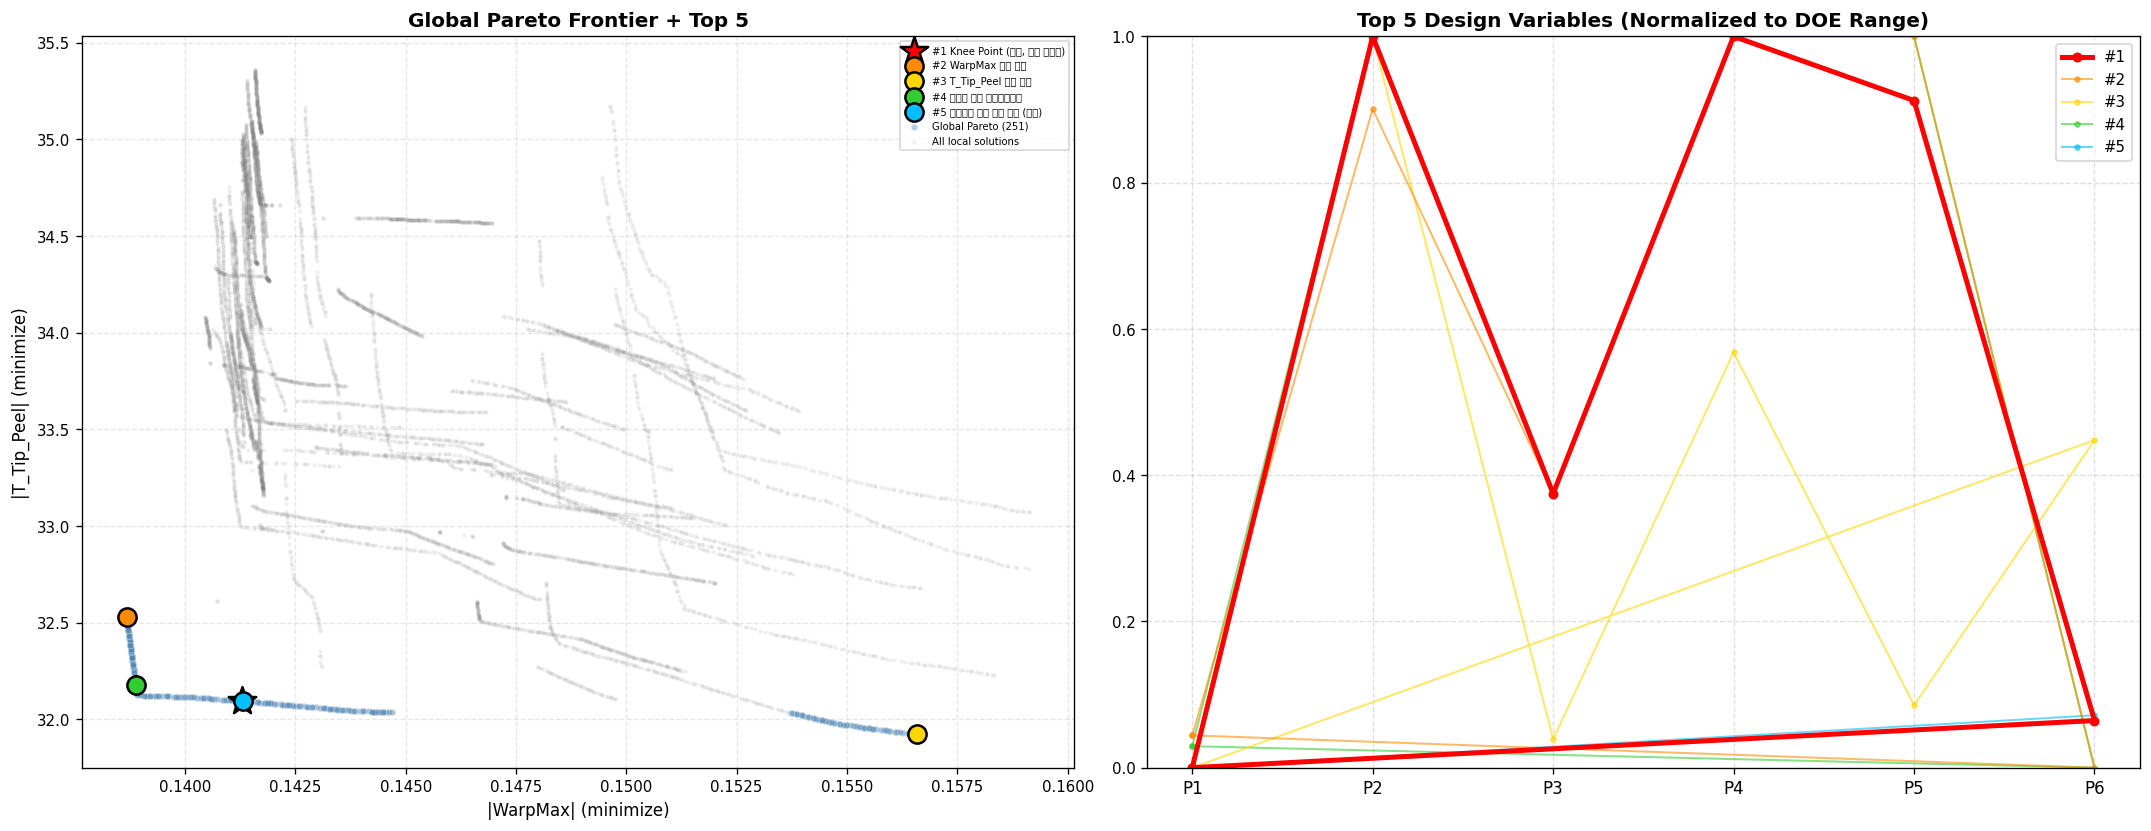

In [136]:
# ====================================================================
# [9. 파레토 프론티어 시각화]
# ====================================================================
print('\n[9] 파레토 프론티어 시각화')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- (A) 글로벌 파레토 + Top 5 표시 ---
ax = axes[0]

# 전체 로컬 해 (배경, 회색)
ax.scatter(all_F[:, 0], all_F[:, 1], s=3, alpha=0.08, c='gray', label='All local solutions')

# 글로벌 파레토 (중경, 파란색)
ax.scatter(pareto_F[:, 0], pareto_F[:, 1], s=15, alpha=0.4, c='steelblue',
           edgecolors='white', linewidths=0.3, label=f'Global Pareto ({len(global_pareto_idx)})')

# Top 5 (전경) — 역순으로 그려서 #1이 항상 최상위 레이어
colors_top5 = ['red', 'darkorange', 'gold', 'limegreen', 'deepskyblue']
markers_top5 = ['*', 'o', 'o', 'o', 'o']
sizes_top5 = [300, 120, 120, 120, 120]  # #1 별은 크게

for i in reversed(range(len(selected_indices))):
    sel_idx = selected_indices[i]
    label = selected_labels[i]
    ax.scatter(pareto_F[sel_idx, 0], pareto_F[sel_idx, 1],
               s=sizes_top5[i], c=colors_top5[i],
               edgecolors='black', linewidths=1.5,
               marker=markers_top5[i], zorder=10 + i,
               label=f'#{i+1} {label[:25]}')

ax.set_xlabel('|WarpMax| (minimize)', fontsize=10)
ax.set_ylabel('|T_Tip_Peel| (minimize)', fontsize=10)
ax.set_title('Global Pareto Frontier + Top 5', fontweight='bold', fontsize=12)

# 범례: 순서 정렬 (#1이 맨 위로)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], fontsize=6, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.3)

# --- (B) Top 5의 P1~P6 레이더 차트 (정규화) ---
ax = axes[1]

angles = np.linspace(0, 2 * np.pi, N_VAR, endpoint=False).tolist()
angles += angles[:1]

# 역순으로 그려서 #1이 최상위
for i in reversed(range(len(selected_indices))):
    sel_idx = selected_indices[i]
    p_vals = pareto_X[sel_idx]
    p_normalized = []
    for j, p in enumerate(P_LABELS):
        lo, hi = DOE_BOUNDS[p]
        p_normalized.append((p_vals[j] - lo) / (hi - lo))
    p_normalized += p_normalized[:1]

    color = colors_top5[i]
    linewidth = 3.0 if i == 0 else 1.2
    alpha = 1.0 if i == 0 else 0.6
    ax.plot(angles, p_normalized, color=color, linewidth=linewidth,
            alpha=alpha, label=f'#{i+1}', marker='o', markersize=5 if i == 0 else 3)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(P_LABELS, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Top 5 Design Variables (Normalized to DOE Range)', fontweight='bold', fontsize=12)

# 범례: 순서 정렬
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


[9] 파레토 프론티어 시각화 시작...


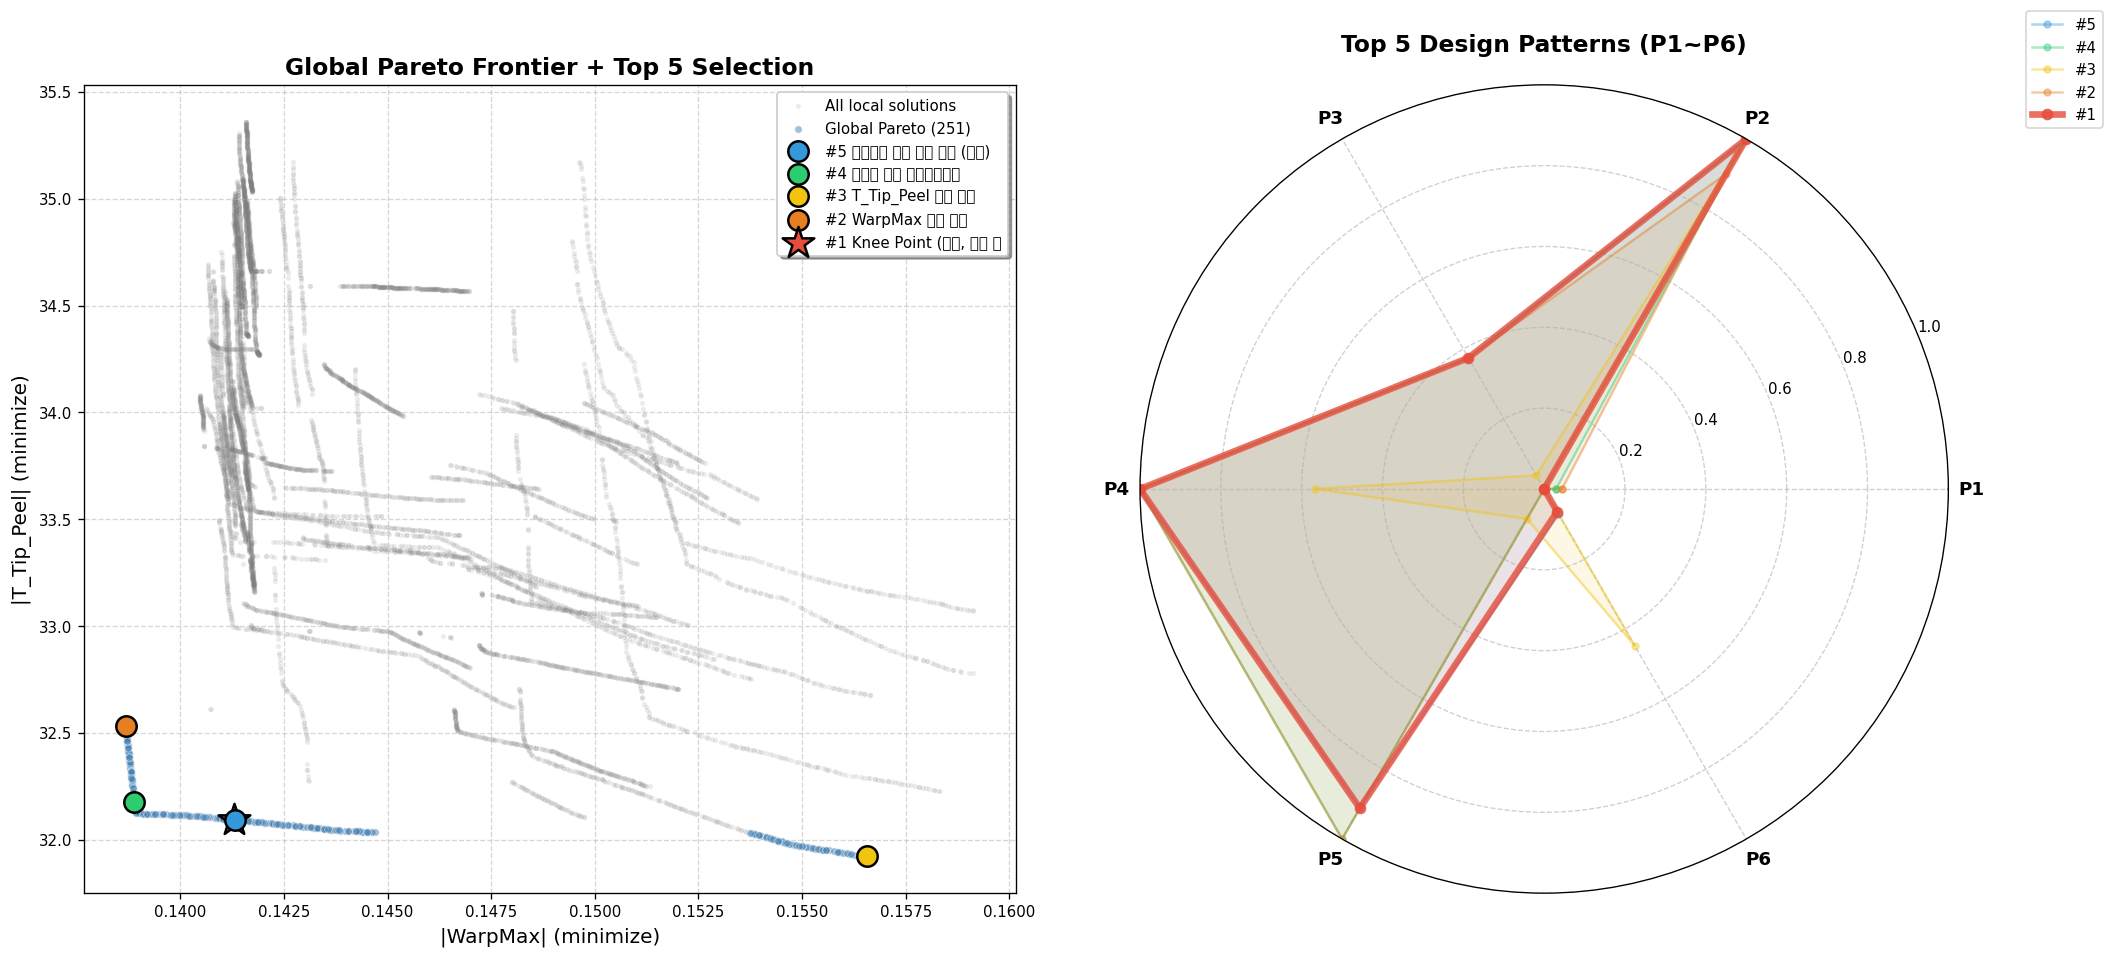

In [137]:
import matplotlib.pyplot as plt
import numpy as np

print('\n[9] 파레토 프론티어 시각화 시작...')

# 폰트 설정 (한글 깨짐 방지가 필요할 경우 추가 설정이 필요할 수 있습니다)
plt.rcParams['axes.unicode_minus'] = False 

fig = plt.figure(figsize=(18, 8))

# --- (A) 글로벌 파레토 + Top 5 표시 (일반 Cartesian Plot) ---
ax1 = fig.add_subplot(1, 2, 1)

# 1. 전체 로컬 해 (배경, 회색)
ax1.scatter(all_F[:, 0], all_F[:, 1], s=5, alpha=0.1, c='gray', label='All local solutions', zorder=1)

# 2. 글로벌 파레토 (중경, 파란색)
ax1.scatter(pareto_F[:, 0], pareto_F[:, 1], s=20, alpha=0.5, c='steelblue',
            edgecolors='white', linewidths=0.5, label=f'Global Pareto ({len(global_pareto_idx)})', zorder=2)

# 3. Top 5 (전경)
colors_top5 = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71', '#3498DB'] # 고대비 색상 적용
markers_top5 = ['*', 'o', 'o', 'o', 'o']
sizes_top5 = [400, 150, 150, 150, 150]

for i in reversed(range(len(selected_indices))):
    sel_idx = selected_indices[i]
    label = selected_labels[i]
    ax1.scatter(pareto_F[sel_idx, 0], pareto_F[sel_idx, 1],
                s=sizes_top5[i], c=colors_top5[i],
                edgecolors='black', linewidths=1.5,
                marker=markers_top5[i], zorder=10 + i,
                label=f'#{i+1} {label[:20]}')

ax1.set_xlabel('|WarpMax| (minimize)', fontsize=12)
ax1.set_ylabel('|T_Tip_Peel| (minimize)', fontsize=12)
ax1.set_title('Global Pareto Frontier + Top 5 Selection', fontweight='bold', fontsize=14)
ax1.legend(fontsize=9, loc='upper right', frameon=True, shadow=True)
ax1.grid(True, linestyle='--', alpha=0.5)

# --- (B) Top 5의 P1~P6 레이더 차트 (Polar Plot 적용) ---
ax2 = fig.add_subplot(1, 2, 2, projection='polar') # 극좌표계 설정 추가

angles = np.linspace(0, 2 * np.pi, N_VAR, endpoint=False).tolist()
angles += angles[:1] # 폐곡선을 위해 시작점 추가

for i in reversed(range(len(selected_indices))):
    sel_idx = selected_indices[i]
    p_vals = pareto_X[sel_idx]
    
    # 정규화 (0~1)
    p_normalized = []
    for j, p in enumerate(P_LABELS):
        lo, hi = DOE_BOUNDS[p]
        p_normalized.append((p_vals[j] - lo) / (hi - lo))
    p_normalized += p_normalized[:1]

    color = colors_top5[i]
    linewidth = 4.0 if i == 0 else 1.5
    alpha = 0.8 if i == 0 else 0.4
    
    ax2.plot(angles, p_normalized, color=color, linewidth=linewidth,
             alpha=alpha, label=f'#{i+1}', marker='o', markersize=6 if i == 0 else 4)
    ax2.fill(angles, p_normalized, color=color, alpha=0.1) # 내부 채우기 추가

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(P_LABELS, fontsize=11, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.set_title('Top 5 Design Patterns (P1~P6)', fontweight='bold', fontsize=14, pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [140]:
import os

print('\n[10] 최종 결과 저장 및 리포트 생성')

# 1. 파일 저장 경로 설정 (BASE_DIR이 정의되지 않았을 경우를 대비해 현재 경로 추가)
save_dir = locals().get('BASE_DIR', './')
output_path = os.path.join(save_dir, 'TB_Optimized_Results.csv')

# 2. CSV 저장
df_final.to_csv(output_path, index=False, encoding='utf-8-sig') # 한글 깨짐 방지

print(f'  ✅ 저장 완료: {output_path}')
print(f'  ✅ Top {len(df_final)}개 최적 설계안 리스트업 완료\n')

# 3. 결과 테이블 출력 (가독성 최적화)
header_line = '=' * 125
print(header_line)
print(f'{"Rank":>4s} | {"Label":>30s} | ', end='')
for p in P_LABELS:
    print(f'{p:>8s}', end=' ')
print(f' | {"WarpMax":>10s} {"T_Tip_Peel":>12s}')
print(header_line)

for _, row in df_final.iterrows():
    rank = int(row['Rank'])
    # Rank 1에 별표 표시
    marker = '★' if rank == 1 else ' '
    
    # 레이블이 너무 길 경우 자르기
    label_short = row["Label"][:30]
    
    print(f'{marker}{rank:>3d} | {label_short:>30s} | ', end='')
    
    # 설계 변수 출력
    for p in P_LABELS:
        print(f'{row[p]:8.4f}', end=' ')
    
    # 예측값 출력 (WarpMax_pred, T_Tip_Peel_pred 매칭 확인)
    print(f' | {row["WarpMax_pred"]:10.6f} {row["T_Tip_Peel_pred"]:12.6f}')

print(header_line)
print(f'\n💡 ★ Rank 1 ({df_final.iloc[0]["Label"]}): 모든 물리적 제약을 만족하며 휨과 박리 특성이 가장 균형 잡힌 최종 추천안입니다.')


[10] 최종 결과 저장 및 리포트 생성
  ✅ 저장 완료: C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS\TB_Optimized_Results.csv
  ✅ Top 5개 최적 설계안 리스트업 완료

Rank |                          Label |       P1       P2       P3       P4       P5       P6  |    WarpMax   T_Tip_Peel
★  1 |        Knee Point (추천, 최적 밸런스) |   0.8005   0.0899   0.6449   0.2994   1.7471   0.0427  |   0.141283    32.093376
   2 |                  WarpMax 최소 우선 |   0.8137   0.0859   0.6449   0.2994   1.7997   0.0401  |   0.138689    32.530457
   3 |               T_Tip_Peel 최소 우선 |   0.8005   0.0899   0.6048   0.2133   1.2514   0.0580  |   0.156578    31.921404
   4 |                  파레토 중간 트레이드오프 |   0.8093   0.0899   0.6449   0.2994   1.7997   0.0401  |   0.138889    32.175419
   5 |             제약조건 안전 마진 최고 (대체) |   0.8005   0.0899   0.6449   0.2994   1.7471   0.0430  |   0.141318    32.092789

💡 ★ Rank 1 (Knee Point (추천, 최적 밸런스)): 모든 물리적 제약을 만족하며 휨과 박리 특성이 가장 균형 잡힌 최종 추천안입니다.


In [141]:
# ====================================================================
# [11. 완료 요약] - Tabula ResNet 기반 최적화 결과
# ====================================================================
print('\n' + '=' * 80)
print('  [Step 5 완료] NSGA-II + Tabula ResNet 최적화 결과 요약')
print('=' * 80)
print(f'  Phase 1: {len(df_drafts)}개 초안 × {POP_SIZE}개체 × {N_GEN}세대 진화')
print(f'  Phase 2: {len(all_local_results):,}개 통합 → 글로벌 Frontier 0: {len(global_pareto_idx)}개')
print(f'  최종 선정: Top {len(selected_indices)}개 후보 도출')
print(f'  저장 파일: {output_path}')
print()

# --- 추천 설계안 (Rank 1) 상세 출력 ---
if not df_final.empty:
    print(f'  ★ 최종 추천 설계안 (Rank 1 — {df_final.iloc[0]["Label"]}):')
    best = df_final[df_final['Rank'] == 1].iloc[0]
    
    # 설계 변수 (P1~P6)
    print('    [설계 변수 P_Parameters]')
    for p in P_LABELS:
        print(f'      {p} = {best[p]:.4f}')
    
    # 주요 예측 성능
    print('\n    [예측 성능 지표]')
    print(f'      → |WarpMax|    : {best["WarpMax_pred"]:.6f}')
    print(f'      → |T_Tip_Peel| : {best["T_Tip_Peel_pred"]:.6f}')
    
    # 제약 조건 만족 여부 재확인 (옵션)
    print('\n    [Status]')
    print('      → 모든 Hard Constraints 및 Gatekeeper 조건 만족 확인됨.')
else:
    print('  [경고] 최종 결과 데이터프레임이 비어 있습니다.')

print('\n  🚀 다음 단계: 위 P1~P6를 [Step 6: Digital Twin 시뮬레이션]에 입력하여 검증 진행')
print('=' * 80)


  [Step 5 완료] NSGA-II + Tabula ResNet 최적화 결과 요약
  Phase 1: 41개 초안 × 200개체 × 100세대 진화
  Phase 2: 8,200개 통합 → 글로벌 Frontier 0: 251개
  최종 선정: Top 5개 후보 도출
  저장 파일: C:/Users/alstj/OneDrive/문서/GitHub/Flipchip_surrogate/JMS\TB_Optimized_Results.csv

  ★ 최종 추천 설계안 (Rank 1 — Knee Point (추천, 최적 밸런스)):
    [설계 변수 P_Parameters]
      P1 = 0.8005
      P2 = 0.0899
      P3 = 0.6449
      P4 = 0.2994
      P5 = 1.7471
      P6 = 0.0427

    [예측 성능 지표]
      → |WarpMax|    : 0.141283
      → |T_Tip_Peel| : 32.093376

    [Status]
      → 모든 Hard Constraints 및 Gatekeeper 조건 만족 확인됨.

  🚀 다음 단계: 위 P1~P6를 [Step 6: Digital Twin 시뮬레이션]에 입력하여 검증 진행
